In [ ]:
!pip install -q transformers scikit-learn scipy networkx matplotlib datasets


Install step done. Restart the kernel if this upgraded a loaded package.


In [ ]:
import gc
import math
import os
import platform
import random
import time
from collections import defaultdict
from contextlib import contextmanager

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy import sparse as scipy_sparse
from scipy.sparse.linalg import eigsh
from sklearn.cluster import KMeans
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from transformers import AutoModelForCausalLM, AutoTokenizer


SEED = 0


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
STAGE_TIMES = {}


@contextmanager
def evaluation_mode(model):
    was_training = model.training
    model.eval()
    try:
        yield
    finally:
        if was_training:
            model.train()


def runtime_metadata(model=None):
    gpu = None
    if DEVICE.type == "cuda":
        props = torch.cuda.get_device_properties(DEVICE)
        gpu = {
            "name": props.name,
            "count": torch.cuda.device_count(),
            "memory_gb": round(props.total_memory / 1e9, 2),
        }
    return {
        "seed": SEED,
        "python": platform.python_version(),
        "platform": platform.platform(),
        "torch": torch.__version__,
        "device": str(DEVICE),
        "gpu": gpu,
        "cpu_count": os.cpu_count(),
        "model_revision": getattr(getattr(model, "config", None), "_commit_hash", None),
        "model_dtype": str(next(model.parameters()).dtype) if model is not None else None,
    }


print("Device:", DEVICE)
if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print("GPU:", props.name, "| VRAM: %.1f GB" % (props.total_memory / 1e9))
else:
    print("No CUDA-enabled torch device is visible. Use a GPU runtime for the full experiment.")


PIPELINE_VALIDATED = False
CIRCUIT_VALIDATED = False
CIRCUIT_VALIDATED_POSITION_SCOPED = False


def require_stage(stage_name, need_circuit=False):
    if not PIPELINE_VALIDATED:
        raise RuntimeError(
            f"Refusing to run '{stage_name}': PIPELINE_VALIDATED is False. "
            "Re-run from the fine-tuning cell and let the held-out accuracy "
            "gate pass in this kernel session before continuing."
        )
    if need_circuit and not CIRCUIT_VALIDATED:
        raise RuntimeError(
            f"Refusing to run '{stage_name}': CIRCUIT_VALIDATED is False. "
            "The primary circuit has not cleared min_circuit_nodes_for_downstream "
            "and min_phi_for_downstream yet. Do not run task-comparison, ablation, "
            "or transfer sections on top of a degenerate circuit."
        )


def downstream_unlock_reason():
    if CIRCUIT_VALIDATED:
        return "primary (position-uniform phi)"
    if CONFIG.get("allow_position_scoped_downstream", False) and CIRCUIT_VALIDATED_POSITION_SCOPED:
        return "position-scoped (generation-only phi)"
    return None


Device: cuda
GPU: Tesla T4 | VRAM: 15.6 GB


In [ ]:
CONFIG = {
    "model_name": "gpt2",
    "second_model_name": "EleutherAI/pythia-70m",
    "task": "modular_arithmetic",
    "task_mod": 23,
    "layers_to_analyze": [3, 4, 5, 6],
    "dict_expansion": 8,
    "topk_active": 32,
    "crosslayer_rank": 256,
    "edge_topk_per_node": 16,
    "hierarchy_branching_factor": 4,
    "max_hierarchy_nodes": 2000,
    "exact_eigh_max_nodes": 512,
    "traversal_topk_per_level": 2,
    "traversal_max_candidates": 48,
    "connected_neighbor_expansion": 4,
    "lambda1_crosslayer": 1.0,
    "lambda2_sparsity": 1e-3,
    "necessity_epsilon": 0.01,
    "necessity_epsilon_mode": "relative",
    "necessity_epsilon_relative_fraction": 0.015,
    "necessity_quantile": 0.65,
    "sufficiency_threshold": 0.9,
    "min_task_accuracy": 0.80,
    "max_reconstruction_variance": 0.40,
    "min_circuit_nodes_for_downstream": 10,
    "min_phi_for_downstream": 0.3,
    "finetune_max_epochs": 80,
    "finetune_lr_schedule_epochs": 80,
    "finetune_min_epochs": 10,
    "finetune_eval_every": 2,
    "finetune_eval_examples": 200,
    "finetune_plateau_rel_improvement": 0.01,
    "finetune_plateau_patience": 6,
    "finetune_examples": 3000,
    "finetune_batch_size": 16,
    "finetune_lr": 2e-4,
    "finetune_grad_clip_norm": 1.0,
    "finetune_accuracy_patience": 5,
    "transcoder_cache_examples": 1000,
    "reconstruction_eval_examples": 200,
    "reconstruction_broad_check_examples": 40,
    "transcoder_batch_size": 256,
    "transcoder_max_epochs": 80,
    "transcoder_min_epochs": 20,
    "transcoder_plateau_rel_improvement": 2e-3,
    "transcoder_plateau_patience": 5,
    "attribution_examples": 12,
    "attribution_method": "grad_x_act",
    "ig_steps": 20,
    "ig_check_examples": 2,
    "ig_check_feature_cap": 8,
    "run_ig_sanity_check": True,
    "gt_candidate_pool": 160,
    "gt_top_fraction": 0.50,
    "necessity_eval_examples": 200,
    "gnn_label_holdout": 0.25,
    "gnn_epochs": 300,
    "gnn_num_layers": 2,
    "refined_edge_keep_fraction": 0.15,
    "ablation_eval_examples": 120,
    "run_scaling_sanity_check": True,
    "run_all_task_comparison": False,
    "run_ablation_study": False,
    "run_transfer_demo": True,
    "run_seed_sweep": True,
    "run_cross_task_gnn_check": True,
    # GNN overfitting fix: weight decay + held-out-AUROC early stopping.
    "gnn_weight_decay": 0.05,
    "gnn_eval_every": 10,
    "gnn_min_epochs": 50,
    "gnn_patience": 5,
    "run_node_count_sweep": True,
    "node_count_sweep_sizes": [5, 10, 20, 32, 40, 60, 80],
    "run_topk_sweep": True,
    "topk_sweep_values": [32, 64, 128, 256],
    "run_branching_factor_sweep": True,
    "branching_factor_sweep_values": [4, 8, 16],
    "run_diagnostic_null_reconstruction": True,
    "run_diagnostic_single_layer_sweep": True,
    "run_diagnostic_feature_activation_rates": True,
    "diagnostic_activation_rate_broad_examples": 200,
    "run_diagnostic_position_scoped_sufficiency": True,
    "allow_position_scoped_downstream": False,
    "ablation_use_position_scoped": False,
    "run_diagnostic_randomized_feature_control": True,
    "run_diagnostic_position_scoped_greedy": True,
    "run_diagnostic_connectivity_filter_check": True,
    "run_diagnostic_traversal_overlap_check": True,
    "run_diagnostic_synergy_check": True,
    "run_diagnostic_recall_augmented_circuit": True,  
    "run_diagnostic_inverse_necessity_check": True,
    "run_diagnostic_layer_scoped_restriction": True,
    "run_diagnostic_alpha_blend_sweep": True,
    "run_diagnostic_prompt_distribution_stability": True,
    "run_diagnostic_multiseed_exploratory": False,  
    "run_diagnostic_infrastructure_summary": True,
    "run_diagnostic_greedy_tolerance_check": True,
    "run_diagnostic_first_step_only_restriction": True,
    "run_diagnostic_position_depth_sweep": True,
    "run_diagnostic_position_depth_size_grid": True,
    "run_diagnostic_second_task_pipeline": False,  
    "second_task_for_experiment_d": "parity",
    "seed_values": [0, 1, 2],
    "run_winogrande_scaffold": True,
}

hidden_dim_lookup = {
    "gpt2": 768,
    "distilgpt2": 768,
    "EleutherAI/pythia-70m": 512,
    "EleutherAI/pythia-160m": 768,
}
CONFIG["hidden_dim"] = hidden_dim_lookup.get(CONFIG["model_name"], 768)
CONFIG["dict_size"] = CONFIG["hidden_dim"] * CONFIG["dict_expansion"]
print(CONFIG)


{'model_name': 'gpt2', 'second_model_name': 'EleutherAI/pythia-70m', 'task': 'modular_arithmetic', 'task_mod': 23, 'layers_to_analyze': [3, 4, 5, 6], 'dict_expansion': 8, 'topk_active': 32, 'crosslayer_rank': 256, 'edge_topk_per_node': 16, 'hierarchy_branching_factor': 4, 'max_hierarchy_nodes': 2000, 'exact_eigh_max_nodes': 512, 'traversal_topk_per_level': 2, 'traversal_max_candidates': 48, 'connected_neighbor_expansion': 4, 'lambda1_crosslayer': 1.0, 'lambda2_sparsity': 0.001, 'necessity_epsilon': 0.01, 'necessity_epsilon_mode': 'relative', 'necessity_epsilon_relative_fraction': 0.015, 'necessity_quantile': 0.65, 'sufficiency_threshold': 0.9, 'min_task_accuracy': 0.8, 'max_reconstruction_variance': 0.4, 'min_circuit_nodes_for_downstream': 10, 'min_phi_for_downstream': 0.3, 'finetune_max_epochs': 80, 'finetune_lr_schedule_epochs': 80, 'finetune_min_epochs': 10, 'finetune_eval_every': 2, 'finetune_eval_examples': 200, 'finetune_plateau_rel_improvement': 0.01, 'finetune_plateau_patience'

In [4]:
def get_transformer_blocks(model):
    if hasattr(model, "transformer") and hasattr(model.transformer, "h"):
        return model.transformer.h
    if hasattr(model, "gpt_neox") and hasattr(model.gpt_neox, "layers"):
        return model.gpt_neox.layers
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return model.model.layers
    raise ValueError(
        "Unrecognized architecture for %s. Add a case to get_transformer_blocks()."
        % type(model).__name__
    )

In [ ]:
def spaced(n):
    return " ".join(str(n))


def _cycle_to_count(pool, count, to_example_fn):
    out = []
    items = list(pool)
    while len(out) < count:
        random.shuffle(items)
        for item in items:
            if len(out) >= count:
                break
            out.append(to_example_fn(item))
    return out


def _held_out_split(all_items, n_train, n_eval, to_example_fn, eval_fraction=0.2):
    items = list(all_items)
    random.shuffle(items)
    if len(items) < 2:
        raise ValueError("Need at least two distinct task instances for a held-out split.")
    n_hold = min(n_eval, max(1, int(len(items) * eval_fraction)))
    n_hold = min(n_hold, len(items) - 1)
    eval_pool = items[:n_hold]
    train_pool = items[n_hold:]
    return _cycle_to_count(train_pool, n_train, to_example_fn), [to_example_fn(x) for x in eval_pool]


def make_modular_arithmetic_examples(n_train, n_eval, mod):
    all_pairs = [(a, b) for a in range(mod) for b in range(mod)]

    def to_example(pair):
        a, b = pair
        c = (a + b) % mod
        return (f"{spaced(a)} + {spaced(b)} mod {mod} = ", spaced(c))

    return _held_out_split(all_pairs, n_train, n_eval, to_example)


def make_parity_examples(n_train, n_eval, min_len=4, max_len=10):
    all_bitstrings = []
    for length in range(min_len, max_len + 1):
        for value in range(2 ** length):
            bits = tuple((value >> i) & 1 for i in range(length))
            all_bitstrings.append(bits)

    def to_example(bits):
        parity = sum(bits) % 2
        return (" ".join(str(b) for b in bits) + " parity = ", str(parity))

    return _held_out_split(all_bitstrings, n_train, n_eval, to_example)


def make_sorting_examples(n_train, n_eval, k=5, max_val=30):
    from itertools import combinations

    all_combos = list(combinations(range(max_val), k))

    def to_example(nums):
        values = list(nums)
        local_seed = sum((i + 1) * value for i, value in enumerate(values)) + 7919
        local_rng = random.Random(local_seed)
        local_rng.shuffle(values)
        if values == sorted(values):
            values = values[1:] + values[:1]
        prompt = " ".join(str(x) for x in values) + " sorted = "
        answer = " ".join(str(x) for x in sorted(values))
        return (prompt, answer)

    return _held_out_split(all_combos, n_train, n_eval, to_example)


TASK_GENERATORS = {
    "modular_arithmetic": lambda n_tr, n_ev: make_modular_arithmetic_examples(n_tr, n_ev, CONFIG["task_mod"]),
    "parity": lambda n_tr, n_ev: make_parity_examples(n_tr, n_ev),
    "sorting": lambda n_tr, n_ev: make_sorting_examples(n_tr, n_ev),
}
TASK_MAX_NEW_TOKENS = {"modular_arithmetic": 8, "parity": 4, "sorting": 24}


def normalize_answer(text):
    return " ".join(text.strip().split())


def answer_matches(predicted_text, answer_str):
    return normalize_answer(predicted_text) == normalize_answer(answer_str)


train_examples, eval_examples = TASK_GENERATORS[CONFIG["task"]](CONFIG["finetune_examples"], 300)
print("Task:", CONFIG["task"])
print("Train examples:", len(train_examples), "| Unique held-out eval examples:", len(eval_examples))
print("Sample prompt:", repr(train_examples[0][0]))
print("Sample answer:", repr(train_examples[0][1]))
train_prompts = {p for p, _ in train_examples}
eval_prompts = {p for p, _ in eval_examples}
print("Prompt overlap between train and eval:", len(train_prompts & eval_prompts), "(must be 0)")
for _warn_key in ("necessity_eval_examples", "diagnostic_activation_rate_broad_examples"):
    if CONFIG[_warn_key] > len(eval_examples):
        print(
            f"WARNING: CONFIG['{_warn_key}']={CONFIG[_warn_key]} exceeds the "
            f"{len(eval_examples)} unique held-out examples available. Effective sample "
            f"size is {len(eval_examples)}, not {CONFIG[_warn_key]}. See revision history v19."
        )


Task: modular_arithmetic
Train examples: 3000 | Unique held-out eval examples: 105
Sample prompt: '0 + 2 mod 23 = '
Sample answer: '2'
Prompt overlap between train and eval: 0 (must be 0)


In [6]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
if tokenizer.eos_token_id is None:
    raise ValueError("The selected tokenizer needs an EOS token for exact-stop evaluation.")

model = AutoModelForCausalLM.from_pretrained(CONFIG["model_name"], dtype=torch.float32).to(DEVICE)
model.train()
CONFIG["hidden_dim"] = getattr(model.config, "hidden_size", getattr(model.config, "n_embd", CONFIG["hidden_dim"]))
CONFIG["dict_size"] = CONFIG["hidden_dim"] * CONFIG["dict_expansion"]

print("Loaded", CONFIG["model_name"], "with", sum(p.numel() for p in model.parameters()),
      "parameters, dtype", next(model.parameters()).dtype)
print("Run metadata:", runtime_metadata(model))
print("Resolved hidden_dim/dict_size:", CONFIG["hidden_dim"], CONFIG["dict_size"])


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded gpt2 with 124439808 parameters, dtype torch.float32
Run metadata: {'seed': 0, 'python': '3.12.13', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.35', 'torch': '2.11.0+cu128', 'device': 'cuda', 'gpu': {'name': 'Tesla T4', 'count': 1, 'memory_gb': 15.64}, 'cpu_count': 2, 'model_revision': '607a30d783dfa663caf39e06633721c8d4cfcd7e', 'model_dtype': 'torch.float32'}
Resolved hidden_dim/dict_size: 768 6144


In [ ]:
def encode_example(prompt, answer, tok):
    prompt_ids = tok.encode(prompt, add_special_tokens=False)
    answer_ids = tok.encode(answer, add_special_tokens=False)
    eos_id = tok.eos_token_id
    full_ids = prompt_ids + answer_ids + [eos_id]
    labels = [-100] * len(prompt_ids) + answer_ids + [eos_id]
    return full_ids, labels


def build_batch(examples, tok, device):
    all_ids, all_labels = [], []
    for prompt, answer in examples:
        ids, labels = encode_example(prompt, answer, tok)
        all_ids.append(ids)
        all_labels.append(labels)
    maxlen = max(len(ids) for ids in all_ids)
    pad_id = tok.pad_token_id
    input_ids, attention_mask, labels_batch = [], [], []
    for ids, labels in zip(all_ids, all_labels):
        pad_len = maxlen - len(ids)
        input_ids.append(ids + [pad_id] * pad_len)
        attention_mask.append([1] * len(ids) + [0] * pad_len)
        labels_batch.append(labels + [-100] * pad_len)
    return (
        torch.tensor(input_ids, device=device),
        torch.tensor(attention_mask, device=device),
        torch.tensor(labels_batch, device=device),
    )


def batch_iterator(examples, batch_size, tok, device, shuffle=True):
    indices = list(range(len(examples)))
    if shuffle:
        random.shuffle(indices)
    for start in range(0, len(indices), batch_size):
        yield build_batch([examples[i] for i in indices[start:start + batch_size]], tok, device)


@torch.no_grad()
def generate_answer(model, tok, prompt, max_new_tokens=None):
    if max_new_tokens is None:
        max_new_tokens = TASK_MAX_NEW_TOKENS.get(CONFIG["task"], 8)
    device = next(model.parameters()).device
    encoded = tok(prompt, return_tensors="pt")
    encoded = {key: value.to(device) for key, value in encoded.items()}
    generated = model.generate(
        **encoded,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        eos_token_id=tok.eos_token_id,
        pad_token_id=tok.pad_token_id,
    )
    prompt_length = encoded["input_ids"].shape[1]
    new_ids = generated[0, prompt_length:].tolist()
    if tok.eos_token_id in new_ids:
        new_ids = new_ids[:new_ids.index(tok.eos_token_id)]
    return tok.decode(new_ids, skip_special_tokens=False)


@torch.no_grad()
def evaluate_task_accuracy(model, tok, examples, max_examples=None):
    selected = examples if max_examples is None else examples[:max_examples]
    if not selected:
        return float("nan")
    correct = 0
    with evaluation_mode(model):
        for prompt, answer in selected:
            correct += int(answer_matches(generate_answer(model, tok, prompt), answer))
    return correct / len(selected)


def fine_tune_until_converged(model, tok, train_set, validation_set):
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["finetune_lr"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG["finetune_lr_schedule_epochs"]
    )
    history = []
    previous_loss = None
    plateau_steps = 0
    stop_reason = "maximum epochs reached"
    started = time.time()
    best_accuracy = -1.0
    best_epoch = None
    best_state = None
    evals_since_best = 0

    for epoch in range(1, CONFIG["finetune_max_epochs"] + 1):
        model.train()
        total_loss, batches = 0.0, 0
        for input_ids, attention_mask, labels in batch_iterator(
            train_set, CONFIG["finetune_batch_size"], tok, DEVICE
        ):
            out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            optimizer.zero_grad(set_to_none=True)
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["finetune_grad_clip_norm"])
            optimizer.step()
            total_loss += out.loss.item()
            batches += 1
        scheduler.step()

        average_loss = total_loss / max(batches, 1)
        relative_improvement = None
        if previous_loss is not None:
            relative_improvement = (previous_loss - average_loss) / max(abs(previous_loss), 1e-8)
        previous_loss = average_loss

        validation_accuracy = None
        if epoch % CONFIG["finetune_eval_every"] == 0 or epoch == 1:
            validation_accuracy = evaluate_task_accuracy(
                model, tok, validation_set, CONFIG["finetune_eval_examples"]
            )
            current_lr = scheduler.get_last_lr()[0]
            print(
                f"epoch {epoch}/{CONFIG['finetune_max_epochs']}  "
                f"answer-only loss {average_loss:.4f}  held-out exact match {validation_accuracy:.3f}  "
                f"lr {current_lr:.2e}"
            )
            if validation_accuracy > best_accuracy:
                best_accuracy = validation_accuracy
                best_epoch = epoch
                evals_since_best = 0
                best_state = {
                    key: value.detach().clone().cpu() for key, value in model.state_dict().items()
                }
            else:
                evals_since_best += 1
            if validation_accuracy >= CONFIG["min_task_accuracy"]:
                stop_reason = f"accuracy target {CONFIG['min_task_accuracy']:.2f} reached"
                history.append((epoch, average_loss, validation_accuracy))
                break
            if (
                epoch >= CONFIG["finetune_min_epochs"]
                and evals_since_best >= CONFIG["finetune_accuracy_patience"]
            ):
                stop_reason = (
                    f"held-out accuracy has not improved on best epoch {best_epoch} "
                    f"({best_accuracy:.3f}) for {evals_since_best} evaluations -- "
                    "stopping rather than continuing to overfit the training set"
                )
                history.append((epoch, average_loss, validation_accuracy))
                break
        else:
            print(f"epoch {epoch}/{CONFIG['finetune_max_epochs']}  answer-only loss {average_loss:.4f}")

        history.append((epoch, average_loss, validation_accuracy))
        if epoch >= CONFIG["finetune_min_epochs"] and relative_improvement is not None:
            plateau_steps = plateau_steps + 1 if relative_improvement < CONFIG["finetune_plateau_rel_improvement"] else 0
            if plateau_steps >= CONFIG["finetune_plateau_patience"]:
                stop_reason = "training-loss plateau"
                break
    restored_note = "no evaluation ever ran"
    if best_state is not None:
        model.load_state_dict(best_state)
        restored_note = f"restored epoch {best_epoch} (held-out accuracy {best_accuracy:.3f})"
    print(f"Fine-tuning finished; {restored_note}.")

    del optimizer, scheduler
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return history, time.time() - started, stop_reason, best_accuracy


finetune_history, finetune_time, finetune_stop_reason, finetune_best_accuracy = fine_tune_until_converged(
    model, tokenizer, train_examples, eval_examples
)
STAGE_TIMES["fine_tune_s"] = finetune_time
print(f"Fine-tuning stopped because: {finetune_stop_reason} ({finetune_time:.1f}s)")


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


epoch 1/80  answer-only loss 1.3496  held-out exact match 0.029  lr 2.00e-04
epoch 2/80  answer-only loss 0.9539  held-out exact match 0.190  lr 2.00e-04
epoch 3/80  answer-only loss 0.5932
epoch 4/80  answer-only loss 0.3915  held-out exact match 0.352  lr 1.99e-04
epoch 5/80  answer-only loss 0.2894
epoch 6/80  answer-only loss 0.2261  held-out exact match 0.410  lr 1.97e-04
epoch 7/80  answer-only loss 0.1573
epoch 8/80  answer-only loss 0.1136  held-out exact match 0.505  lr 1.95e-04
epoch 9/80  answer-only loss 0.0990
epoch 10/80  answer-only loss 0.0798  held-out exact match 0.543  lr 1.92e-04
epoch 11/80  answer-only loss 0.0612
epoch 12/80  answer-only loss 0.0417  held-out exact match 0.552  lr 1.89e-04
epoch 13/80  answer-only loss 0.0348
epoch 14/80  answer-only loss 0.0194  held-out exact match 0.648  lr 1.85e-04
epoch 15/80  answer-only loss 0.0020
epoch 16/80  answer-only loss 0.0122  held-out exact match 0.667  lr 1.81e-04
epoch 17/80  answer-only loss 0.0161
epoch 18/80

In [8]:
print("Sample EOS-truncated predictions after fine-tuning:")
for prompt, answer in eval_examples[:8]:
    raw = generate_answer(model, tokenizer, prompt)
    mark = "OK" if answer_matches(raw, answer) else "no"
    print(f"  {prompt!r} -> true {answer!r}, model said {raw!r}  [{mark}]")

task_acc = evaluate_task_accuracy(model, tokenizer, eval_examples)
print(
    f"\nHeld-out exact-match task accuracy: {task_acc:.3f} "
    f"(best-checkpoint accuracy seen during training: {finetune_best_accuracy:.3f})"
)
if task_acc < CONFIG["min_task_accuracy"]:
    raise RuntimeError(
        f"Accuracy gate failed ({task_acc:.3f} < {CONFIG['min_task_accuracy']:.3f}). "
        "Do not interpret circuit, preservation, ablation, or transfer values; "
        "increase the task-training budget or change scope explicitly."
    )
print("Accuracy gate passed; circuit extraction may proceed.")
PIPELINE_VALIDATED = True


Sample EOS-truncated predictions after fine-tuning:
  '1 9 + 9 mod 23 = ' -> true '5', model said '5'  [OK]
  '2 + 1 2 mod 23 = ' -> true '1 4', model said '1 4'  [OK]
  '8 + 7 mod 23 = ' -> true '1 5', model said '1 4'  [no]
  '2 1 + 8 mod 23 = ' -> true '6', model said '6'  [OK]
  '0 + 1 7 mod 23 = ' -> true '1 7', model said '1 7'  [OK]
  '4 + 1 6 mod 23 = ' -> true '2 0', model said '1 8'  [no]
  '2 2 + 0 mod 23 = ' -> true '2 2', model said '2 2'  [OK]
  '1 6 + 1 1 mod 23 = ' -> true '4', model said '4'  [OK]

Held-out exact-match task accuracy: 0.838 (best-checkpoint accuracy seen during training: 0.838)
Accuracy gate passed; circuit extraction may proceed.


In [9]:
class Transcoder(nn.Module):
    def __init__(self, hidden_dim, dict_size, k):
        super().__init__()
        self.enc = nn.Linear(hidden_dim, dict_size, bias=True)
        self.dec = nn.Linear(dict_size, hidden_dim, bias=True)
        nn.init.normal_(self.enc.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.enc.bias)
        with torch.no_grad():
            self.dec.weight.copy_(self.enc.weight.T)
            self.dec.bias.zero_()
        self.k = k

    @torch.no_grad()
    def initialize_decoder_bias(self, activations):
        self.dec.bias.copy_(activations.float().mean(dim=0).to(self.dec.bias.device))

    @torch.no_grad()
    def normalize_decoder_columns(self):
        norms = self.dec.weight.norm(dim=0, keepdim=True).clamp_min(1e-8)
        self.dec.weight.div_(norms)

    def encode(self, hidden):
        pre = F.relu(self.enc(hidden))
        k = min(self.k, pre.shape[-1])
        topk_values, topk_indices = torch.topk(pre, k, dim=-1)
        features = torch.zeros_like(pre)
        features.scatter_(-1, topk_indices, topk_values)
        return features

    def decode(self, features):
        return self.dec(features)

    def forward(self, hidden):
        features = self.encode(hidden)
        return features, self.decode(features)


In [10]:
class CrossLayerHead(nn.Module):
    def __init__(self, dict_size, rank):
        super().__init__()
        self.in_proj = nn.Linear(dict_size, rank, bias=True)
        self.out_proj = nn.Linear(rank, dict_size, bias=True)

    def forward(self, features):
        return F.relu(self.out_proj(F.relu(self.in_proj(features))))


def make_transcoders(hidden_dim, dict_size, k, layers):
    transcoders = {layer: Transcoder(hidden_dim, dict_size, k).to(DEVICE) for layer in layers}
    heads = {
        layer: CrossLayerHead(dict_size, CONFIG["crosslayer_rank"]).to(DEVICE)
        for layer in layers[:-1]
    }
    return transcoders, heads


require_stage("cross-layer transcoder training")
layers = CONFIG["layers_to_analyze"]
transcoders, cross_heads = make_transcoders(
    CONFIG["hidden_dim"], CONFIG["dict_size"], CONFIG["topk_active"], layers
)
print("Transcoders for layers:", layers)


Transcoders for layers: [3, 4, 5, 6]


In [11]:
@torch.no_grad()
def collect_activations(model, tok, examples, layers, max_examples):
    captured = {layer: [] for layer in layers}
    blocks = get_transformer_blocks(model)
    handles = []

    def make_hook(layer):
        def hook(module, inputs, output):
            hidden = output[0] if isinstance(output, tuple) else output
            captured[layer].append(hidden.detach().float().reshape(-1, hidden.shape[-1]).cpu())
        return hook

    for layer in layers:
        handles.append(blocks[layer].register_forward_hook(make_hook(layer)))
    try:
        with evaluation_mode(model):
            for prompt, answer in examples[:max_examples]:
                ids, _ = encode_example(prompt, answer, tok)
                model(input_ids=torch.tensor([ids], device=DEVICE))
    finally:
        for handle in handles:
            handle.remove()
    return {layer: torch.cat(values, dim=0) for layer, values in captured.items()}


@torch.no_grad()
def collect_last_token_activations(model, tok, examples, layers, max_examples):
    captured = {layer: [] for layer in layers}
    blocks = get_transformer_blocks(model)
    handles = []

    def make_hook(layer):
        def hook(module, inputs, output):
            hidden = output[0] if isinstance(output, tuple) else output
            captured[layer].append(hidden[:, -1, :].detach().float().cpu())
        return hook

    for layer in layers:
        handles.append(blocks[layer].register_forward_hook(make_hook(layer)))
    try:
        with evaluation_mode(model):
            for prompt, answer in examples[:max_examples]:
                ids, _ = encode_example(prompt, answer, tok)
                model(input_ids=torch.tensor([ids], device=DEVICE))
    finally:
        for handle in handles:
            handle.remove()
    return {layer: torch.cat(values, dim=0) for layer, values in captured.items()}


cache_start = time.time()
cached_acts = collect_activations(
    model, tokenizer, train_examples, layers, CONFIG["transcoder_cache_examples"]
)
reconstruction_eval_acts = collect_activations(
    model, tokenizer, eval_examples, layers, CONFIG["reconstruction_eval_examples"]
)
STAGE_TIMES["activation_cache_s"] = time.time() - cache_start
for layer, values in cached_acts.items():
    print(f"layer {layer}: train cache {tuple(values.shape)}, held-out cache {tuple(reconstruction_eval_acts[layer].shape)}")


layer 3: train cache (10656, 768), held-out cache (1139, 768)
layer 4: train cache (10656, 768), held-out cache (1139, 768)
layer 5: train cache (10656, 768), held-out cache (1139, 768)
layer 6: train cache (10656, 768), held-out cache (1139, 768)


In [12]:
@torch.no_grad()
def initialize_transcoder_biases(transcoders, cached_acts, layers):
    for layer in layers:
        transcoders[layer].initialize_decoder_bias(cached_acts[layer])
        transcoders[layer].normalize_decoder_columns()


def train_transcoders(transcoders, cross_heads, cached_acts, layers, lambda1, lambda2,
                      use_cross_layer=True):
    parameters = []
    for layer in layers:
        parameters.extend(transcoders[layer].parameters())
    if use_cross_layer:
        for layer in layers[:-1]:
            parameters.extend(cross_heads[layer].parameters())
    optimizer = torch.optim.AdamW(parameters, lr=1e-3)

    history = {"recon": [], "crosslayer": [], "sparsity": []}
    n_rows = cached_acts[layers[0]].shape[0]
    previous_recon = None
    plateau_steps = 0

    for epoch in range(1, CONFIG["transcoder_max_epochs"] + 1):
        permutation = torch.randperm(n_rows)
        recon_sum = cross_sum = sparse_sum = 0.0
        recon_count = cross_count = 0

        for start in range(0, n_rows, CONFIG["transcoder_batch_size"]):
            batch_indices = permutation[start:start + CONFIG["transcoder_batch_size"]]
            for layer in layers:
                hidden = cached_acts[layer][batch_indices].to(DEVICE)
                features, reconstruction = transcoders[layer](hidden)
                reconstruction_loss = F.mse_loss(reconstruction, hidden)
                sparsity_loss = features.abs().mean()
                loss = reconstruction_loss + lambda2 * sparsity_loss
                recon_sum += reconstruction_loss.item()
                sparse_sum += sparsity_loss.item()
                recon_count += 1

                if use_cross_layer and layer != layers[-1]:
                    next_hidden = cached_acts[layer + 1][batch_indices].to(DEVICE)
                    with torch.no_grad():
                        next_features, _ = transcoders[layer + 1](next_hidden)
                    prediction_loss = F.mse_loss(cross_heads[layer](features), next_features)
                    loss = loss + lambda1 * prediction_loss
                    cross_sum += prediction_loss.item()
                    cross_count += 1

                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
                transcoders[layer].normalize_decoder_columns()

        recon_value = recon_sum / max(recon_count, 1)
        cross_value = cross_sum / max(cross_count, 1)
        sparse_value = sparse_sum / max(recon_count, 1)
        history["recon"].append(recon_value)
        history["crosslayer"].append(cross_value)
        history["sparsity"].append(sparse_value)

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"transcoder epoch {epoch}/{CONFIG['transcoder_max_epochs']}  "
                f"recon {recon_value:.5f}  crosslayer {cross_value:.5f}  sparsity {sparse_value:.5f}"
            )

        if epoch >= CONFIG["transcoder_min_epochs"] and previous_recon is not None:
            relative_improvement = (previous_recon - recon_value) / max(abs(previous_recon), 1e-8)
            plateau_steps = plateau_steps + 1 if relative_improvement < CONFIG["transcoder_plateau_rel_improvement"] else 0
            if plateau_steps >= CONFIG["transcoder_plateau_patience"]:
                print(f"Transcoder training stopped at epoch {epoch}: reconstruction-loss plateau.")
                break
        previous_recon = recon_value

    del optimizer
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return history


initialize_transcoder_biases(transcoders, cached_acts, layers)
transcoder_start = time.time()
training_history = train_transcoders(
    transcoders, cross_heads, cached_acts, layers,
    CONFIG["lambda1_crosslayer"], CONFIG["lambda2_sparsity"], use_cross_layer=True
)
STAGE_TIMES["transcoder_train_s"] = time.time() - transcoder_start


transcoder epoch 1/80  recon 925.37469  crosslayer 33.56404  sparsity 0.52637
transcoder epoch 5/80  recon 26.46613  crosslayer 59.45929  sparsity 0.83232
transcoder epoch 10/80  recon 13.47376  crosslayer 54.27809  sparsity 0.77613
transcoder epoch 15/80  recon 10.09270  crosslayer 51.70784  sparsity 0.74651
transcoder epoch 20/80  recon 8.26296  crosslayer 50.04184  sparsity 0.72608
transcoder epoch 25/80  recon 6.99434  crosslayer 48.89397  sparsity 0.71180
transcoder epoch 30/80  recon 6.09928  crosslayer 47.77594  sparsity 0.69943
transcoder epoch 35/80  recon 5.52398  crosslayer 46.99372  sparsity 0.69033
transcoder epoch 40/80  recon 4.97968  crosslayer 46.01965  sparsity 0.68004
transcoder epoch 45/80  recon 4.56975  crosslayer 45.33247  sparsity 0.67271
transcoder epoch 50/80  recon 4.28719  crosslayer 44.55358  sparsity 0.66419
transcoder epoch 55/80  recon 4.00469  crosslayer 43.85876  sparsity 0.65726
transcoder epoch 60/80  recon 3.79409  crosslayer 43.17994  sparsity 0.65

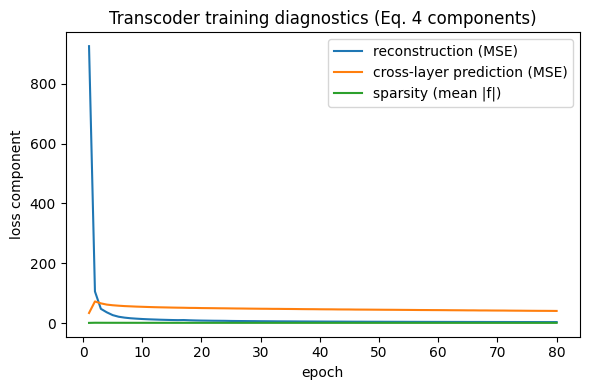

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
epochs_x = range(1, len(training_history["recon"]) + 1)
ax.plot(epochs_x, training_history["recon"], label="reconstruction (MSE)")
ax.plot(epochs_x, training_history["crosslayer"], label="cross-layer prediction (MSE)")
ax.plot(epochs_x, training_history["sparsity"], label="sparsity (mean |f|)")
ax.set_xlabel("epoch")
ax.set_ylabel("loss component")
ax.set_title("Transcoder training diagnostics (Eq. 4 components)")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
@torch.no_grad()
def reconstruction_variance(transcoders, activations, layers):
    results = {}
    for layer in layers:
        hidden = activations[layer].to(DEVICE)
        _, reconstruction = transcoders[layer](hidden)
        residual = hidden - reconstruction
        unexplained = residual.var(dim=0, unbiased=False).sum() / hidden.var(dim=0, unbiased=False).sum().clamp_min(1e-12)
        results[layer] = unexplained.item()
    return results


dark_matter = reconstruction_variance(transcoders, reconstruction_eval_acts, layers)
for layer, fraction in dark_matter.items():
    print(f"layer {layer}: held-out unexplained variance = {fraction * 100:.1f}%")

worst_unexplained = max(dark_matter.values())
if worst_unexplained > CONFIG["max_reconstruction_variance"]:
    raise RuntimeError(
        f"Reconstruction gate failed ({worst_unexplained:.1%} > "
        f"{CONFIG['max_reconstruction_variance']:.1%}). Improve the transcoder before causal attribution."
    )
print("Reconstruction gate passed.")


layer 3: held-out unexplained variance = 0.1%
layer 4: held-out unexplained variance = 0.2%
layer 5: held-out unexplained variance = 0.2%
layer 6: held-out unexplained variance = 0.3%
Reconstruction gate passed.


In [ ]:
GENERIC_TEXT_PROBES = [
    "The committee will meet on Thursday to discuss the annual budget.",
    "She walked along the river as the sun began to set over the hills.",
    "Photosynthesis converts sunlight, water, and carbon dioxide into sugar.",
    "The train was delayed for nearly an hour because of a signal failure.",
    "Many species of birds migrate thousands of miles every year.",
    "He opened the old book and found a letter tucked between the pages.",
    "The company reported a modest increase in quarterly revenue.",
    "Rain fell steadily throughout the night, flooding several streets.",
    "The museum's new exhibit features pottery from the Bronze Age.",
    "Scientists observed a sharp change in the glacier's rate of retreat.",
]


@torch.no_grad()
def collect_generic_text_activations(model, tok, sentences, layers, max_examples):
    captured = {layer: [] for layer in layers}
    blocks = get_transformer_blocks(model)
    handles = []

    def make_hook(layer):
        def hook(module, inputs, output):
            hidden = output[0] if isinstance(output, tuple) else output
            captured[layer].append(hidden.detach().float().reshape(-1, hidden.shape[-1]).cpu())
        return hook

    for layer in layers:
        handles.append(blocks[layer].register_forward_hook(make_hook(layer)))
    try:
        with evaluation_mode(model):
            for sentence in sentences[:max_examples]:
                ids = tok.encode(sentence, add_special_tokens=False)
                if not ids:
                    continue
                model(input_ids=torch.tensor([ids], device=DEVICE))
    finally:
        for handle in handles:
            handle.remove()
    return {layer: torch.cat(values, dim=0) for layer, values in captured.items() if values}


broad_probe_sentences = (
    GENERIC_TEXT_PROBES * (CONFIG["reconstruction_broad_check_examples"] // len(GENERIC_TEXT_PROBES) + 1)
)[:CONFIG["reconstruction_broad_check_examples"]]
broad_acts = collect_generic_text_activations(
    model, tokenizer, broad_probe_sentences, layers, CONFIG["reconstruction_broad_check_examples"]
)
if broad_acts:
    broad_variance = reconstruction_variance(transcoders, broad_acts, layers)
    for layer, fraction in broad_variance.items():
        print(f"layer {layer}: generic-text unexplained variance (informational) = {fraction * 100:.1f}%")
    print(
        "Informational only -- compare THIS number (not the task-only number above) against "
        "the paper's 15-20% figure; it is not part of the accuracy/reconstruction gates."
    )
else:
    print("Generic-text probe produced no activations; skipping the informational check.")


layer 3: generic-text unexplained variance (informational) = 2.5%
layer 4: generic-text unexplained variance (informational) = 2.1%
layer 5: generic-text unexplained variance (informational) = 2.1%
layer 6: generic-text unexplained variance (informational) = 1.8%
Informational only -- compare THIS number (not the task-only number above) against the paper's 15-20% figure; it is not part of the accuracy/reconstruction gates.


In [ ]:
@torch.no_grad()
def compute_layer_baseline_features(transcoders, activations, layers):
    baselines = {}
    for layer in layers:
        hidden = activations[layer].to(DEVICE)
        features = transcoders[layer].encode(hidden)
        baselines[layer] = features.mean(dim=0).detach().cpu()
    return baselines


LAYER_BASELINE_FEATURES = compute_layer_baseline_features(transcoders, cached_acts, layers)
for layer, vector in LAYER_BASELINE_FEATURES.items():
    print(f"layer {layer}: baseline feature vector computed, mean magnitude {vector.abs().mean().item():.5f}")


layer 3: baseline feature vector computed, mean magnitude 0.58943
layer 4: baseline feature vector computed, mean magnitude 0.61810
layer 5: baseline feature vector computed, mean magnitude 0.62387
layer 6: baseline feature vector computed, mean magnitude 0.65724


In [17]:
def _active_feature_indices(features, feature_cap=None):
    indices = (features != 0).nonzero(as_tuple=True)[0]
    if feature_cap is not None and len(indices) > feature_cap:
        values = features[indices].abs()
        indices = indices[torch.topk(values, feature_cap).indices]
    return indices


def attribution_between_layers(model, l_src, l_dst, tc_src, tc_dst, h_src_seq, input_ids,
                               method, ig_steps, feature_cap=None):
    blocks = get_transformer_blocks(model)
    last_pos = h_src_seq.shape[1] - 1
    source_features_full = tc_src.encode(h_src_seq)
    active_i = _active_feature_indices(source_features_full[0, last_pos], feature_cap)
    if len(active_i) == 0:
        return {}

    source_prefix = h_src_seq[:, :last_pos, :].detach()

    def run_real_path(source_features_last):
        def inject_hook(module, inputs, output):
            reconstructed_last = tc_src.decode(source_features_last).unsqueeze(1)
            running = (
                torch.cat([source_prefix, reconstructed_last], dim=1)
                if last_pos > 0 else reconstructed_last
            )
            return (running,) + output[1:] if isinstance(output, tuple) else running

        captured = {}

        def capture_hook(module, inputs, output):
            captured["hidden"] = output[0] if isinstance(output, tuple) else output

        source_handle = blocks[l_src].register_forward_hook(inject_hook)
        target_handle = blocks[l_dst].register_forward_hook(capture_hook)
        try:
            model(input_ids=input_ids)
        finally:
            source_handle.remove()
            target_handle.remove()
        return tc_dst.encode(captured["hidden"][:, -1, :])

    contributions = {}
    source_leaf = source_features_full[0, last_pos:last_pos + 1].detach()

    if method == "integrated_gradients":
        baseline = torch.zeros_like(source_leaf)
        full_target = run_real_path(source_leaf).detach()
        active_j = _active_feature_indices(full_target[0], feature_cap)
        for j in active_j.tolist():
            total_gradient = torch.zeros_like(source_leaf)
            for step in range(1, ig_steps + 1):
                alpha = step / ig_steps
                interpolated = (baseline + alpha * (source_leaf - baseline)).detach().requires_grad_(True)
                destination = run_real_path(interpolated)
                model.zero_grad(set_to_none=True)
                destination[0, j].backward()
                total_gradient += interpolated.grad.detach()
            integrated = (source_leaf - baseline) * (total_gradient / ig_steps)
            for i in active_i.tolist():
                value = integrated[0, i].item()
                if value != 0:
                    contributions[(i, j)] = value
        model.zero_grad(set_to_none=True)
        return contributions

    if method != "grad_x_act":
        raise ValueError(f"Unknown attribution method: {method}")

    source_leaf = source_leaf.clone().requires_grad_(True)
    destination = run_real_path(source_leaf)
    active_j = _active_feature_indices(destination[0], feature_cap)
    for j in active_j.tolist():
        source_leaf.grad = None
        model.zero_grad(set_to_none=True)
        destination[0, j].backward(retain_graph=True)
        contribution = source_leaf.grad[0] * source_leaf.detach()[0]
        for i in active_i.tolist():
            value = contribution[i].item()
            if value != 0:
                contributions[(i, j)] = value
    model.zero_grad(set_to_none=True)
    return contributions


`compute_attribution_graph` runs a fresh forward pass per needed
example (rather than reusing section 6's flattened, per-token cache,
which has no per-example sequence structure left to hook into) and
calls the function above for every adjacent analyzed-layer pair.

In [18]:
def as_sparse_coo(adjacency):
    return adjacency.coalesce() if adjacency.is_sparse else adjacency.to_sparse_coo().coalesce()


def sparse_nnz(adjacency):
    return int(as_sparse_coo(adjacency)._nnz())


def sparse_active_nodes(adjacency):
    coo = as_sparse_coo(adjacency)
    if coo._nnz() == 0:
        return torch.empty(0, dtype=torch.long)
    return torch.unique(coo.indices().reshape(-1)).cpu()


def sparse_node_strengths(adjacency):
    coo = as_sparse_coo(adjacency).cpu()
    strengths = torch.zeros(coo.shape[0], dtype=coo.values().dtype)
    if coo._nnz() > 0:
        values = coo.values().abs()
        strengths.index_add_(0, coo.indices()[0], values)
        strengths.index_add_(0, coo.indices()[1], values)
    return strengths


def sparse_subgraph_dense(adjacency, global_nodes):
    coo = as_sparse_coo(adjacency).cpu()
    global_nodes = torch.as_tensor(global_nodes, dtype=torch.long).cpu()
    n = len(global_nodes)
    result = torch.zeros((n, n), dtype=coo.values().dtype)
    if n == 0 or coo._nnz() == 0:
        return result
    lookup = torch.full((coo.shape[0],), -1, dtype=torch.long)
    lookup[global_nodes] = torch.arange(n)
    local_source = lookup[coo.indices()[0]]
    local_target = lookup[coo.indices()[1]]
    keep = (local_source >= 0) & (local_target >= 0)
    result[local_source[keep], local_target[keep]] = coo.values()[keep]
    return result


def sparse_edge_value_map(adjacency):
    coo = as_sparse_coo(adjacency).cpu()
    return {
        (int(src), int(dst)): float(value)
        for src, dst, value in zip(coo.indices()[0], coo.indices()[1], coo.values())
    }


def cap_active_nodes(adjacency, active_nodes, max_nodes):
    if len(active_nodes) <= max_nodes:
        return active_nodes
    strengths = sparse_node_strengths(adjacency)
    keep_order = torch.argsort(strengths[active_nodes], descending=True)[:max_nodes]
    return active_nodes[keep_order]


def compute_attribution_graph(model, tok, transcoders, examples, layers, method="grad_x_act",
                              ig_steps=10, n_examples_for_attribution=25, dict_size=None,
                              feature_cap=None):
    if dict_size is None:
        dict_size = CONFIG["dict_size"]
    offsets = {layer: i * dict_size for i, layer in enumerate(layers)}
    total_nodes = dict_size * len(layers)
    edge_values = defaultdict(float)
    blocks = get_transformer_blocks(model)
    chosen = examples[:n_examples_for_attribution]

    with evaluation_mode(model):
        for prompt, answer in chosen:
            ids, _ = encode_example(prompt, answer, tok)
            input_ids = torch.tensor([ids], device=DEVICE)
            captured = {}
            handles = []

            def make_hook(layer):
                def hook(module, inputs, output):
                    hidden = output[0] if isinstance(output, tuple) else output
                    captured[layer] = hidden.detach().float()
                return hook

            for layer in layers:
                handles.append(blocks[layer].register_forward_hook(make_hook(layer)))
            try:
                with torch.no_grad():
                    model(input_ids=input_ids)
            finally:
                for handle in handles:
                    handle.remove()

            for layer in layers[:-1]:
                contributions = attribution_between_layers(
                    model, layer, layer + 1, transcoders[layer], transcoders[layer + 1],
                    captured[layer], input_ids, method, ig_steps, feature_cap
                )
                source_offset, target_offset = offsets[layer], offsets[layer + 1]
                for (source, target), value in contributions.items():
                    edge_values[(source_offset + source, target_offset + target)] += value

    if edge_values:
        indices = torch.tensor(list(edge_values.keys()), dtype=torch.long).T
        values = torch.tensor(
            [value / max(len(chosen), 1) for value in edge_values.values()], dtype=torch.float32
        )
    else:
        indices = torch.empty((2, 0), dtype=torch.long)
        values = torch.empty(0, dtype=torch.float32)
    adjacency = torch.sparse_coo_tensor(indices, values, (total_nodes, total_nodes)).coalesce()
    return adjacency, offsets, total_nodes


require_stage("attribution graph construction")
attribution_start = time.time()
A_full, layer_offsets, n_total_nodes = compute_attribution_graph(
    model, tokenizer, transcoders, train_examples, layers,
    method=CONFIG["attribution_method"], ig_steps=CONFIG["ig_steps"],
    n_examples_for_attribution=CONFIG["attribution_examples"],
)
attribution_time = time.time() - attribution_start
STAGE_TIMES["attribution_s"] = attribution_time
print(
    f"Directed sparse attribution graph ({CONFIG['attribution_method']}) has "
    f"{sparse_nnz(A_full)} edges over {n_total_nodes} feature slots in {attribution_time:.1f}s."
)


Directed sparse attribution graph (grad_x_act) has 15362 edges over 24576 feature slots in 4.5s.


/tmp/ipykernel_542/3655486959.py:108: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  adjacency = torch.sparse_coo_tensor(indices, values, (total_nodes, total_nodes)).coalesce()


In [19]:
def sparse_overlap_correlation(first, second):
    first_values = sparse_edge_value_map(first)
    second_values = sparse_edge_value_map(second)
    common = sorted(set(first_values) & set(second_values))
    if len(common) < 2:
        return len(common), float("nan")
    x = torch.tensor([first_values[key] for key in common])
    y = torch.tensor([second_values[key] for key in common])
    return len(common), torch.corrcoef(torch.stack([x, y]))[0, 1].item()


def quick_ig_vs_gradxact_check():
    examples = train_examples[:CONFIG["ig_check_examples"]]
    gradient_graph, _, _ = compute_attribution_graph(
        model, tokenizer, transcoders, examples, layers,
        method="grad_x_act", n_examples_for_attribution=len(examples),
        feature_cap=CONFIG["ig_check_feature_cap"],
    )
    integrated_graph, _, _ = compute_attribution_graph(
        model, tokenizer, transcoders, examples, layers,
        method="integrated_gradients", ig_steps=CONFIG["ig_steps"],
        n_examples_for_attribution=len(examples), feature_cap=CONFIG["ig_check_feature_cap"],
    )
    overlap, correlation = sparse_overlap_correlation(gradient_graph, integrated_graph)
    print(f"gradient-times-activation: {sparse_nnz(gradient_graph)} sparse edges")
    print(f"integrated gradients ({CONFIG['ig_steps']} steps): {sparse_nnz(integrated_graph)} sparse edges")
    print(f"shared edges: {overlap}, correlation on shared edges: {correlation:.3f}")


if CONFIG["run_ig_sanity_check"]:
    quick_ig_vs_gradxact_check()
else:
    print("Integrated Gradients sanity check skipped; set run_ig_sanity_check=True to run it.")


gradient-times-activation: 366 sparse edges
integrated gradients (20 steps): 366 sparse edges
shared edges: 366, correlation on shared edges: 0.970


In [20]:
def sparsify_top_k_per_node(adjacency, k):
    coo = as_sparse_coo(adjacency)
    if coo._nnz() == 0:
        return coo
    indices, values = coo.indices(), coo.values()
    keep_positions = []
    for source in torch.unique(indices[0]).tolist():
        positions = (indices[0] == source).nonzero(as_tuple=True)[0]
        local_k = min(k, len(positions))
        selected = positions[torch.topk(values[positions].abs(), local_k).indices]
        keep_positions.append(selected)
    keep_positions = torch.cat(keep_positions)
    return torch.sparse_coo_tensor(
        indices[:, keep_positions], values[keep_positions], coo.shape
    ).coalesce()


A_sparse = sparsify_top_k_per_node(A_full, CONFIG["edge_topk_per_node"])
all_active_nodes = sparse_active_nodes(A_sparse)
active_nodes = cap_active_nodes(A_sparse, all_active_nodes, CONFIG["max_hierarchy_nodes"])
if len(active_nodes) < len(all_active_nodes):
    print(
        f"Hierarchy uses the {len(active_nodes)} highest-strength active nodes out of "
        f"{len(all_active_nodes)}; the full directed sparse graph is retained."
    )
print("Nodes with an incident retained edge:", len(all_active_nodes), "out of", n_total_nodes)
print(
    f"Edges after directed top-{CONFIG['edge_topk_per_node']}-per-source sparsification: "
    f"{sparse_nnz(A_sparse)}"
)


Nodes with an incident retained edge: 413 out of 24576
Edges after directed top-16-per-source sparsification: 4752


In [21]:
HIERARCHY_SOLVERS = []


def normalized_laplacian(adjacency_symmetric):
    degrees = adjacency_symmetric.sum(axis=1)
    safe_degrees = np.where(degrees > 1e-12, degrees, 1.0)
    inverse_sqrt = 1.0 / np.sqrt(safe_degrees)
    return np.eye(adjacency_symmetric.shape[0]) - (
        inverse_sqrt[:, None] * adjacency_symmetric * inverse_sqrt[None, :]
    )


def spectral_cluster_step(adjacency_symmetric, n_clusters):
    n = adjacency_symmetric.shape[0]
    k = max(1, min(n_clusters, n - 1))
    if n <= CONFIG["exact_eigh_max_nodes"]:
        _, eigenvectors = np.linalg.eigh(normalized_laplacian(adjacency_symmetric))
        embedding = eigenvectors[:, :k]
        HIERARCHY_SOLVERS.append("exact_eigh")
    else:
        degrees = adjacency_symmetric.sum(axis=1)
        inverse_sqrt = 1.0 / np.sqrt(np.maximum(degrees, 1e-12))
        sparse_adjacency = scipy_sparse.csr_matrix(adjacency_symmetric)
        diagonal = scipy_sparse.diags(inverse_sqrt)
        laplacian = scipy_sparse.eye(n, format="csr") - diagonal @ sparse_adjacency @ diagonal
        try:
            _, embedding = eigsh(laplacian, k=k, which="SM")
            HIERARCHY_SOLVERS.append("sparse_eigsh")
        except Exception as error:
            raise RuntimeError(
                "Sparse eigensolver failed on the active subgraph. Reduce max_hierarchy_nodes "
                "or inspect graph connectivity."
            ) from error
    row_norms = np.linalg.norm(embedding, axis=1, keepdims=True)
    row_norms[row_norms < 1e-12] = 1.0
    embedding = embedding / row_norms
    return KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(embedding)


def build_hierarchy(adjacency, active_nodes, branching_factor, min_cluster_size=2):
    sub_adjacency = sparse_subgraph_dense(adjacency, active_nodes).numpy()
    n = sub_adjacency.shape[0]
    if n < 2:
        return [np.arange(n)], sub_adjacency

    levels = [np.arange(n)]
    current_adjacency = sub_adjacency
    depth = max(1, math.ceil(math.log(max(n, 2), branching_factor)))
    for _ in range(depth):
        if current_adjacency.shape[0] <= min_cluster_size:
            break
        absolute_adjacency = np.abs(current_adjacency)
        symmetric_adjacency = 0.5 * (absolute_adjacency + absolute_adjacency.T)
        if symmetric_adjacency.sum() <= 1e-12:
            break
        n_clusters = max(1, min(branching_factor, current_adjacency.shape[0] - 1))
        if n_clusters < 2:
            break
        labels = spectral_cluster_step(symmetric_adjacency, n_clusters)
        levels.append(labels)

        n_supernodes = int(labels.max()) + 1
        next_adjacency = np.zeros((n_supernodes, n_supernodes), dtype=current_adjacency.dtype)
        for source_cluster in range(n_supernodes):
            source_mask = labels == source_cluster
            for target_cluster in range(n_supernodes):
                target_mask = labels == target_cluster
                next_adjacency[source_cluster, target_cluster] = current_adjacency[
                    np.ix_(source_mask, target_mask)
                ].sum()
        current_adjacency = next_adjacency
    return levels, sub_adjacency


require_stage("hierarchical decomposition")
hierarchy_start = time.time()
hierarchy_levels, sub_A_dense = build_hierarchy(
    A_sparse, active_nodes, CONFIG["hierarchy_branching_factor"]
)
hierarchy_time = time.time() - hierarchy_start
STAGE_TIMES["coarsening_s"] = hierarchy_time
print(
    f"Hierarchy built in {hierarchy_time:.2f}s with {len(hierarchy_levels)} levels; "
    f"solvers: {HIERARCHY_SOLVERS or ['trivial']}."
)
print("Nodes at level 0:", len(hierarchy_levels[0]))
if len(hierarchy_levels) > 1:
    print("Supernodes at coarsest level:", hierarchy_levels[-1].max() + 1)


Hierarchy built in 0.14s with 4 levels; solvers: ['exact_eigh', 'exact_eigh', 'exact_eigh'].
Nodes at level 0: 413
Supernodes at coarsest level: 2


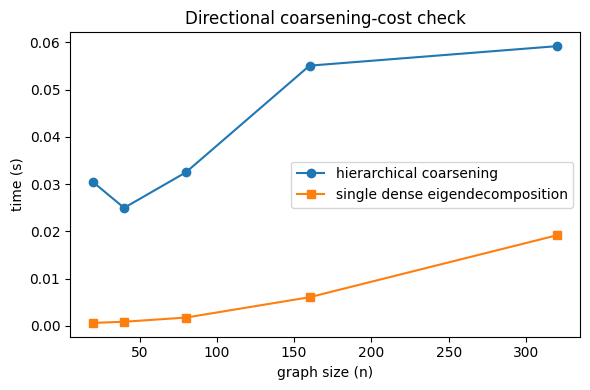

In [22]:
if CONFIG["run_scaling_sanity_check"]:
    def make_random_directed_graph(n, density=0.05, seed=0):
        rng = np.random.default_rng(seed)
        dense = rng.standard_normal((n, n)) * (rng.random((n, n)) < density)
        np.fill_diagonal(dense, 0)
        return torch.tensor(dense, dtype=torch.float32).to_sparse_coo().coalesce()

    sizes = [20, 40, 80, 160, 320]
    hierarchy_times, naive_times = [], []
    for n in sizes:
        graph = make_random_directed_graph(n, seed=1)
        nodes = torch.arange(n)
        t0 = time.time()
        build_hierarchy(graph, nodes, CONFIG["hierarchy_branching_factor"])
        hierarchy_times.append(time.time() - t0)
        t0 = time.time()
        dense = sparse_subgraph_dense(graph, nodes).numpy()
        np.linalg.eigh(normalized_laplacian(0.5 * (np.abs(dense) + np.abs(dense).T)))
        naive_times.append(time.time() - t0)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sizes, hierarchy_times, marker="o", label="hierarchical coarsening")
    ax.plot(sizes, naive_times, marker="s", label="single dense eigendecomposition")
    ax.set_xlabel("graph size (n)")
    ax.set_ylabel("time (s)")
    ax.set_title("Directional coarsening-cost check")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Scaling sanity check skipped. It is not evidence for end-to-end complexity.")




In [ ]:
def local_node_to_layer_feature(local_index, active_nodes, layer_offsets, dict_size, layers):
    global_index = int(active_nodes[local_index])
    for layer in layers:
        offset = layer_offsets[layer]
        if offset <= global_index < offset + dict_size:
            return layer, global_index - offset
    raise ValueError(f"Node {global_index} is outside the analyzed layer offsets.")


def make_reconstruct_hook(transcoder, keep_indices=None, zero_indices=None, baseline=None,
                           restrict_to_generation_steps=False):
    keep_indices = None if keep_indices is None else torch.as_tensor(
        keep_indices, dtype=torch.long, device=DEVICE
    )
    zero_indices = None if zero_indices is None else torch.as_tensor(
        zero_indices, dtype=torch.long, device=DEVICE
    )
    baseline = None if baseline is None else baseline.to(DEVICE)

    def hook(module, inputs, output):
        hidden = output[0] if isinstance(output, tuple) else output
        if restrict_to_generation_steps and hidden.shape[1] > 1:
            return output
        features = transcoder.encode(hidden)
        if keep_indices is not None:
            if baseline is not None:
                filled = baseline.to(features.dtype).expand_as(features).clone()
            else:
                filled = torch.zeros_like(features)
            filled[..., keep_indices] = features[..., keep_indices]
            features = filled
        if zero_indices is not None and len(zero_indices) > 0:
            features = features.clone()
            features[..., zero_indices] = 0.0
        reconstruction = transcoder.decode(features)
        return (reconstruction,) + output[1:] if isinstance(output, tuple) else reconstruction

    return hook


def register_reconstruction_hooks(model, transcoders, layers, keep_by_layer=None, zero_by_layer=None,
                                  baseline_by_layer=None, restrict_to_generation_steps=False):
    blocks = get_transformer_blocks(model)
    handles = []
    for layer in layers:
        keep = None if keep_by_layer is None else keep_by_layer.get(layer, [])
        zero = None if zero_by_layer is None else zero_by_layer.get(layer, [])
        baseline = None if baseline_by_layer is None else baseline_by_layer.get(layer, None)
        handles.append(
            blocks[layer].register_forward_hook(
                make_reconstruct_hook(
                    transcoders[layer], keep, zero, baseline, restrict_to_generation_steps
                )
            )
        )
    return handles


@torch.no_grad()
def task_loss_on_examples(model, tok, examples, max_examples=60, transcoders=None, layers=None,
                          keep_by_layer=None, zero_by_layer=None):
    selected = examples[:max_examples]
    if not selected:
        return float("nan")
    handles = []
    total = 0.0
    try:
        with evaluation_mode(model):
            if transcoders is not None:
                handles = register_reconstruction_hooks(
                    model, transcoders, layers, keep_by_layer=keep_by_layer, zero_by_layer=zero_by_layer
                )
            for prompt, answer in selected:
                ids, labels = encode_example(prompt, answer, tok)
                outputs = model(
                    input_ids=torch.tensor([ids], device=DEVICE),
                    labels=torch.tensor([labels], device=DEVICE),
                )
                total += outputs.loss.item()
    finally:
        for handle in handles:
            handle.remove()
    return total / len(selected)


def adaptive_necessity_threshold(scores_dict, fixed_epsilon, quantile):
    values = np.asarray(list(scores_dict.values()), dtype=float)
    if len(values) < 2:
        return None, False
    fixed_passes = int((values >= fixed_epsilon).sum())
    if 0 < fixed_passes < len(values):
        return fixed_epsilon, False
    ordered = np.sort(values)
    target_cut = max(1, min(len(values) - 1, int(math.ceil(quantile * len(values)))))
    candidate_cuts = list(range(target_cut, len(values))) + list(range(target_cut - 1, 0, -1))
    for cut in candidate_cuts:
        lower, upper = ordered[cut - 1], ordered[cut]
        if upper > lower:
            threshold = float((lower + upper) / 2)
            passes = int((values >= threshold).sum())
            if 0 < passes < len(values):
                print(
                    f"Fixed necessity epsilon produced {fixed_passes}/{len(values)} positives; "
                    f"using a disclosed data-adaptive split at {threshold:.5f}."
                )
                return threshold, True
    return None, True


def resolve_necessity_epsilon(reconstruction_loss):
    if CONFIG["necessity_epsilon_mode"] == "relative":
        return CONFIG["necessity_epsilon_relative_fraction"] * abs(reconstruction_loss)
    return CONFIG["necessity_epsilon"]


def mixed_candidate_indices(importance, pool_size, top_fraction, seed):
    n = len(importance)
    pool_size = min(pool_size, n)
    n_top = min(pool_size, max(1, int(round(pool_size * top_fraction))))
    ranked = np.argsort(-importance)
    top = ranked[:n_top].tolist()
    remaining = ranked[n_top:]
    random_count = pool_size - len(top)
    if random_count:
        rng = np.random.default_rng(seed)
        sampled = rng.choice(remaining, size=min(random_count, len(remaining)), replace=False).tolist()
    else:
        sampled = []
    return top + sampled


def real_necessity_scores(model, tok, transcoders, layer_offsets, dict_size, layers,
                          candidate_local_indices, active_nodes, evaluation_examples,
                          max_eval_examples=60):
    full_loss = task_loss_on_examples(model, tok, evaluation_examples, max_eval_examples)
    reconstruction_loss = task_loss_on_examples(
        model, tok, evaluation_examples, max_eval_examples, transcoders=transcoders, layers=layers
    )
    scores = {}
    for local_index in candidate_local_indices:
        layer, feature_index = local_node_to_layer_feature(
            local_index, active_nodes, layer_offsets, dict_size, layers
        )
        ablated_loss = task_loss_on_examples(
            model, tok, evaluation_examples, max_eval_examples, transcoders=transcoders, layers=layers,
            zero_by_layer={layer: [feature_index]},
        )
        scores[local_index] = ablated_loss - reconstruction_loss
    return scores, full_loss, reconstruction_loss


require_stage("necessity ground truth / GNN preparation")
n_active = len(active_nodes)
importance_proxy = np.abs(sub_A_dense).sum(axis=1) + np.abs(sub_A_dense).sum(axis=0)
gt_candidates = mixed_candidate_indices(
    importance_proxy, CONFIG["gt_candidate_pool"], CONFIG["gt_top_fraction"], SEED
)

ground_truth_start = time.time()
gt_scores, gt_full_loss, gt_reconstruction_loss = real_necessity_scores(
    model, tokenizer, transcoders, layer_offsets, CONFIG["dict_size"], layers,
    gt_candidates, active_nodes, eval_examples, CONFIG["necessity_eval_examples"],
)
gt_time = time.time() - ground_truth_start
STAGE_TIMES["ground_truth_interventions_s"] = gt_time
effective_epsilon, epsilon_fell_back = adaptive_necessity_threshold(
    gt_scores, resolve_necessity_epsilon(gt_reconstruction_loss), CONFIG["necessity_quantile"]
)
if effective_epsilon is None:
    raise RuntimeError(
        "Necessity labels are still degenerate after using a reconstruction baseline and mixed candidates. "
        "Do not train a GNN on a single class."
    )
positive_count = sum(value >= effective_epsilon for value in gt_scores.values())
print(
    f"Ground truth: {len(gt_candidates)} mixed candidates in {gt_time:.1f}s; "
    f"full loss {gt_full_loss:.4f}, all-features reconstruction loss {gt_reconstruction_loss:.4f}."
)
print(
    f"{positive_count}/{len(gt_candidates)} necessary at epsilon {effective_epsilon:.5f} "
    f"({'adaptive' if epsilon_fell_back else CONFIG['necessity_epsilon_mode']})."
)


Ground truth: 160 mixed candidates in 199.0s; full loss 0.5011, all-features reconstruction loss 0.5304.
57/160 necessary at epsilon 0.00796 (relative).


In [ ]:
class GATLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(dim, dim), nn.ReLU(), nn.Linear(dim, dim))
        self.attn = nn.Linear(2 * dim, 1, bias=False)
        self.score = nn.Linear(dim, 1)

    def forward(self, node_features, adjacency):
        n = node_features.shape[0]
        mask = (adjacency > 0)
        mask = mask | torch.eye(n, dtype=torch.bool, device=node_features.device)
        source_features = node_features.unsqueeze(1).expand(n, n, -1)
        destination_features = node_features.unsqueeze(0).expand(n, n, -1)
        energies = self.attn(torch.cat([source_features, destination_features], dim=-1)).squeeze(-1)
        energies = energies.masked_fill(~mask, float("-inf"))
        attention = torch.softmax(energies, dim=0)
        aggregate = torch.einsum("uv,ud->vd", attention, node_features)
        return self.mlp(node_features + aggregate)

    def membership_scores(self, node_features):
        return torch.sigmoid(self.score(node_features)).squeeze(-1)


def graph_node_features(sub_adjacency):
    magnitude = np.abs(sub_adjacency)
    outgoing = magnitude.sum(axis=1)
    incoming = magnitude.sum(axis=0)
    degree = (magnitude > 0).sum(axis=1) + (magnitude > 0).sum(axis=0)
    signed_balance = sub_adjacency.sum(axis=1) - sub_adjacency.sum(axis=0)
    nonzero_mask = magnitude > 0
    incident_count = np.maximum(nonzero_mask.sum(axis=1) + nonzero_mask.sum(axis=0), 1)
    mean_incident_weight = (magnitude.sum(axis=1) + magnitude.sum(axis=0)) / incident_count
    max_incident_weight = np.maximum(magnitude.max(axis=1), magnitude.max(axis=0))
    features = np.stack([
        np.log1p(outgoing), np.log1p(incoming), np.log1p(degree), signed_balance,
        np.log1p(mean_incident_weight), np.log1p(max_incident_weight),
    ], axis=1).astype(np.float32)
    features = (features - features.mean(axis=0, keepdims=True)) / (
        features.std(axis=0, keepdims=True) + 1e-6
    )
    return torch.tensor(features, dtype=torch.float32)


def stratified_label_masks(score_dict, threshold, n_nodes, holdout_fraction, seed):
    positive = [index for index, value in score_dict.items() if value >= threshold]
    negative = [index for index, value in score_dict.items() if value < threshold]
    if min(len(positive), len(negative)) < 2:
        raise RuntimeError("Need at least two necessity labels from each class for a held-out GNN diagnostic.")
    rng = random.Random(seed)
    rng.shuffle(positive)
    rng.shuffle(negative)
    n_positive_holdout = max(1, int(round(len(positive) * holdout_fraction)))
    n_negative_holdout = max(1, int(round(len(negative) * holdout_fraction)))
    validation_indices = set(positive[:n_positive_holdout] + negative[:n_negative_holdout])
    train_indices = set(score_dict) - validation_indices
    train_mask = torch.zeros(n_nodes, dtype=torch.bool)
    validation_mask = torch.zeros(n_nodes, dtype=torch.bool)
    labels = torch.zeros(n_nodes, dtype=torch.float32)
    for index, value in score_dict.items():
        labels[index] = float(value >= threshold)
        (validation_mask if index in validation_indices else train_mask)[index] = True
    return train_mask, validation_mask, labels


sub_A_t = torch.tensor(sub_A_dense, dtype=torch.float32)
adj_bin = (sub_A_t.abs() > 0).float()
z0 = graph_node_features(sub_A_dense)
train_mask, validation_mask, train_labels = stratified_label_masks(
    gt_scores, effective_epsilon, n_active, CONFIG["gnn_label_holdout"], SEED
)
gat_layers = nn.ModuleList([GATLayer(z0.shape[1]) for _ in range(CONFIG["gnn_num_layers"])])
gat_opt = torch.optim.AdamW(
    gat_layers.parameters(), lr=1e-2, weight_decay=CONFIG["gnn_weight_decay"]
)
gnn_start = time.time()
best_val_auroc = -1.0
best_gat_epoch = None
best_gat_state = None
evals_since_best_gnn = 0
validation_truth_running = train_labels[validation_mask].numpy()
has_both_classes_val = len(np.unique(validation_truth_running)) == 2

for epoch in range(1, CONFIG["gnn_epochs"] + 1):
    z = z0
    for layer_module in gat_layers:
        z = layer_module(z, adj_bin)
    scores = gat_layers[-1].membership_scores(z)
    loss = F.binary_cross_entropy(scores[train_mask], train_labels[train_mask])
    gat_opt.zero_grad(set_to_none=True)
    loss.backward()
    gat_opt.step()

    if has_both_classes_val and (epoch % CONFIG["gnn_eval_every"] == 0 or epoch == 1):
        with torch.no_grad():
            z_eval = z0
            for layer_module in gat_layers:
                z_eval = layer_module(z_eval, adj_bin)
            eval_scores = gat_layers[-1].membership_scores(z_eval)
        val_scores_running = eval_scores[validation_mask].numpy()
        val_auroc_running = roc_auc_score(validation_truth_running, val_scores_running)
        if val_auroc_running > best_val_auroc:
            best_val_auroc = val_auroc_running
            best_gat_epoch = epoch
            best_gat_state = [
                {key: value.detach().clone() for key, value in layer_module.state_dict().items()}
                for layer_module in gat_layers
            ]
            evals_since_best_gnn = 0
        else:
            evals_since_best_gnn += 1
        if epoch >= CONFIG["gnn_min_epochs"] and evals_since_best_gnn >= CONFIG["gnn_patience"]:
            break
STAGE_TIMES["gnn_train_s"] = time.time() - gnn_start

if best_gat_state is not None:
    for layer_module, state in zip(gat_layers, best_gat_state):
        layer_module.load_state_dict(state)
    print(f"GNN early stopping: restored epoch {best_gat_epoch} (held-out AUROC {best_val_auroc:.3f}).")
else:
    print("GNN: no finite held-out AUROC observed during training; keeping final-epoch weights.")

with torch.no_grad():
    z = z0
    for layer_module in gat_layers:
        z = layer_module(z, adj_bin)
    final_scores = gat_layers[-1].membership_scores(z)
train_truth = train_labels[train_mask].numpy()
train_scores_np = final_scores[train_mask].numpy()
train_pred = (train_scores_np >= 0.5).astype(np.float32)
train_balanced_accuracy = balanced_accuracy_score(train_truth, train_pred)
train_auc = (
    roc_auc_score(train_truth, train_scores_np) if len(np.unique(train_truth)) == 2 else float("nan")
)

validation_truth = train_labels[validation_mask].numpy()
validation_scores = final_scores[validation_mask].numpy()
validation_pred = (validation_scores >= 0.5).astype(np.float32)
validation_balanced_accuracy = balanced_accuracy_score(validation_truth, validation_pred)
validation_auc = (
    roc_auc_score(validation_truth, validation_scores)
    if len(np.unique(validation_truth)) == 2 else float("nan")
)
print(
    f"GNN trained on {int(train_mask.sum())} labels "
    f"({int(train_labels[train_mask].sum())} positive) with {CONFIG['gnn_num_layers']} attention layer(s); "
    f"train-set balanced accuracy {train_balanced_accuracy:.3f}, AUROC {train_auc:.3f}."
)
print(
    f"Held-out balanced accuracy {validation_balanced_accuracy:.3f}, AUROC {validation_auc:.3f}. "
    "This is a within-task label-holdout diagnostic, not cross-task or unseen-model generalization."
)


def evaluate_cross_task_gnn(train_task_records, held_out_task_record, epochs=None):
    if not train_task_records:
        raise ValueError("Provide at least one source-task record.")
    required = {"features", "adjacency", "labels", "label_mask"}
    if any(not required <= set(record) for record in train_task_records + [held_out_task_record]):
        raise ValueError("Each task record needs features, adjacency, labels, and label_mask.")
    feature_dim = train_task_records[0]["features"].shape[1]
    if any(record["features"].shape[1] != feature_dim for record in train_task_records + [held_out_task_record]):
        raise ValueError("All task records must use the same structural feature width.")

    meta_layers = nn.ModuleList([GATLayer(feature_dim) for _ in range(CONFIG["gnn_num_layers"])])
    optimizer = torch.optim.AdamW(meta_layers.parameters(), lr=1e-2)
    for _ in range(epochs or CONFIG["gnn_epochs"]):
        optimizer.zero_grad(set_to_none=True)
        losses = []
        for record in train_task_records:
            z = record["features"]
            for layer_module in meta_layers:
                z = layer_module(z, record["adjacency"])
            prediction = meta_layers[-1].membership_scores(z)
            losses.append(F.binary_cross_entropy(
                prediction[record["label_mask"]], record["labels"][record["label_mask"]]
            ))
        loss = torch.stack(losses).mean()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        z = held_out_task_record["features"]
        for layer_module in meta_layers:
            z = layer_module(z, held_out_task_record["adjacency"])
        prediction = meta_layers[-1].membership_scores(z)
    mask = held_out_task_record["label_mask"]
    truth = held_out_task_record["labels"][mask].numpy()
    values = prediction[mask].numpy()
    if len(np.unique(truth)) < 2:
        raise RuntimeError("Held-out task labels must contain both classes for a cross-task diagnostic.")
    return {
        "balanced_accuracy": balanced_accuracy_score(truth, (values >= 0.5).astype(np.float32)),
        "auroc": roc_auc_score(truth, values),
        "n_held_out_labels": int(mask.sum()),
    }


current_task_gnn_record = {
    "features": z0.detach(),
    "adjacency": adj_bin.detach(),
    "labels": train_labels.detach(),
    "label_mask": train_mask | validation_mask,
}
if CONFIG.get("run_cross_task_gnn_check", False):
    print(
        "Cross-task GNN evaluation needs two independently generated source-task records "
        "and one held-out task record. Call evaluate_cross_task_gnn once those causal labels exist."
    )


GNN early stopping: restored epoch 30 (held-out AUROC 0.709).
GNN trained on 120 labels (43 positive) with 2 attention layer(s); train-set balanced accuracy 0.557, AUROC 0.662.
Held-out balanced accuracy 0.481, AUROC 0.709. This is a within-task label-holdout diagnostic, not cross-task or unseen-model generalization.
Cross-task GNN evaluation needs two independently generated source-task records and one held-out task record. Call evaluate_cross_task_gnn once those causal labels exist.


In [25]:
def coarse_to_fine_traversal(hierarchy_levels, node_scores, topk_per_level):
    scores = node_scores.detach().cpu().numpy()
    n_levels = len(hierarchy_levels)
    n_leaves = len(hierarchy_levels[0])
    if n_levels == 1:
        return np.argsort(-scores)[:min(topk_per_level, n_leaves)].tolist()

    leaf_to_level = [np.arange(n_leaves)]
    for level in range(1, n_levels):
        leaf_to_level.append(hierarchy_levels[level][leaf_to_level[-1]])

    surviving = np.ones(n_leaves, dtype=bool)
    for level in range(n_levels - 1, 0, -1):
        supernode_ids = leaf_to_level[level]
        n_supernodes = int(supernode_ids.max()) + 1
        super_scores = np.full(n_supernodes, -np.inf)
        for supernode in range(n_supernodes):
            members = np.where((supernode_ids == supernode) & surviving)[0]
            if len(members):
                super_scores[supernode] = scores[members].mean()
        keep = set(np.argsort(-super_scores)[:min(topk_per_level, n_supernodes)].tolist())
        surviving &= np.isin(supernode_ids, list(keep))
    return np.where(surviving)[0].tolist()


def select_connected_candidate_region(sub_adjacency, traversal_nodes, node_scores, max_nodes,
                                      neighbor_expansion):
    if not traversal_nodes:
        return []
    undirected = np.maximum(np.abs(sub_adjacency), np.abs(sub_adjacency).T)
    eligible = set(traversal_nodes)
    for node in traversal_nodes:
        neighbors = np.flatnonzero(undirected[node] > 0)
        if len(neighbors):
            strongest = neighbors[np.argsort(-undirected[node, neighbors])[:neighbor_expansion]]
            eligible.update(strongest.tolist())

    ranked_seeds = sorted(eligible, key=lambda node: (-float(node_scores[node]), node))
    seed = next(
        (node for node in ranked_seeds if any(neighbor in eligible for neighbor in np.flatnonzero(undirected[node] > 0))),
        None,
    )
    if seed is None:
        return []

    selected = [seed]
    selected_set = {seed}
    while len(selected) < max_nodes:
        boundary = []
        for candidate in eligible - selected_set:
            connections = undirected[candidate, selected]
            if connections.size and connections.max() > 0:
                boundary.append((candidate, float(connections.max())))
        if not boundary:
            break
        candidate, _ = max(
            boundary,
            key=lambda item: (float(node_scores[item[0]]), item[1], -item[0]),
        )
        selected.append(candidate)
        selected_set.add(candidate)
    return selected


def largest_connected_component(nodes, sub_adjacency, node_scores):
    nodes = list(nodes)
    if not nodes:
        return []
    undirected = np.maximum(np.abs(sub_adjacency), np.abs(sub_adjacency).T)
    remaining = set(nodes)
    components = []
    while remaining:
        root = remaining.pop()
        component = {root}
        frontier = [root]
        while frontier:
            current = frontier.pop()
            neighbors = set(np.flatnonzero(undirected[current] > 0).tolist()) & remaining
            remaining -= neighbors
            component |= neighbors
            frontier.extend(neighbors)
        components.append(sorted(component))
    return max(
        components,
        key=lambda component: (len(component), sum(float(node_scores[node]) for node in component)),
    )


traversal_start = time.time()
traversal_nodes = coarse_to_fine_traversal(
    hierarchy_levels, final_scores, CONFIG["traversal_topk_per_level"]
)
top_candidates = select_connected_candidate_region(
    sub_A_dense, traversal_nodes, final_scores.detach().cpu().numpy(),
    CONFIG["traversal_max_candidates"], CONFIG["connected_neighbor_expansion"],
)
STAGE_TIMES["hierarchical_search_s"] = time.time() - traversal_start
if len(top_candidates) < 2:
    raise RuntimeError("Connected traversal found fewer than two linked candidates; do not form an edgeless circuit.")
internal_candidate_edges = int((sparse_subgraph_dense(A_sparse, active_nodes[top_candidates]) != 0).sum().item())
print(
    f"Coarse-to-fine traversal retained {len(traversal_nodes)}/{n_active} leaves; "
    f"connected expansion selected {len(top_candidates)} candidates with {internal_candidate_edges} internal directed edges."
)




Coarse-to-fine traversal retained 261/413 leaves; connected expansion selected 48 candidates with 98 internal directed edges.


In [26]:
require_stage("causal validation")
validation_start = time.time()
necessity = dict(gt_scores)

for local_index in top_candidates:
    if local_index in necessity:
        continue
    layer, feature_index = local_node_to_layer_feature(
        local_index, active_nodes, layer_offsets, CONFIG["dict_size"], layers
    )
    ablated_loss = task_loss_on_examples(
        model, tokenizer, eval_examples, CONFIG["necessity_eval_examples"],
        transcoders=transcoders, layers=layers, zero_by_layer={layer: [feature_index]},
    )
    necessity[local_index] = ablated_loss - gt_reconstruction_loss

circuit_nodes = [
    local_index for local_index in top_candidates
    if necessity.get(local_index, float("-inf")) >= effective_epsilon
]
circuit_nodes = largest_connected_component(
    circuit_nodes, sub_A_dense, final_scores.detach().cpu().numpy()
)
if len(circuit_nodes) < 2:
    raise RuntimeError(
        "Necessity pruning did not leave a connected multi-node circuit. "
        "Do not report an edgeless feature bag as a circuit."
    )
print(
    f"Connected circuit after necessity pruning: {len(circuit_nodes)} of "
    f"{len(top_candidates)} candidates survive at epsilon {effective_epsilon:.5f}."
)
for local_index in sorted(circuit_nodes, key=lambda item: -necessity[item])[:10]:
    print(f"  node {local_index}: marginal reconstruction-baseline delta = {necessity[local_index]:.5f}")


Connected circuit after necessity pruning: 13 of 48 candidates survive at epsilon 0.00796.
  node 337: marginal reconstruction-baseline delta = 0.19314
  node 321: marginal reconstruction-baseline delta = 0.08973
  node 395: marginal reconstruction-baseline delta = 0.07288
  node 352: marginal reconstruction-baseline delta = 0.05397
  node 277: marginal reconstruction-baseline delta = 0.02504
  node 381: marginal reconstruction-baseline delta = 0.02258
  node 357: marginal reconstruction-baseline delta = 0.01652
  node 309: marginal reconstruction-baseline delta = 0.01455
  node 295: marginal reconstruction-baseline delta = 0.01211
  node 332: marginal reconstruction-baseline delta = 0.01120


In [27]:
def refine_edges(adjacency, active_nodes, circuit_local_nodes, keep_fraction):
    global_nodes = active_nodes[torch.as_tensor(circuit_local_nodes, dtype=torch.long)]
    subgraph = sparse_subgraph_dense(adjacency, global_nodes)
    nonzero = (subgraph != 0).nonzero(as_tuple=False)
    if len(nonzero) == 0:
        return set(), 0, 0
    weights = subgraph[nonzero[:, 0], nonzero[:, 1]].abs()
    threshold = float(weights.max()) * keep_fraction
    retained = set()
    for source_position, target_position in nonzero.tolist():
        if abs(float(subgraph[source_position, target_position])) >= threshold:
            retained.add((
                int(circuit_local_nodes[source_position]),
                int(circuit_local_nodes[target_position]),
            ))
    return retained, int(len(nonzero)), len(retained)


def largest_component_from_edges(nodes, edges, node_scores):
    nodes = list(nodes)
    adjacency = {node: set() for node in nodes}
    for source, target in edges:
        if source in adjacency and target in adjacency:
            adjacency[source].add(target)
            adjacency[target].add(source)
    remaining = set(nodes)
    components = []
    while remaining:
        root = remaining.pop()
        component = {root}
        frontier = [root]
        while frontier:
            current = frontier.pop()
            new_neighbors = adjacency[current] & remaining
            remaining -= new_neighbors
            component |= new_neighbors
            frontier.extend(new_neighbors)
        components.append(sorted(component))
    return max(
        components,
        key=lambda component: (len(component), sum(float(node_scores[node]) for node in component)),
    )


refined_circuit_edges, edges_before, edges_after = refine_edges(
    A_sparse, active_nodes, circuit_nodes, CONFIG["refined_edge_keep_fraction"]
)
circuit_nodes = largest_component_from_edges(
    circuit_nodes, refined_circuit_edges, final_scores.detach().cpu().numpy()
)
refined_circuit_edges, edges_before, edges_after = refine_edges(
    A_sparse, active_nodes, circuit_nodes, CONFIG["refined_edge_keep_fraction"]
)
if len(circuit_nodes) < 2 or edges_after == 0:
    raise RuntimeError(
        "Edge refinement left no connected circuit edge. Adjust traversal or sparsification; "
        "do not report zero-edge circuits."
    )
print(
    f"Edge refinement retained {edges_after}/{edges_before} directed internal edges "
    f"across the connected {len(circuit_nodes)}-node circuit."
)


Edge refinement retained 9/9 directed internal edges across the connected 10-node circuit.


In [28]:
def circuit_keep_indices_per_layer(circuit_nodes, active_nodes, layer_offsets, dict_size, layers):
    per_layer = {layer: [] for layer in layers}
    for local_index in circuit_nodes:
        layer, feature_index = local_node_to_layer_feature(
            local_index, active_nodes, layer_offsets, dict_size, layers
        )
        per_layer[layer].append(feature_index)
    return per_layer


per_layer_keep = circuit_keep_indices_per_layer(
    circuit_nodes, active_nodes, layer_offsets, CONFIG["dict_size"], layers
)
handles = register_reconstruction_hooks(
    model, transcoders, layers, keep_by_layer=per_layer_keep,
    baseline_by_layer=LAYER_BASELINE_FEATURES,
)
try:
    acc_circuit = evaluate_task_accuracy(model, tokenizer, eval_examples)
finally:
    for handle in handles:
        handle.remove()
acc_full = evaluate_task_accuracy(model, tokenizer, eval_examples)
if not np.isfinite(acc_full) or acc_full <= 0:
    raise RuntimeError("Full-model accuracy denominator is invalid; preservation is undefined.")

phi = acc_circuit / acc_full
sufficient = phi >= CONFIG["sufficiency_threshold"]
validation_time = time.time() - validation_start
STAGE_TIMES["causal_validation_s"] = validation_time
print(f"Acc(full model) = {acc_full:.3f}")
print(f"Acc(circuit-restricted model) = {acc_circuit:.3f}")
print(
    f"phi(C) = {phi:.3f} -> {'sufficient' if sufficient else 'not yet sufficient'} "
    f"(threshold {CONFIG['sufficiency_threshold']:.2f})"
)

CIRCUIT_VALIDATED = (
    len(circuit_nodes) >= CONFIG["min_circuit_nodes_for_downstream"]
    and np.isfinite(phi) and phi >= CONFIG["min_phi_for_downstream"]
)
print(
    f"CIRCUIT_VALIDATED = {CIRCUIT_VALIDATED} (needs >= {CONFIG['min_circuit_nodes_for_downstream']} nodes "
    f"and phi >= {CONFIG['min_phi_for_downstream']:.2f}; got {len(circuit_nodes)} nodes, phi={phi:.3f}). "
    "The task-comparison, ablation, and transfer sections below stay skipped until this is True."
)




Acc(full model) = 0.838
Acc(circuit-restricted model) = 0.000
phi(C) = 0.000 -> not yet sufficient (threshold 0.90)
CIRCUIT_VALIDATED = False (needs >= 10 nodes and phi >= 0.30; got 10 nodes, phi=0.000). The task-comparison, ablation, and transfer sections below stay skipped until this is True.


In [ ]:
if CONFIG["run_diagnostic_null_reconstruction"]:
    require_stage("diagnostic: null reconstruction sanity check")
    handles = register_reconstruction_hooks(model, transcoders, layers)
    try:
        acc_null_reconstruction = evaluate_task_accuracy(model, tokenizer, eval_examples)
    finally:
        for handle in handles:
            handle.remove()
    print(
        f"Acc(full model, no hooks) = {acc_full:.3f}\n"
        f"Acc(all 4 layers passed through natural transcoder reconstruction, "
        f"nothing restricted) = {acc_null_reconstruction:.3f}"
    )
    reconstruction_gap = acc_full - acc_null_reconstruction
    if reconstruction_gap > 0.05:
        print(
            f"Gap of {reconstruction_gap:.3f}: a meaningful share of the phi=0.000 result may "
            "be reconstruction/generation error compounding across four layers and multiple "
            "generation steps, separate from circuit restriction entirely."
        )
    else:
        print(
            f"Gap of {reconstruction_gap:.3f}: natural reconstruction alone costs little. The "
            "phi=0.000 result is therefore attributable to circuit RESTRICTION specifically, "
            "not to the transcoder/hook mechanism itself."
        )
else:
    print("Diagnostic Test 1 (null reconstruction) skipped.")


Acc(full model, no hooks) = 0.838
Acc(all 4 layers passed through natural transcoder reconstruction, nothing restricted) = 0.810
Gap of 0.029: natural reconstruction alone costs little. The phi=0.000 result is therefore attributable to circuit RESTRICTION specifically, not to the transcoder/hook mechanism itself.


In [ ]:
if CONFIG["run_diagnostic_single_layer_sweep"]:
    require_stage("diagnostic: single-layer restriction sweep")
    single_layer_records = []
    for probe_layer in layers:
        handles = register_reconstruction_hooks(
            model, transcoders, [probe_layer],
            keep_by_layer={probe_layer: per_layer_keep.get(probe_layer, [])},
            baseline_by_layer=LAYER_BASELINE_FEATURES,
        )
        try:
            acc_single = evaluate_task_accuracy(model, tokenizer, eval_examples)
        finally:
            for handle in handles:
                handle.remove()
        single_layer_records.append({
            "layer": probe_layer,
            "kept_features": len(per_layer_keep.get(probe_layer, [])),
            "acc": acc_single,
            "phi": acc_single / acc_full if acc_full > 0 else float("nan"),
        })
    rows = "\n".join(
        f"| {record['layer']} | {record['kept_features']} | {record['acc']:.3f} | {record['phi']:.3f} |"
        for record in single_layer_records
    )
    display(Markdown(
        "| layer restricted (others untouched) | kept features | accuracy | phi |\n"
        "|---:|---:|---:|---:|\n" + rows
    ))
    if any(record["phi"] > 0.05 for record in single_layer_records):
        print(
            "At least one single-layer restriction shows meaningful phi. The four-"
            "simultaneous-layers intervention -- not the circuit's content -- looks like the "
            "dominant driver of the full phi=0.000 result."
        )
    else:
        print(
            "Every single-layer restriction is also ~0. The circuit's content itself, not "
            "merely doing four layers at once, looks like the bottleneck."
        )
else:
    print("Diagnostic Test 2 (single-layer restriction sweep) skipped.")


| layer restricted (others untouched) | kept features | accuracy | phi |
|---:|---:|---:|---:|
| 3 | 0 | 0.000 | 0.000 |
| 4 | 0 | 0.000 | 0.000 |
| 5 | 1 | 0.000 | 0.000 |
| 6 | 9 | 0.038 | 0.045 |

Every single-layer restriction is also ~0. The circuit's content itself, not merely doing four layers at once, looks like the bottleneck.


In [ ]:
@torch.no_grad()
def circuit_feature_activation_rates(circuit_layer_features, examples, max_examples):
    blocks = get_transformer_blocks(model)
    captured = {}

    def make_capture_hook(layer):
        def hook(module, inputs, output):
            hidden = output[0] if isinstance(output, tuple) else output
            captured[layer] = transcoders[layer].encode(hidden)
        return hook

    handles = [blocks[layer].register_forward_hook(make_capture_hook(layer)) for layer in layers]
    counts = {pair: 0 for pair in circuit_layer_features}
    total_positions = 0
    try:
        with evaluation_mode(model):
            for prompt, answer in examples[:max_examples]:
                ids = tokenizer.encode(prompt, add_special_tokens=False)
                if not ids:
                    continue
                model(input_ids=torch.tensor([ids], device=DEVICE))
                total_positions += len(ids)
                for feature_layer, feature_index in circuit_layer_features:
                    active_count = (captured[feature_layer][0, :, feature_index] > 0).sum().item()
                    counts[(feature_layer, feature_index)] += active_count
    finally:
        for handle in handles:
            handle.remove()
    return {pair: count / max(total_positions, 1) for pair, count in counts.items()}, total_positions


if CONFIG["run_diagnostic_feature_activation_rates"]:
    require_stage("diagnostic: circuit feature activation rates")
    circuit_layer_features = [
        local_node_to_layer_feature(node, active_nodes, layer_offsets, CONFIG["dict_size"], layers)
        for node in circuit_nodes
    ]
    scoring_rates, scoring_positions = circuit_feature_activation_rates(
        circuit_layer_features, eval_examples, CONFIG["necessity_eval_examples"]
    )
    broad_rates, broad_positions = circuit_feature_activation_rates(
        circuit_layer_features, train_examples, CONFIG["diagnostic_activation_rate_broad_examples"]
    )
    rows = "\n".join(
        f"| {feature_layer} | {feature_index} | {scoring_rates[(feature_layer, feature_index)] * 100:.2f}% | "
        f"{broad_rates[(feature_layer, feature_index)] * 100:.2f}% |"
        for feature_layer, feature_index in circuit_layer_features
    )
    display(Markdown(
        f"Scoring sample: {scoring_positions} token positions across "
        f"{CONFIG['necessity_eval_examples']} held-out examples. Broad sample: {broad_positions} "
        f"token positions across {CONFIG['diagnostic_activation_rate_broad_examples']} TRAINING "
        "examples (a structurally different source, not a larger slice of the same held-out "
        "pool -- see revision history v19).\n\n"
        "| layer | feature | activation rate (scoring sample) | activation rate (broad sample) |\n"
        "|---:|---:|---:|---:|\n" + rows
    ))
    mean_scoring = sum(scoring_rates.values()) / max(len(scoring_rates), 1)
    mean_broad = sum(broad_rates.values()) / max(len(broad_rates), 1)
    print(
        f"Mean activation rate: {mean_scoring * 100:.2f}% (scoring sample) vs "
        f"{mean_broad * 100:.2f}% (broad sample)."
    )
    if mean_broad < mean_scoring * 0.5:
        print(
            "Meaningfully rarer on the broader sample: consistent with the circuit being "
            "overfit to the specific prompts it was scored on, not a general-purpose "
            "computation for this task."
        )
    else:
        print(
            "Activation rate holds up on the broader sample: the circuit's features are not "
            "obviously overfit to the scoring sample specifically."
        )
else:
    print("Diagnostic Test 3 (feature activation rates) skipped.")


Scoring sample: 857 token positions across 200 held-out examples. Broad sample: 1628 token positions across 200 TRAINING examples (a structurally different source, not a larger slice of the same held-out pool -- see revision history v19).

| layer | feature | activation rate (scoring sample) | activation rate (broad sample) |
|---:|---:|---:|---:|
| 5 | 3272 | 13.54% | 13.08% |
| 6 | 622 | 15.17% | 14.99% |
| 6 | 1640 | 18.90% | 19.96% |
| 6 | 1957 | 15.05% | 16.34% |
| 6 | 2010 | 7.47% | 7.43% |
| 6 | 2103 | 52.98% | 52.70% |
| 6 | 3269 | 13.54% | 12.35% |
| 6 | 3429 | 13.65% | 14.07% |
| 6 | 3440 | 14.82% | 14.13% |
| 6 | 5580 | 51.46% | 51.47% |

Mean activation rate: 21.66% (scoring sample) vs 21.65% (broad sample).
Activation rate holds up on the broader sample: the circuit's features are not obviously overfit to the scoring sample specifically.


In [ ]:
if CONFIG["run_diagnostic_position_scoped_sufficiency"]:
    require_stage("diagnostic: position-scoped sufficiency test")
    handles = register_reconstruction_hooks(
        model, transcoders, layers, keep_by_layer=per_layer_keep,
        baseline_by_layer=LAYER_BASELINE_FEATURES,
        restrict_to_generation_steps=True,
    )
    try:
        acc_circuit_generation_only = evaluate_task_accuracy(model, tokenizer, eval_examples)
    finally:
        for handle in handles:
            handle.remove()
    phi_generation_only = acc_circuit_generation_only / acc_full if acc_full > 0 else float("nan")
    print(
        f"Acc(circuit restricted ONLY during generation, prompt encoding left untouched) = "
        f"{acc_circuit_generation_only:.3f}\n"
        f"phi (position-scoped) = {phi_generation_only:.3f}, vs. the original position-uniform "
        f"phi = {phi:.3f}"
    )
    if phi_generation_only > phi + 0.05:
        print(
            "Meaningfully higher than the original phi: position-uniformity was a real "
            "contributor to phi=0.000 -- the circuit does better once it is not also forced "
            "to preserve basic prompt-reading information at every position."
        )
    else:
        print(
            "Not meaningfully different from the original phi. Position-uniformity does not "
            "appear to be the driver either -- the circuit's content itself, even freed from "
            "needing to preserve unrelated prompt information, still is not carrying the "
            "computation. At that point, all four tracked hypotheses (size, ablation method, "
            "layer-simultaneity, position-uniformity) plus sample-overfitting have been tested "
            "and none explain it alone -- the honest next step is reconsidering whether a "
            "5-9 node MLP-feature-only circuit can represent this task at all, independent of "
            "how the sufficiency test is operationalized."
        )
else:
    print("Diagnostic Test 4 (position-scoped sufficiency) skipped.")

CIRCUIT_VALIDATED_POSITION_SCOPED = (
    CONFIG["run_diagnostic_position_scoped_sufficiency"]
    and len(circuit_nodes) >= CONFIG["min_circuit_nodes_for_downstream"]
    and np.isfinite(phi_generation_only) and phi_generation_only >= CONFIG["min_phi_for_downstream"]
)
print(
    f"CIRCUIT_VALIDATED_POSITION_SCOPED = {CIRCUIT_VALIDATED_POSITION_SCOPED} "
    f"(needs >= {CONFIG['min_circuit_nodes_for_downstream']} nodes and "
    f"phi_generation_only >= {CONFIG['min_phi_for_downstream']:.2f}; got {len(circuit_nodes)} nodes, "
    f"phi_generation_only={phi_generation_only:.3f} if that variable exists this run). "
    "This is a SEPARATE flag from CIRCUIT_VALIDATED (which is unaffected by this cell and still "
    "reflects only the original position-uniform phi). Downstream sections only treat this as "
    "sufficient if CONFIG[\'allow_position_scoped_downstream\'] is also explicitly True -- see "
    "downstream_unlock_reason() and revision history v16."
)


Acc(circuit restricted ONLY during generation, prompt encoding left untouched) = 0.190
phi (position-scoped) = 0.227, vs. the original position-uniform phi = 0.000
Meaningfully higher than the original phi: position-uniformity was a real contributor to phi=0.000 -- the circuit does better once it is not also forced to preserve basic prompt-reading information at every position.
CIRCUIT_VALIDATED_POSITION_SCOPED = False (needs >= 10 nodes and phi_generation_only >= 0.30; got 10 nodes, phi_generation_only=0.227 if that variable exists this run). This is a SEPARATE flag from CIRCUIT_VALIDATED (which is unaffected by this cell and still reflects only the original position-uniform phi). Downstream sections only treat this as sufficient if CONFIG['allow_position_scoped_downstream'] is also explicitly True -- see downstream_unlock_reason() and revision history v16.


In [ ]:
def sweep_circuit_size_vs_preservation(sizes, baseline_by_layer):
    ranked = sorted(necessity.items(), key=lambda item: item[1], reverse=True)
    ranked_indices = [index for index, _ in ranked]
    acc_full_sweep = evaluate_task_accuracy(model, tokenizer, eval_examples)
    records = []
    for size in sizes:
        size = min(size, len(ranked_indices))
        if size < 1:
            continue
        subset = ranked_indices[:size]
        keep = circuit_keep_indices_per_layer(subset, active_nodes, layer_offsets, CONFIG["dict_size"], layers)
        handles_zero = register_reconstruction_hooks(model, transcoders, layers, keep_by_layer=keep)
        try:
            acc_zero = evaluate_task_accuracy(model, tokenizer, eval_examples)
        finally:
            for handle in handles_zero:
                handle.remove()
        handles_mean = register_reconstruction_hooks(
            model, transcoders, layers, keep_by_layer=keep, baseline_by_layer=baseline_by_layer
        )
        try:
            acc_mean = evaluate_task_accuracy(model, tokenizer, eval_examples)
        finally:
            for handle in handles_mean:
                handle.remove()
        handles_scoped = register_reconstruction_hooks(
            model, transcoders, layers, keep_by_layer=keep, baseline_by_layer=baseline_by_layer,
            restrict_to_generation_steps=True,
        )
        try:
            acc_scoped = evaluate_task_accuracy(model, tokenizer, eval_examples)
        finally:
            for handle in handles_scoped:
                handle.remove()
        records.append({
            "size": size,
            "phi_zero_ablation": acc_zero / acc_full_sweep if acc_full_sweep > 0 else float("nan"),
            "phi_mean_ablation": acc_mean / acc_full_sweep if acc_full_sweep > 0 else float("nan"),
            "phi_position_scoped": acc_scoped / acc_full_sweep if acc_full_sweep > 0 else float("nan"),
        })
    return records, acc_full_sweep


if CONFIG["run_node_count_sweep"] and PIPELINE_VALIDATED:
    sweep_records, sweep_acc_full = sweep_circuit_size_vs_preservation(
        CONFIG["node_count_sweep_sizes"], LAYER_BASELINE_FEATURES
    )
    rows = "\n".join(
        f"| {record['size']} | {record['phi_zero_ablation']:.3f} | {record['phi_mean_ablation']:.3f} | "
        f"{record['phi_position_scoped']:.3f} |"
        for record in sweep_records
    )
    display(Markdown(
        f"Acc(full model) = {sweep_acc_full:.3f} for this sweep.\n\n"
        "| Circuit size (nodes) | phi, zero-ablation | phi, mean-ablation | phi, position-scoped |\n"
        "|---:|---:|---:|---:|\n" + rows
    ))
    print(
        "Read the first two columns as before: if phi stays ~0 across all sizes under both "
        "ablation methods, size and ablation harshness alone do not explain it. The third "
        "column is new: phi under position-scoped ablation (restricted only during "
        "generation, mean-ablation elsewhere) at the SAME sizes. Every earlier size point was "
        "only ever tested under the harsher position-uniform regime, which may have been "
        "destructive enough to mask any real size effect entirely -- this finally tests size "
        "and position-scoping together. If the third column climbs with size, size matters "
        "once the position-uniform confound is removed. If it stays flat near the single-size "
        "Test 4 value (0.307) regardless of size, size was never the blocker even once "
        "position-scoping is accounted for, and the circuit's specific content is the "
        "remaining question."
    )
    print(
        f"For reference, this model's natural per-token sparsity budget (topk_active) is "
        f"{CONFIG['topk_active']}. The sweep sizes now bracket this value directly. If the "
        "position-scoped column holds up through the size matching topk_active and only "
        "declines above it, that is consistent with a DIFFERENT, complementary explanation "
        "to 'lower-ranked features are individually noisy': forcing more features "
        "simultaneously active than the decoder was ever trained to reconstruct from pushes "
        "it increasingly out-of-distribution, regardless of which specific features they "
        "are. If the decline starts well before topk_active instead, that argues against "
        "this explanation and toward feature composition/noise specifically."
    )
elif CONFIG["run_node_count_sweep"]:
    print("Node-count sweep skipped: PIPELINE_VALIDATED is not True.")
else:
    print("Node-count-vs-preservation sweep skipped. Enable run_node_count_sweep to run it.")


Acc(full model) = 0.838 for this sweep.

| Circuit size (nodes) | phi, zero-ablation | phi, mean-ablation | phi, position-scoped |
|---:|---:|---:|---:|
| 5 | 0.000 | 0.000 | 0.273 |
| 10 | 0.000 | 0.000 | 0.273 |
| 20 | 0.000 | 0.000 | 0.273 |
| 32 | 0.000 | 0.000 | 0.273 |
| 40 | 0.000 | 0.000 | 0.284 |
| 60 | 0.000 | 0.000 | 0.227 |
| 80 | 0.000 | 0.000 | 0.193 |

Read the first two columns as before: if phi stays ~0 across all sizes under both ablation methods, size and ablation harshness alone do not explain it. The third column is new: phi under position-scoped ablation (restricted only during generation, mean-ablation elsewhere) at the SAME sizes. Every earlier size point was only ever tested under the harsher position-uniform regime, which may have been destructive enough to mask any real size effect entirely -- this finally tests size and position-scoping together. If the third column climbs with size, size matters once the position-uniform confound is removed. If it stays flat near the single-size Test 4 value (0.307) regardless of size, size was never the blocker even once position-scoping is accounted for, and the circuit's specific content is the remaining question.
For reference, this model's natural per-token sparsity budget (topk_active) is 32. The sweep sizes now bracket this value directly. If the position-scoped column holds up t

In [ ]:
if (
    CONFIG["run_node_count_sweep"]
    and CONFIG.get("run_diagnostic_randomized_feature_control", True)
    and PIPELINE_VALIDATED
):
    require_stage("diagnostic: randomized-feature control for the node-count sweep")

    zero_kept_handles = register_reconstruction_hooks(
        model, transcoders, layers, keep_by_layer={layer: [] for layer in layers},
        baseline_by_layer=LAYER_BASELINE_FEATURES, restrict_to_generation_steps=True,
    )
    try:
        zero_kept_acc = evaluate_task_accuracy(model, tokenizer, eval_examples)
    finally:
        for handle in zero_kept_handles:
            handle.remove()
    zero_kept_phi = zero_kept_acc / acc_full if acc_full > 0 else float("nan")
    print(
        f"Reference point, ZERO features kept (position-scoped, nothing feature-specific "
        f"preserved anywhere): phi={zero_kept_phi:.3f}. Compare against the sizes below to "
        "see how much of the position-scoped signal comes from keeping ANY features at all, "
        "versus from which specific ones are kept."
    )

    N_RANDOM_DRAWS_PER_SIZE = 3
    _all_active_local_indices = list(range(len(active_nodes)))
    control_records = []
    for _size in CONFIG["node_count_sweep_sizes"]:
        _size = min(_size, len(_all_active_local_indices))
        if _size < 1:
            continue
        draw_phis = []
        for _draw in range(N_RANDOM_DRAWS_PER_SIZE):
            _rng_control = random.Random(SEED * 1000 + _size * 10 + _draw)
            random_subset = _rng_control.sample(_all_active_local_indices, _size)
            random_keep = circuit_keep_indices_per_layer(
                random_subset, active_nodes, layer_offsets, CONFIG["dict_size"], layers
            )
            random_handles = register_reconstruction_hooks(
                model, transcoders, layers, keep_by_layer=random_keep,
                baseline_by_layer=LAYER_BASELINE_FEATURES, restrict_to_generation_steps=True,
            )
            try:
                random_acc = evaluate_task_accuracy(model, tokenizer, eval_examples)
            finally:
                for handle in random_handles:
                    handle.remove()
            draw_phis.append(random_acc / acc_full if acc_full > 0 else float("nan"))
        control_records.append({
            "size": _size,
            "phi_random_mean": float(np.mean(draw_phis)),
            "phi_random_min": float(np.min(draw_phis)),
            "phi_random_max": float(np.max(draw_phis)),
            "phi_random_draws": draw_phis,
        })

    necessity_ranked_lookup = (
        {record["size"]: record["phi_position_scoped"] for record in sweep_records}
        if "sweep_records" in globals() else {}
    )
    rows = "\n".join(
        f"| {record['size']} | {necessity_ranked_lookup.get(record['size'], float('nan')):.3f} | "
        f"{record['phi_random_mean']:.3f} | {record['phi_random_min']:.3f}-{record['phi_random_max']:.3f} |"
        for record in control_records
    )
    display(Markdown(
        f"{N_RANDOM_DRAWS_PER_SIZE} random draws per size (fixed, distinct seeds).\n\n"
        "| Circuit size (nodes) | phi, necessity-ranked (position-scoped) | "
        f"phi, random mean over {N_RANDOM_DRAWS_PER_SIZE} draws | phi, random range |\n"
        "|---:|---:|---:|---:|\n" + rows
    ))
    outside_range_count = sum(
        1 for record in control_records
        if record["size"] in necessity_ranked_lookup
        and not (
            record["phi_random_min"] <= necessity_ranked_lookup[record["size"]] <= record["phi_random_max"]
        )
    )
    gaps = [
        necessity_ranked_lookup.get(record["size"], float("nan")) - record["phi_random_mean"]
        for record in control_records
        if record["size"] in necessity_ranked_lookup
    ]
    finite_gaps = [gap for gap in gaps if np.isfinite(gap)]
    comparable = sum(1 for record in control_records if record["size"] in necessity_ranked_lookup)
    if (
        finite_gaps and comparable
        and (sum(finite_gaps) / len(finite_gaps)) > 0.05
        and outside_range_count >= comparable - 1
    ):
        print(
            "Necessity-ranked phi meaningfully and consistently beats the random-draw range: "
            "the specific features chosen matter, not just how many are kept -- evidence for "
            "feature composition over the out-of-distribution-decoder explanation."
        )
    elif comparable:
        print(
            f"Necessity-ranked phi falls inside or near the random-draw range at "
            f"{comparable - outside_range_count}/{comparable} sizes: consistent with the "
            "out-of-distribution-decoder explanation for HOW MANY features are kept, at "
            "least for marginal-necessity-ranked selection specifically -- see Test 6 below "
            "for whether a search objective aimed directly at accuracy does any better than "
            "either necessity-ranking or random selection."
        )
    else:
        print("No comparable sizes found between this control and the node-count sweep's records.")
else:
    print(
        "Diagnostic Test 5 (randomized-feature control) skipped. Requires run_node_count_sweep, "
        "run_diagnostic_randomized_feature_control, and PIPELINE_VALIDATED all True."
    )


Reference point, ZERO features kept (position-scoped, nothing feature-specific preserved anywhere): phi=0.273. Compare against the sizes below to see how much of the position-scoped signal comes from keeping ANY features at all, versus from which specific ones are kept.


3 random draws per size (fixed, distinct seeds).

| Circuit size (nodes) | phi, necessity-ranked (position-scoped) | phi, random mean over 3 draws | phi, random range |
|---:|---:|---:|---:|
| 5 | 0.273 | 0.265 | 0.261-0.273 |
| 10 | 0.273 | 0.277 | 0.273-0.284 |
| 20 | 0.273 | 0.261 | 0.227-0.284 |
| 32 | 0.273 | 0.277 | 0.273-0.284 |
| 40 | 0.284 | 0.269 | 0.239-0.295 |
| 60 | 0.227 | 0.269 | 0.261-0.273 |
| 80 | 0.193 | 0.269 | 0.250-0.284 |

Necessity-ranked phi falls inside or near the random-draw range at 5/7 sizes: consistent with the out-of-distribution-decoder explanation for HOW MANY features are kept, at least for marginal-necessity-ranked selection specifically -- see Test 6 below for whether a search objective aimed directly at accuracy does any better than either necessity-ranking or random selection.


In [ ]:
GREEDY_POSITION_SCOPED_MAX_SIZE = 10
GREEDY_POSITION_SCOPED_SEARCH_EXAMPLES = eval_examples[:30]


def _position_scoped_accuracy(keep_local_indices, examples):
    keep = circuit_keep_indices_per_layer(
        keep_local_indices, active_nodes, layer_offsets, CONFIG["dict_size"], layers
    )
    handles = register_reconstruction_hooks(
        model, transcoders, layers, keep_by_layer=keep,
        baseline_by_layer=LAYER_BASELINE_FEATURES, restrict_to_generation_steps=True,
    )
    try:
        return evaluate_task_accuracy(model, tokenizer, examples)
    finally:
        for handle in handles:
            handle.remove()


if CONFIG.get("run_diagnostic_position_scoped_greedy", True) and PIPELINE_VALIDATED:
    require_stage("diagnostic: position-scoped greedy forward search (Test 6)")
    _greedy_ps_pool = list(top_candidates[:min(20, len(top_candidates))])
    _greedy_ps_selected = []
    _greedy_ps_history = []

    step0_acc = _position_scoped_accuracy([], GREEDY_POSITION_SCOPED_SEARCH_EXAMPLES)
    _greedy_ps_history.append({"size": 0, "search_acc": step0_acc})

    for _step in range(min(GREEDY_POSITION_SCOPED_MAX_SIZE, len(_greedy_ps_pool))):
        best_candidate, best_acc = None, -1.0
        for candidate in _greedy_ps_pool:
            if candidate in _greedy_ps_selected:
                continue
            trial_acc = _position_scoped_accuracy(
                _greedy_ps_selected + [candidate], GREEDY_POSITION_SCOPED_SEARCH_EXAMPLES
            )
            if trial_acc > best_acc:
                best_acc, best_candidate = trial_acc, candidate
        if best_candidate is None:
            break
        _greedy_ps_selected.append(best_candidate)
        _greedy_ps_history.append({"size": len(_greedy_ps_selected), "search_acc": best_acc})

    final_search_acc = _greedy_ps_history[-1]["search_acc"] if _greedy_ps_history else float("nan")
    full_eval_acc = _position_scoped_accuracy(_greedy_ps_selected, eval_examples)
    greedy_ps_phi = full_eval_acc / acc_full if acc_full > 0 else float("nan")

    history_rows = "\n".join(
        f"| {record['size']} | {record['search_acc']:.3f} |" for record in _greedy_ps_history
    )
    display(Markdown(
        f"Search trace (on a {len(GREEDY_POSITION_SCOPED_SEARCH_EXAMPLES)}-example subset, for "
        "cost control; size 0 is the zero-features-kept starting point).\n\n"
        "| Features kept | Accuracy (search subset) |\n|---:|---:|\n" + history_rows
    ))
    print(
        f"Greedy position-scoped selection: {len(_greedy_ps_selected)} features, full-eval-set "
        f"accuracy {full_eval_acc:.3f}, phi={greedy_ps_phi:.3f}."
    )
    GREEDY_POSITION_SCOPED_TOLERANCE = 1e-9
    _max_search_acc = max(record["search_acc"] for record in _greedy_ps_history)
    plateau_size = next(
        record["size"] for record in _greedy_ps_history
        if record["search_acc"] >= _max_search_acc - GREEDY_POSITION_SCOPED_TOLERANCE
    )
    if 0 < plateau_size < len(_greedy_ps_selected):
        plateau_selected = _greedy_ps_selected[:plateau_size]
        plateau_full_eval_acc = _position_scoped_accuracy(plateau_selected, eval_examples)
        plateau_phi = plateau_full_eval_acc / acc_full if acc_full > 0 else float("nan")
        print(
            f"Search-subset accuracy first reached its plateau at {plateau_size} features "
            f"(steps {plateau_size + 1} through {len(_greedy_ps_selected)} added no measurable "
            "gain on the search subset, just padding toward the size cap). Evaluating that "
            f"smaller, non-padded selection on the full eval set instead: {plateau_size} "
            f"features, phi={plateau_phi:.3f}, vs. the padded "
            f"{len(_greedy_ps_selected)}-feature selection's phi={greedy_ps_phi:.3f}."
        )
    elif plateau_size == 0:
        print(
            "Search-subset accuracy never improved over the zero-feature starting point at "
            "any step, consistent with Test 5's zero-kept-features reference already being "
            "at or near the reachable ceiling for this search budget."
        )
    else:
        print("Search-subset accuracy improved through every step; no padding to report.")
    comparison_lookup = (
        {record["size"]: record["phi_position_scoped"] for record in sweep_records}
        if "sweep_records" in globals() else {}
    )
    comparable_necessity_phi = comparison_lookup.get(len(_greedy_ps_selected))
    print(
        f"For reference at the same {len(_greedy_ps_selected)}-feature budget: necessity-ranked "
        f"phi={comparable_necessity_phi if comparable_necessity_phi is not None else 'n/a (size not in sweep)'}"
        f", vs. this greedy search's phi={greedy_ps_phi:.3f}."
    )
    if comparable_necessity_phi is not None and greedy_ps_phi > comparable_necessity_phi + 0.05:
        print(
            "Greedy search under a position-scoped ACCURACY objective meaningfully beats "
            "necessity-ranked selection at the same budget: marginal necessity looks like the "
            "wrong objective for sufficiency specifically, supporting a redesign of the "
            "selection criterion toward incremental/joint sufficiency."
        )
    else:
        print(
            "Greedy search under a position-scoped ACCURACY objective does not meaningfully beat "
            "necessity-ranked selection at the same budget, even when searching directly for "
            "accuracy gains. That argues against 'wrong selection objective' as the explanation "
            "and back toward a ceiling shared by any small feature subset under this specific "
            "circuit-restriction operationalization, independent of how it is chosen -- see the "
            "zero-kept-features reference point printed above Test 5's table for how much of "
            "that ceiling is reachable with no features kept at all."
        )
else:
    print("Diagnostic Test 6 (position-scoped greedy forward search) skipped.")


Search trace (on a 30-example subset, for cost control; size 0 is the zero-features-kept starting point).

| Features kept | Accuracy (search subset) |
|---:|---:|
| 0 | 0.167 |
| 1 | 0.167 |
| 2 | 0.167 |
| 3 | 0.167 |
| 4 | 0.200 |
| 5 | 0.200 |
| 6 | 0.200 |
| 7 | 0.200 |
| 8 | 0.200 |
| 9 | 0.200 |
| 10 | 0.200 |

Greedy position-scoped selection: 10 features, full-eval-set accuracy 0.238, phi=0.284.
Search-subset accuracy first reached its plateau at 4 features (steps 5 through 10 added no measurable gain on the search subset, just padding toward the size cap). Evaluating that smaller, non-padded selection on the full eval set instead: 4 features, phi=0.284, vs. the padded 10-feature selection's phi=0.284.
For reference at the same 10-feature budget: necessity-ranked phi=0.2727272727272727, vs. this greedy search's phi=0.284.
Greedy search under a position-scoped ACCURACY objective does not meaningfully beat necessity-ranked selection at the same budget, even when searching directly for accuracy gains. That argues against 'wrong selection objective' as the explanation and back toward a ceiling shared by any small feature subset under this specific circuit-restriction operationalization, independent of how it is chosen -- see the zero-kept-features reference point printed above Test 5's table fo

In [ ]:
if CONFIG.get("run_diagnostic_connectivity_filter_check", True) and PIPELINE_VALIDATED:
    require_stage("diagnostic: connectivity-filter impact check (Test 7)")
    necessary_before_connectivity_t7 = [
        local_index for local_index in top_candidates
        if necessity.get(local_index, float("-inf")) >= effective_epsilon
    ]
    preconn_acc = _position_scoped_accuracy(necessary_before_connectivity_t7, eval_examples)
    preconn_phi = preconn_acc / acc_full if acc_full > 0 else float("nan")
    preconn_layers = sorted({
        local_node_to_layer_feature(i, active_nodes, layer_offsets, CONFIG["dict_size"], layers)[0]
        for i in necessary_before_connectivity_t7
    })
    reference_phi_test4 = phi_generation_only if "phi_generation_only" in globals() else float("nan")
    print(
        f"Pre-connectivity necessity survivors: {len(necessary_before_connectivity_t7)} features "
        f"spanning layers {preconn_layers}, phi (position-scoped) = {preconn_phi:.3f}."
    )
    print(
        f"Official post-connectivity circuit: {len(circuit_nodes)} features, phi = "
        f"{reference_phi_test4:.3f}."
    )
    if preconn_phi > reference_phi_test4 + 0.05:
        print(
            "The pre-connectivity set meaningfully beats the official circuit: the CONNECTIVITY "
            "requirement itself, not the necessity criterion or the attribution graph, looks like "
            "where position-scoped preservation is actually being lost. Section 11's layer "
            "breakdown already shows this is where layer 3/4/5 diversity disappears; this confirms "
            "it also costs preservation, not just diversity. Worth testing whether requiring a "
            "single connected component is the right constraint for THIS sufficiency criterion, "
            "independent of whether it remains the right constraint for interpretability."
        )
    else:
        print(
            "The pre-connectivity set does not meaningfully beat the official circuit. The "
            "connectivity requirement does not look like the primary driver of the gap on its own."
        )
else:
    print("Diagnostic Test 7 (connectivity-filter impact check) skipped.")


Pre-connectivity necessity survivors: 22 features spanning layers [3, 4, 5, 6], phi (position-scoped) = 0.205.
Official post-connectivity circuit: 10 features, phi = 0.227.
The pre-connectivity set does not meaningfully beat the official circuit. The connectivity requirement does not look like the primary driver of the gap on its own.


In [ ]:
if CONFIG.get("run_diagnostic_traversal_overlap_check", True) and PIPELINE_VALIDATED:
    require_stage("diagnostic: traversal-pool overlap check (Test 8)")
    sweep_top10_global = [
        local_index for local_index, _ in
        sorted(necessity.items(), key=lambda item: item[1], reverse=True)[:10]
    ]
    top_candidates_set = set(top_candidates)
    circuit_nodes_set = set(circuit_nodes)
    overlap_with_traversal_pool = [i for i in sweep_top10_global if i in top_candidates_set]
    overlap_with_official_circuit = [i for i in sweep_top10_global if i in circuit_nodes_set]
    print(
        f"Sweep's top 10 by necessity delta (ranked across all {len(necessity)} gt_candidates): "
        f"{len(overlap_with_traversal_pool)}/10 are also in top_candidates (the {len(top_candidates)}-"
        f"feature traversal pool the circuit pipeline is restricted to), and "
        f"{len(overlap_with_official_circuit)}/10 are in the official circuit itself."
    )
    outside_traversal_pool = [i for i in sweep_top10_global if i not in top_candidates_set]
    if outside_traversal_pool:
        outside_layers = sorted({
            local_node_to_layer_feature(i, active_nodes, layer_offsets, CONFIG["dict_size"], layers)[0]
            for i in outside_traversal_pool
        })
        outside_phi = _position_scoped_accuracy(outside_traversal_pool, eval_examples) / acc_full             if acc_full > 0 else float("nan")
        print(
            f"{len(outside_traversal_pool)} of the sweep's top 10 were never in top_candidates at "
            f"all (layers {outside_layers}). Evaluated alone (position-scoped): phi={outside_phi:.3f}."
        )
    if len(overlap_with_traversal_pool) <= 5:
        print(
            "Half or more of the best individually-scoring features by necessity delta were never "
            "reachable by the hierarchy-guided traversal that actually builds the circuit. That "
            "points at the TRAVERSAL/candidate-generation step, not connectivity and not necessity "
            "scoring itself, as where the circuit-building pipeline may be losing useful features "
            "before selection even gets a chance to consider them."
        )
    else:
        print(
            "Most of the sweep's top 10 by necessity delta were already reachable by the traversal "
            "pool. The gap between the official circuit and the alternatives above does not look "
            "like a traversal coverage problem on this evidence."
        )
else:
    print("Diagnostic Test 8 (traversal-pool overlap check) skipped.")


Sweep's top 10 by necessity delta (ranked across all 173 gt_candidates): 3/10 are also in top_candidates (the 48-feature traversal pool the circuit pipeline is restricted to), and 3/10 are in the official circuit itself.
7 of the sweep's top 10 were never in top_candidates at all (layers [3, 4, 5, 6]). Evaluated alone (position-scoped): phi=0.284.
Half or more of the best individually-scoring features by necessity delta were never reachable by the hierarchy-guided traversal that actually builds the circuit. That points at the TRAVERSAL/candidate-generation step, not connectivity and not necessity scoring itself, as where the circuit-building pipeline may be losing useful features before selection even gets a chance to consider them.


In [ ]:
if (
    CONFIG.get("run_diagnostic_synergy_check", True)
    and "plateau_selected" in globals()
    and len(plateau_selected) >= 1
):
    require_stage("diagnostic: feature synergy check (Test 9)")
    isolated_results = []
    for step_index, feature in enumerate(plateau_selected):
        isolated_acc = _position_scoped_accuracy([feature], GREEDY_POSITION_SCOPED_SEARCH_EXAMPLES)
        in_context_marginal_gain = (
            _greedy_ps_history[step_index + 1]["search_acc"] - _greedy_ps_history[step_index]["search_acc"]
        )
        isolated_results.append({
            "feature": feature,
            "isolated_gain": isolated_acc - step0_acc,
            "in_context_marginal_gain": in_context_marginal_gain,
        })
    rows = "\n".join(
        f"| {r['feature']} | {r['isolated_gain']:+.3f} | {r['in_context_marginal_gain']:+.3f} |"
        for r in isolated_results
    )
    display(Markdown(
        "Isolated gain is this feature's accuracy alone minus the zero-feature baseline (both on "
        "the search subset). In-context marginal gain is the accuracy change recorded when this "
        "feature was actually added during Test 6's greedy trace, on top of whatever was already "
        "selected at that step. A much larger in-context gain than isolated gain is direct "
        "evidence of synergy, not just independent additive necessity.\n\n"
        "| Feature (local index) | Isolated gain (alone) | In-context marginal gain (during search) |\n"
        "|---:|---:|---:|\n" + rows
    ))
    synergy_gaps = [r["in_context_marginal_gain"] - r["isolated_gain"] for r in isolated_results]
    if any(gap > 0.03 for gap in synergy_gaps):
        print(
            "At least one plateau feature contributes meaningfully more in combination than it "
            "does alone: direct evidence of synergy between selected features on this run, "
            "supporting a joint/interaction-aware selection objective over pure independent "
            "ranking for at least part of what the circuit needs to capture."
        )
    else:
        print(
            "No plateau feature shows a meaningfully larger in-context contribution than its "
            "isolated effect. On this evidence the plateau features look closer to independently, "
            "additively useful than synergistic with each other -- which would argue the ceiling "
            "seen across Tests 5-8 is not primarily a missed-interaction problem."
        )
else:
    print(
        "Diagnostic Test 9 (feature synergy check) skipped. Requires "
        "run_diagnostic_synergy_check and at least one feature in Test 6's plateau_selected."
    )


Isolated gain is this feature's accuracy alone minus the zero-feature baseline (both on the search subset). In-context marginal gain is the accuracy change recorded when this feature was actually added during Test 6's greedy trace, on top of whatever was already selected at that step. A much larger in-context gain than isolated gain is direct evidence of synergy, not just independent additive necessity.

| Feature (local index) | Isolated gain (alone) | In-context marginal gain (during search) |
|---:|---:|---:|
| 240 | +0.000 | +0.000 |
| 358 | +0.000 | +0.000 |
| 346 | -0.033 | +0.000 |
| 381 | +0.000 | +0.033 |

At least one plateau feature contributes meaningfully more in combination than it does alone: direct evidence of synergy between selected features on this run, supporting a joint/interaction-aware selection objective over pure independent ranking for at least part of what the circuit needs to capture.


In [ ]:
if CONFIG.get("run_diagnostic_traversal_overlap_check", True) and PIPELINE_VALIDATED:
    require_stage("diagnostic: traversal recall metric (Test 10)")
    top_candidates_set_t10 = set(top_candidates)
    ranked_global_t10 = [
        idx for idx, _ in sorted(necessity.items(), key=lambda item: item[1], reverse=True)
    ]
    recall_rows = []
    for n in (5, 10, 20, 30, min(48, len(ranked_global_t10))):
        n = min(n, len(ranked_global_t10))
        if n < 1 or any(existing_n == n for existing_n, _, _ in recall_rows):
            continue
        top_n_global = ranked_global_t10[:n]
        recovered = sum(1 for i in top_n_global if i in top_candidates_set_t10)
        recall_rows.append((n, recovered, recovered / n))
    rows = "\n".join(f"| {n} | {recovered}/{n} | {rate:.0%} |" for n, recovered, rate in recall_rows)
    display(Markdown(
        "Traversal recall, how many of the globally top-N necessity-scored features (ranked "
        f"across all {len(necessity)} scored candidates) were reachable by the hierarchy-guided "
        f"traversal (the {len(top_candidates)}-feature top_candidates pool the circuit pipeline "
        "is restricted to).\n\n"
        "| N (global top-N by necessity) | Recovered by traversal | Recall |\n"
        "|---:|---:|---:|\n" + rows
    ))
    worst_recall = min((rate for _, _, rate in recall_rows), default=float("nan"))
    if np.isfinite(worst_recall) and worst_recall < 0.5:
        print(
            f"Traversal recall drops below 50% at at least one budget tested (worst {worst_recall:.0%}). "
            "This is now a quantified, trackable number, not just a single anecdote at N=10 -- any "
            "future change to the traversal step should be checked against this table directly, not "
            "only against the final circuit's phi."
        )
    else:
        print(f"Traversal recall stays at or above 50% at every budget tested (worst {worst_recall:.0%}).")
else:
    print("Diagnostic Test 10 (traversal recall metric) skipped.")


Traversal recall, how many of the globally top-N necessity-scored features (ranked across all 173 scored candidates) were reachable by the hierarchy-guided traversal (the 48-feature top_candidates pool the circuit pipeline is restricted to).

| N (global top-N by necessity) | Recovered by traversal | Recall |
|---:|---:|---:|
| 5 | 1/5 | 20% |
| 10 | 3/10 | 30% |
| 20 | 6/20 | 30% |
| 30 | 8/30 | 27% |
| 48 | 15/48 | 31% |

Traversal recall drops below 50% at at least one budget tested (worst 20%). This is now a quantified, trackable number, not just a single anecdote at N=10 -- any future change to the traversal step should be checked against this table directly, not only against the final circuit's phi.


In [ ]:
if (
    CONFIG.get("run_diagnostic_recall_augmented_circuit", True)
    and PIPELINE_VALIDATED
    and "necessary_before_connectivity_t7" in globals()
):
    require_stage("diagnostic: recall-augmented candidate set (Test 11)")
    all_necessity_survivors_t11 = [
        i for i in necessity if necessity.get(i, float("-inf")) >= effective_epsilon
    ]
    top_candidates_set_t11 = set(top_candidates)
    missed_but_necessary = [i for i in all_necessity_survivors_t11 if i not in top_candidates_set_t11]
    augmented_set = list(dict.fromkeys(list(necessary_before_connectivity_t7) + missed_but_necessary))
    augmented_phi = (
        _position_scoped_accuracy(augmented_set, eval_examples) / acc_full if acc_full > 0 else float("nan")
    )
    reference_official_phi = phi_generation_only if "phi_generation_only" in globals() else float("nan")
    reference_preconn_phi = preconn_phi if "preconn_phi" in globals() else float("nan")
    print(
        f"Recall-augmented set: {len(necessary_before_connectivity_t7)} original pre-connectivity "
        f"survivors plus {len(missed_but_necessary)} necessity-passing features the traversal never "
        f"reached ({len(augmented_set)} features total after removing overlap). "
        f"phi (position-scoped) = {augmented_phi:.3f}, vs. the original pre-connectivity set's "
        f"{reference_preconn_phi:.3f} (Test 7) and the official circuit's {reference_official_phi:.3f}."
    )
    if augmented_phi > max(reference_preconn_phi, reference_official_phi) + 0.05:
        print(
            "Simply adding back the necessity-passing features the traversal missed, with no other "
            "change, meaningfully improves preservation. That is a concrete, low-risk argument for "
            "widening traversal_max_candidates or making the traversal adaptive (as the review "
            "suggested), rather than redesigning the selection objective."
        )
    else:
        print(
            "Adding the missed features back does not meaningfully improve preservation on its own. "
            "The traversal coverage gap (Tests 8 and 10) is real, but simply unioning in the missed "
            "features is not sufficient by itself to close it -- how they combine with the rest of "
            "the set, or the connectivity/necessity logic applied to the larger union, likely still "
            "matters, which would argue for testing a properly connectivity-filtered augmented "
            "circuit next rather than concluding the traversal fix alone is enough."
        )
else:
    print(
        "Diagnostic Test 11 (recall-augmented candidate set) skipped. Requires Test 7 "
        "(necessary_before_connectivity_t7) to have run first."
    )


Recall-augmented set: 22 original pre-connectivity survivors plus 38 necessity-passing features the traversal never reached (60 features total after removing overlap). phi (position-scoped) = 0.227, vs. the original pre-connectivity set's 0.205 (Test 7) and the official circuit's 0.227.
Adding the missed features back does not meaningfully improve preservation on its own. The traversal coverage gap (Tests 8 and 10) is real, but simply unioning in the missed features is not sufficient by itself to close it -- how they combine with the rest of the set, or the connectivity/necessity logic applied to the larger union, likely still matters, which would argue for testing a properly connectivity-filtered augmented circuit next rather than concluding the traversal fix alone is enough.


In [ ]:
if CONFIG.get("run_diagnostic_inverse_necessity_check", True) and PIPELINE_VALIDATED:
    require_stage("diagnostic: inverse necessity check (Test 12)")
    ranked_ascending = [idx for idx, _ in sorted(necessity.items(), key=lambda item: item[1])]
    bottom_n = min(10, len(ranked_ascending))
    bottom_candidates = ranked_ascending[:bottom_n]
    bottom_deltas = [necessity[i] for i in bottom_candidates]
    bottom_phi = (
        _position_scoped_accuracy(bottom_candidates, eval_examples) / acc_full
        if acc_full > 0 else float("nan")
    )
    reference_official_phi = phi_generation_only if "phi_generation_only" in globals() else float("nan")
    print(
        f"Bottom {bottom_n} features by necessity delta (range {min(bottom_deltas):.4f} to "
        f"{max(bottom_deltas):.4f} -- removing these from a complete reconstruction barely "
        f"registers, or even helps): phi (position-scoped) = {bottom_phi:.3f}, vs. the official "
        f"circuit's {reference_official_phi:.3f}."
    )
    if bottom_phi > reference_official_phi + 0.05:
        print(
            "The LOWEST necessity-scored features do noticeably better than the official circuit "
            "under position-scoped ablation. That is a direct, striking sign the necessity "
            "criterion may be anti-correlated with usefulness here, not just uninformative -- "
            "selecting for high marginal necessity against a complete context may be selecting "
            "against features that reconstruct well in the impoverished, baseline-filled context "
            "position-scoped ablation actually creates."
        )
    elif abs(bottom_phi - reference_official_phi) <= 0.05:
        print(
            "The lowest necessity-scored features score about the same as the official circuit. "
            "Combined with Test 5's random controls landing in a similar range, this points toward "
            "necessity score carrying close to no signal about position-scoped usefulness in either "
            "direction here, rather than being actively counterproductive."
        )
    else:
        print(
            "The lowest necessity-scored features score worse than the official circuit. Necessity "
            "does carry positive signal here, which would argue Tests 5 and 11's results are more "
            "about circuit size or missing complementary features than about the necessity "
            "criterion pointing the wrong way."
        )
else:
    print("Diagnostic Test 12 (inverse necessity check) skipped.")


Bottom 10 features by necessity delta (range -0.0354 to -0.0074 -- removing these from a complete reconstruction barely registers, or even helps): phi (position-scoped) = 0.273, vs. the official circuit's 0.227.
The lowest necessity-scored features score about the same as the official circuit. Combined with Test 5's random controls landing in a similar range, this points toward necessity score carrying close to no signal about position-scoped usefulness in either direction here, rather than being actively counterproductive.


In [ ]:
if CONFIG.get("run_diagnostic_layer_scoped_restriction", True) and PIPELINE_VALIDATED:
    require_stage("diagnostic: progressive layer-scoped restriction (Test 13)")
    full_keep_by_layer_t13 = circuit_keep_indices_per_layer(
        circuit_nodes, active_nodes, layer_offsets, CONFIG["dict_size"], layers
    )
    layer_progressions = [[6], [5], [5, 6], [4, 5, 6], [3, 4, 5, 6]]
    progression_rows = []
    for layer_subset in layer_progressions:
        keep_subset = {layer: full_keep_by_layer_t13.get(layer, []) for layer in layer_subset}
        baseline_subset = {layer: LAYER_BASELINE_FEATURES[layer] for layer in layer_subset}
        handles = register_reconstruction_hooks(
            model, transcoders, layer_subset, keep_by_layer=keep_subset,
            baseline_by_layer=baseline_subset, restrict_to_generation_steps=True,
        )
        try:
            acc = evaluate_task_accuracy(model, tokenizer, eval_examples)
        finally:
            for handle in handles:
                handle.remove()
        phi_subset = acc / acc_full if acc_full > 0 else float("nan")
        progression_rows.append((tuple(layer_subset), phi_subset))
    rows = "\n".join(f"| {list(subset)} | {phi:.3f} |" for subset, phi in progression_rows)
    display(Markdown(
        "Same official circuit, restricting progressively more layers (position-scoped, "
        "generation steps only each time). Layers outside the listed subset are left completely "
        "untouched.\n\n"
        "| Layers restricted | phi |\n|---|---:|\n" + rows
    ))
    by_subset = {tuple(subset): phi for subset, phi in progression_rows}
    phi_6_alone = by_subset.get((6,), float("nan"))
    phi_5_alone = by_subset.get((5,), float("nan"))
    phi_5_and_6 = by_subset.get((5, 6), float("nan"))
    all_four_phi = progression_rows[-1][1]
    if phi_6_alone > all_four_phi + 0.05:
        print(
            "Restricting only layer 6 alone scores meaningfully higher than restricting all "
            "four analyzed layers -- layers 3 and 4 were being forced to baseline for no reason "
            "tied to the circuit, costing real preservation."
        )
    if np.isfinite(phi_6_alone) and np.isfinite(phi_5_and_6) and phi_6_alone > phi_5_and_6 + 0.05:
        print(
            f"Restricting layer 6 alone (phi={phi_6_alone:.3f}) beats restricting layers 5 and 6 "
            f"together (phi={phi_5_and_6:.3f}), even though layer 5 holds only one circuit node "
            f"and layer 5 alone scores phi={phi_5_alone:.3f}. Restricting an earlier layer "
            "degrades what the later, restricted layer receives as input -- a compounding cost "
            "across sequential layers, not just a per-layer cost that adds up independently. "
            "The practical implication is sharper than 'only restrict layers with circuit "
            "content': for a circuit spanning multiple layers, restricting only the DEEPEST one "
            "and leaving earlier layers (even ones with circuit content) untouched may do "
            "better than restricting every layer the circuit occupies."
        )
else:
    print("Diagnostic Test 13 (progressive layer-scoped restriction) skipped.")


Same official circuit, restricting progressively more layers (position-scoped, generation steps only each time). Layers outside the listed subset are left completely untouched.

| Layers restricted | phi |
|---|---:|
| [6] | 0.330 |
| [5] | 0.295 |
| [5, 6] | 0.216 |
| [4, 5, 6] | 0.227 |
| [3, 4, 5, 6] | 0.227 |

Restricting only layer 6 alone scores meaningfully higher than restricting all four analyzed layers -- layers 3 and 4 were being forced to baseline for no reason tied to the circuit, costing real preservation.
Restricting layer 6 alone (phi=0.330) beats restricting layers 5 and 6 together (phi=0.216), even though layer 5 holds only one circuit node and layer 5 alone scores phi=0.295. Restricting an earlier layer degrades what the later, restricted layer receives as input -- a compounding cost across sequential layers, not just a per-layer cost that adds up independently. The practical implication is sharper than 'only restrict layers with circuit content': for a circuit spanning multiple layers, restricting only the DEEPEST one and leaving earlier layers (even ones with circuit content) untouched may do better than restricting every layer the circuit occupies.


In [ ]:
def make_alpha_blend_hook(transcoder, keep_indices, baseline, alpha, restrict_to_generation_steps=True):
    def hook(module, inputs, output):
        hidden = output[0] if isinstance(output, tuple) else output
        if restrict_to_generation_steps and hidden.shape[1] > 1:
            return output
        features = transcoder.encode(hidden)
        restricted = baseline.to(device=features.device, dtype=features.dtype).expand_as(features).clone()
        if keep_indices:
            restricted[..., keep_indices] = features[..., keep_indices]
        blended = alpha * features + (1.0 - alpha) * restricted
        reconstruction = transcoder.decode(blended)
        return (reconstruction,) + output[1:] if isinstance(output, tuple) else reconstruction
    return hook


def register_alpha_blend_hooks(model, transcoders, layers, keep_by_layer, baseline_by_layer, alpha,
                                restrict_to_generation_steps=True):
    blocks = get_transformer_blocks(model)
    handles = []
    for layer in layers:
        keep = keep_by_layer.get(layer, [])
        baseline = baseline_by_layer[layer]
        handles.append(
            blocks[layer].register_forward_hook(
                make_alpha_blend_hook(transcoders[layer], keep, baseline, alpha, restrict_to_generation_steps)
            )
        )
    return handles


if CONFIG.get("run_diagnostic_alpha_blend_sweep", True) and PIPELINE_VALIDATED:
    require_stage("diagnostic: alpha-blend intervention sweep (Test 14)")
    alpha_keep_by_layer = circuit_keep_indices_per_layer(
        circuit_nodes, active_nodes, layer_offsets, CONFIG["dict_size"], layers
    )
    alpha_values = [0.0, 0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]  # v27: finer near 0.75-1.0
    alpha_rows = []
    for alpha in alpha_values:
        handles = register_alpha_blend_hooks(
            model, transcoders, layers, alpha_keep_by_layer, LAYER_BASELINE_FEATURES, alpha,
            restrict_to_generation_steps=True,
        )
        try:
            acc = evaluate_task_accuracy(model, tokenizer, eval_examples)
        finally:
            for handle in handles:
                handle.remove()
        phi_alpha = acc / acc_full if acc_full > 0 else float("nan")
        alpha_rows.append((alpha, phi_alpha, acc))

    rows = "\n".join(f"| {alpha:.2f} | {phi:.3f} |" for alpha, phi, _ in alpha_rows)
    display(Markdown(
        "alpha 0.0 is a hard restriction, exactly the official circuit's own regime. alpha 1.0 "
        "is no restriction at all, exactly Test 1's setup.\n\n"
        "| alpha (fraction of natural signal restored) | phi |\n|---:|---:|\n" + rows
    ))

    reference_low_phi = phi_generation_only if "phi_generation_only" in globals() else None
    if reference_low_phi is not None:
        gap_low = abs(alpha_rows[0][1] - reference_low_phi)
        if gap_low > 0.02:
            print(
                f"Sanity check, alpha=0 phi ({alpha_rows[0][1]:.3f}) does not closely match "
                f"phi_generation_only ({reference_low_phi:.3f}), gap {gap_low:.3f}. These should be "
                "mathematically identical; treat the rest of this sweep as unverified until that "
                "is resolved."
            )
        else:
            print(f"Sanity check passed, alpha=0 phi matches phi_generation_only (gap {gap_low:.3f}).")
    reference_high_acc = acc_null_reconstruction if "acc_null_reconstruction" in globals() else None
    if reference_high_acc is not None:
        gap_high = abs(alpha_rows[-1][2] - reference_high_acc)
        if gap_high > 0.02:
            print(
                f"Sanity check, alpha=1 accuracy ({alpha_rows[-1][2]:.3f}) does not closely match "
                f"Test 1's acc_null_reconstruction ({reference_high_acc:.3f}), gap {gap_high:.3f}. "
                "These should be mathematically identical; treat the rest of this sweep as "
                "unverified until that is resolved."
            )
        else:
            print(
                f"Sanity check passed, alpha=1 accuracy matches acc_null_reconstruction "
                f"(gap {gap_high:.3f})."
            )

    deltas = [alpha_rows[i + 1][1] - alpha_rows[i][1] for i in range(len(alpha_rows) - 1)]
    if deltas:
        max_jump = max(deltas)
        jump_index = deltas.index(max_jump)
        total_rise = alpha_rows[-1][1] - alpha_rows[0][1]
        if total_rise > 0 and max_jump > 0.6 * total_rise:
            print(
                f"Most of the total rise happens in one step, between alpha={alpha_values[jump_index]:.2f} "
                f"and alpha={alpha_values[jump_index + 1]:.2f} (+{max_jump:.3f} of {total_rise:.3f} total). "
                "That is more consistent with a threshold or out-of-distribution effect concentrated "
                "at high restriction than a smooth, gradual cost of restricting information."
            )
        else:
            print(
                "The rise is spread across the sweep rather than concentrated in one step. That is "
                "more consistent with a gradual cost of restricting information than a specific "
                "out-of-distribution threshold in the decoder."
            )
else:
    print("Diagnostic Test 14 (alpha-blend intervention sweep) skipped.")


alpha 0.0 is a hard restriction, exactly the official circuit's own regime. alpha 1.0 is no restriction at all, exactly Test 1's setup.

| alpha (fraction of natural signal restored) | phi |
|---:|---:|
| 0.00 | 0.227 |
| 0.25 | 0.239 |
| 0.50 | 0.250 |
| 0.75 | 0.409 |
| 0.80 | 0.477 |
| 0.85 | 0.659 |
| 0.90 | 0.841 |
| 0.95 | 0.932 |
| 1.00 | 0.955 |

Sanity check passed, alpha=0 phi matches phi_generation_only (gap 0.000).
Sanity check passed, alpha=1 accuracy matches acc_null_reconstruction (gap 0.010).
The rise is spread across the sweep rather than concentrated in one step. That is more consistent with a gradual cost of restricting information than a specific out-of-distribution threshold in the decoder.


In [ ]:
def _parse_modular_arithmetic_prompt(prompt):
    left, rest = prompt.split(" + ", 1)
    right, _ = rest.split(" mod ", 1)
    return int(left.replace(" ", "")), int(right.replace(" ", ""))


if (
    CONFIG.get("run_diagnostic_prompt_distribution_stability", True)
    and PIPELINE_VALIDATED
    and CONFIG["task"] == "modular_arithmetic"
):
    require_stage("diagnostic: prompt-distribution stability (Test 15)")
    wrapping_examples, nonwrapping_examples = [], []
    for prompt, answer in eval_examples:
        a, b = _parse_modular_arithmetic_prompt(prompt)
        (wrapping_examples if (a + b) >= CONFIG["task_mod"] else nonwrapping_examples).append(
            (prompt, answer)
        )
    print(
        f"Held-out split: {len(wrapping_examples)} wrapping examples (a+b >= {CONFIG['task_mod']}), "
        f"{len(nonwrapping_examples)} non-wrapping (a+b < {CONFIG['task_mod']})."
    )
    subgroup_rows = []
    for label, subgroup in (("wrapping", wrapping_examples), ("non-wrapping", nonwrapping_examples)):
        if len(subgroup) < 5:
            print(f"Skipping {label}, too few examples ({len(subgroup)}) for a stable estimate.")
            continue
        sub_acc_full = evaluate_task_accuracy(model, tokenizer, subgroup)
        sub_acc_circuit = _position_scoped_accuracy(circuit_nodes, subgroup)
        sub_phi = sub_acc_circuit / sub_acc_full if sub_acc_full > 0 else float("nan")
        subgroup_rows.append((label, len(subgroup), sub_acc_full, sub_phi))
    rows = "\n".join(
        f"| {label} | {n} | {acc_full_sub:.3f} | {phi_sub:.3f} |"
        for label, n, acc_full_sub, phi_sub in subgroup_rows
    )
    display(Markdown(
        "| Subgroup | N | full-model accuracy | phi (position-scoped, official circuit) |\n"
        "|---|---:|---:|---:|\n" + rows
    ))
    if len(subgroup_rows) == 2:
        phi_gap = abs(subgroup_rows[0][3] - subgroup_rows[1][3])
        if phi_gap > 0.1:
            print(
                f"phi differs by {phi_gap:.3f} between wrapping and non-wrapping prompts -- a real "
                "distributional sensitivity. The circuit's preservation is not stable across this "
                "split, which matters for how broadly any single preservation number can be claimed "
                "to generalize within the task, not just across tasks."
            )
        else:
            print(
                f"phi differs by only {phi_gap:.3f} between wrapping and non-wrapping prompts, "
                "reasonably stable across this genuine structural split within the task."
            )
else:
    print(
        "Diagnostic Test 15 (prompt-distribution stability) skipped. Requires the modular "
        "arithmetic task specifically (the wrapping/non-wrapping split is task-specific)."
    )


Held-out split: 51 wrapping examples (a+b >= 23), 54 non-wrapping (a+b < 23).


| Subgroup | N | full-model accuracy | phi (position-scoped, official circuit) |
|---|---:|---:|---:|
| wrapping | 51 | 0.784 | 0.300 |
| non-wrapping | 54 | 0.889 | 0.167 |

phi differs by 0.133 between wrapping and non-wrapping prompts -- a real distributional sensitivity. The circuit's preservation is not stable across this split, which matters for how broadly any single preservation number can be claimed to generalize within the task, not just across tasks.


In [ ]:
def sweep_topk_reconstruction(k_values):
    records = []
    for k in k_values:
        k_transcoders, k_heads = make_transcoders(CONFIG["hidden_dim"], CONFIG["dict_size"], k, layers)
        initialize_transcoder_biases(k_transcoders, cached_acts, layers)
        train_transcoders(
            k_transcoders, k_heads, cached_acts, layers,
            CONFIG["lambda1_crosslayer"], CONFIG["lambda2_sparsity"], use_cross_layer=True,
        )
        variance = reconstruction_variance(k_transcoders, reconstruction_eval_acts, layers)
        records.append({
            "k": k,
            "mean_unexplained_variance": sum(variance.values()) / len(variance),
            "per_layer": variance,
        })
        print(f"k={k}: mean unexplained variance = {records[-1]['mean_unexplained_variance'] * 100:.2f}%")
        del k_transcoders, k_heads
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
    return records


if CONFIG["run_topk_sweep"]:
    require_stage("dictionary-size (k) sweep")
    topk_records = sweep_topk_reconstruction(CONFIG["topk_sweep_values"])
    rows = "\n".join(
        f"| {record['k']} | {record['mean_unexplained_variance'] * 100:.2f}% |"
        for record in topk_records
    )
    display(Markdown("| topk_active | mean unexplained variance |\n|---:|---:|\n" + rows))
    deltas = [
        topk_records[i]["mean_unexplained_variance"] - topk_records[i + 1]["mean_unexplained_variance"]
        for i in range(len(topk_records) - 1)
    ]
    if deltas and all(delta > 0.01 for delta in deltas):
        print("Variance keeps shrinking materially as k grows -- consistent with sparsity truncation "
              "being a real driver of the unexplained variance.")
    elif deltas and all(delta < 0.005 for delta in deltas):
        print("Variance barely moves as k grows -- consistent with a structural/nonlinear ceiling "
              "the linear decoder cannot represent, not truncation.")
    else:
        print("Mixed pattern across k -- inspect the per-layer breakdown above rather than "
              "reading a single clean trend.")
else:
    print("Dictionary-size (k) sweep skipped. Enable run_topk_sweep to run it (expensive: "
          "roughly 4x transcoder-training wall-clock time for the default 4 values).")


transcoder epoch 1/80  recon 962.95403  crosslayer 28.57245  sparsity 0.52104
transcoder epoch 5/80  recon 25.40793  crosslayer 38.75867  sparsity 0.83142
transcoder epoch 10/80  recon 13.37755  crosslayer 34.76141  sparsity 0.77511
transcoder epoch 15/80  recon 10.06544  crosslayer 32.91750  sparsity 0.74670
transcoder epoch 20/80  recon 8.28296  crosslayer 32.03566  sparsity 0.72635
transcoder epoch 25/80  recon 7.06811  crosslayer 30.97189  sparsity 0.71039
transcoder epoch 30/80  recon 6.18235  crosslayer 30.22581  sparsity 0.69793
transcoder epoch 35/80  recon 5.49685  crosslayer 29.58819  sparsity 0.68698
transcoder epoch 40/80  recon 4.97827  crosslayer 29.04003  sparsity 0.67739
transcoder epoch 45/80  recon 4.60684  crosslayer 28.56182  sparsity 0.66917
transcoder epoch 50/80  recon 4.29827  crosslayer 28.05422  sparsity 0.66120
transcoder epoch 55/80  recon 3.99700  crosslayer 27.56043  sparsity 0.65305
transcoder epoch 60/80  recon 3.78268  crosslayer 27.10974  sparsity 0.64

| topk_active | mean unexplained variance |
|---:|---:|
| 32 | 0.20% |
| 64 | 0.15% |
| 128 | 0.11% |
| 256 | 0.08% |

Variance barely moves as k grows -- consistent with a structural/nonlinear ceiling the linear decoder cannot represent, not truncation.


In [ ]:
def sweep_branching_factor(branching_factors, baseline_by_layer):
    acc_full_sweep = evaluate_task_accuracy(model, tokenizer, eval_examples)
    records = []
    for b in branching_factors:
        sweep_start = time.time()
        levels_b, sub_dense_b = build_hierarchy(A_sparse, active_nodes, b)
        traversal_b = coarse_to_fine_traversal(levels_b, final_scores, CONFIG["traversal_topk_per_level"])
        candidates_b = select_connected_candidate_region(
            sub_dense_b, traversal_b, final_scores.detach().cpu().numpy(),
            CONFIG["traversal_max_candidates"], CONFIG["connected_neighbor_expansion"],
        )
        if len(candidates_b) < 2:
            records.append({"b": b, "nodes": 0, "edges": 0, "phi": float("nan"),
                             "time_s": time.time() - sweep_start, "note": "no connected candidates",
                             "circuit_nodes": []})
            continue

        necessity_b = dict(necessity)
        for local_index in candidates_b:
            if local_index in necessity_b:
                continue
            layer, feature_index = local_node_to_layer_feature(
                local_index, active_nodes, layer_offsets, CONFIG["dict_size"], layers
            )
            ablated = task_loss_on_examples(
                model, tokenizer, eval_examples, CONFIG["necessity_eval_examples"],
                transcoders=transcoders, layers=layers, zero_by_layer={layer: [feature_index]},
            )
            necessity_b[local_index] = ablated - gt_reconstruction_loss

        circuit_b = [
            index for index in candidates_b
            if necessity_b.get(index, float("-inf")) >= effective_epsilon
        ]
        circuit_b = largest_connected_component(circuit_b, sub_dense_b, final_scores.detach().cpu().numpy())
        if len(circuit_b) < 2:
            records.append({"b": b, "nodes": len(circuit_b), "edges": 0, "phi": float("nan"),
                             "time_s": time.time() - sweep_start, "note": "no connected circuit after necessity",
                             "circuit_nodes": list(circuit_b)})
            continue

        edges_b, _, edge_count_b = refine_edges(A_sparse, active_nodes, circuit_b, CONFIG["refined_edge_keep_fraction"])
        circuit_b = largest_component_from_edges(circuit_b, edges_b, final_scores.detach().cpu().numpy())
        edges_b, _, edge_count_b = refine_edges(A_sparse, active_nodes, circuit_b, CONFIG["refined_edge_keep_fraction"])
        if len(circuit_b) < 2 or edge_count_b == 0:
            records.append({"b": b, "nodes": len(circuit_b), "edges": edge_count_b, "phi": float("nan"),
                             "time_s": time.time() - sweep_start, "note": "no connected circuit edge after refinement",
                             "circuit_nodes": list(circuit_b)})
            continue

        keep_b = circuit_keep_indices_per_layer(circuit_b, active_nodes, layer_offsets, CONFIG["dict_size"], layers)
        handles = register_reconstruction_hooks(
            model, transcoders, layers, keep_by_layer=keep_b, baseline_by_layer=baseline_by_layer
        )
        try:
            acc_circuit_b = evaluate_task_accuracy(model, tokenizer, eval_examples)
        finally:
            for handle in handles:
                handle.remove()
        phi_b = acc_circuit_b / acc_full_sweep if acc_full_sweep > 0 else float("nan")
        records.append({"b": b, "nodes": len(circuit_b), "edges": edge_count_b, "phi": phi_b,
                         "time_s": time.time() - sweep_start, "note": "",
                         "circuit_nodes": list(circuit_b)})
    return records, acc_full_sweep


if CONFIG["run_branching_factor_sweep"]:
    require_stage("branching-factor sensitivity sweep")
    branching_records, branching_acc_full = sweep_branching_factor(
        CONFIG["branching_factor_sweep_values"], LAYER_BASELINE_FEATURES
    )
    rows = "\n".join(
        f"| {record['b']} | {record['nodes']} | {record['edges']} | "
        f"{'n/a' if not np.isfinite(record['phi']) else f"{record['phi']:.3f}"} | "
        f"{record['time_s']:.1f} | {record['note']} |"
        for record in branching_records
    )
    display(Markdown(
        f"Acc(full model) = {branching_acc_full:.3f} for this sweep (mean-ablation used throughout).\n\n"
        "| branching factor b | nodes | edges | phi | time (s) | note |\n"
        "|---:|---:|---:|---:|---:|---|\n" + rows
    ))
else:
    print("Branching-factor sensitivity sweep skipped. Enable run_branching_factor_sweep to run it.")


Acc(full model) = 0.838 for this sweep (mean-ablation used throughout).

| branching factor b | nodes | edges | phi | time (s) | note |
|---:|---:|---:|---:|---:|---|
| 4 | 10 | 9 | 0.000 | 1.6 |  |
| 8 | 11 | 12 | 0.000 | 2.8 |  |
| 16 | 17 | 20 | 0.000 | 8.2 |  |

In [ ]:
if (
    CONFIG["run_branching_factor_sweep"]
    and "branching_records" in globals()
    and "_position_scoped_accuracy" in globals()
):
    require_stage("branching-factor sweep, position-scoped follow-up")
    ps_rows = []
    for record in branching_records:
        nodes = record.get("circuit_nodes", [])
        if not nodes:
            ps_rows.append((record["b"], record["nodes"], "n/a (no circuit)"))
            continue
        ps_acc = _position_scoped_accuracy(nodes, eval_examples)
        ps_phi = ps_acc / acc_full if acc_full > 0 else float("nan")
        ps_rows.append((record["b"], record["nodes"], f"{ps_phi:.3f}"))
    rows = "\n".join(f"| {b} | {nodes} | {phi_str} |" for b, nodes, phi_str in ps_rows)
    display(Markdown(
        "Same circuits as the sweep above, evaluated position-scoped instead of position-uniform.\n\n"
        "| branching factor b | nodes | phi (position-scoped) |\n|---:|---:|---:|\n" + rows
    ))
    numeric_phis = [
        (b, float(phi_str)) for b, _, phi_str in ps_rows if phi_str not in ("n/a (no circuit)",)
    ]
    if numeric_phis:
        best_b, best_phi = max(numeric_phis, key=lambda pair: pair[1])
        official_phi = phi_generation_only if "phi_generation_only" in globals() else float("nan")
        if best_phi > official_phi + 0.05:
            print(
                f"Branching factor {best_b} beats the official b=4 circuit's position-scoped phi "
                f"({official_phi:.3f}) by a meaningful margin ({best_phi:.3f}). Branching factor is "
                "worth treating as a real tunable for preservation, not just for circuit size, "
                "contrary to what the position-uniform-only version of this sweep could show."
            )
        else:
            print(
                f"No tested branching factor beats the official b=4 circuit's position-scoped phi "
                f"({official_phi:.3f}) by a meaningful margin. Branching factor does not look like a "
                "lever for closing the gap on this evidence, even though it does change circuit size."
            )
else:
    print("Branching-factor position-scoped follow-up skipped (needs the sweep above to have run).")


Same circuits as the sweep above, evaluated position-scoped instead of position-uniform.

| branching factor b | nodes | phi (position-scoped) |
|---:|---:|---:|
| 4 | 10 | 0.227 |
| 8 | 11 | 0.205 |
| 16 | 17 | 0.205 |

No tested branching factor beats the official b=4 circuit's position-scoped phi (0.227) by a meaningful margin. Branching factor does not look like a lever for closing the gap on this evidence, even though it does change circuit size.


In [48]:
edges_in_circuit = len(refined_circuit_edges)
total_time = sum(STAGE_TIMES.values())
search_time = STAGE_TIMES.get("hierarchical_search_s", 0.0)

table_ii = f'''| Model | Task | Seeds | Nodes | Directed edges | Exact-match preservation | Total measured time (s) |
|---|---|---:|---:|---:|---:|---:|
| {CONFIG['model_name']} | {CONFIG['task']} (toy setup) | 1 | {len(circuit_nodes)} | {edges_in_circuit} | {phi:.3f} | {total_time:.1f} |
'''
display(Markdown(table_ii))

timing_rows = "\n".join(
    f"| {name} | {seconds:.2f} |" for name, seconds in STAGE_TIMES.items()
)
display(Markdown(
    "| Stage | Time (s) |\n|---|---:|\n" + timing_rows +
    f"\n\nSearch-only time: {search_time:.2f}s. "
    "The hierarchy solver path was: " + ", ".join(HIERARCHY_SOLVERS or ["trivial"]) + "."
))
print(
    "This is one seed. Do not attach a mean, standard deviation, confidence interval, "
    "or compare it as a matched reproduction of paper tables until independent runs exist."
)


| Model | Task | Seeds | Nodes | Directed edges | Exact-match preservation | Total measured time (s) |
|---|---|---:|---:|---:|---:|---:|
| gpt2 | modular_arithmetic (toy setup) | 1 | 10 | 9 | 0.000 | 1360.4 |


| Stage | Time (s) |
|---|---:|
| fine_tune_s | 969.09 |
| activation_cache_s | 13.63 |
| transcoder_train_s | 151.37 |
| attribution_s | 4.46 |
| coarsening_s | 0.14 |
| ground_truth_interventions_s | 198.97 |
| gnn_train_s | 1.71 |
| hierarchical_search_s | 0.09 |
| causal_validation_s | 20.93 |

Search-only time: 0.09s. The hierarchy solver path was: exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh, exact_eigh.

This is one seed. Do not attach a mean, standard deviation, confidence interval, or compare it as a matched reproduction of paper tables until independent runs exist.


In [ ]:
@torch.no_grad()
def interpretability_metrics(circuit_nodes, refined_edges, active_nodes, adjacency, hierarchy_levels,
                             transcoders, layer_offsets, dict_size, layers, n_total_nodes,
                             evaluation_activations):
    n_circuit = len(circuit_nodes)
    compression_ratio = n_circuit / n_total_nodes if n_total_nodes else float("nan")
    position = {node: index for index, node in enumerate(circuit_nodes)}
    circuit_adjacency = sparse_subgraph_dense(
        adjacency, active_nodes[torch.as_tensor(circuit_nodes, dtype=torch.long)]
    )

    if len(hierarchy_levels) > 1 and refined_edges:
        labels = hierarchy_levels[1]
        intra = inter = 0.0
        for source, target in refined_edges:
            weight = abs(float(circuit_adjacency[position[source], position[target]]))
            if labels[source] == labels[target]:
                intra += weight
            else:
                inter += weight
        modularity = intra / (intra + inter) if intra + inter > 0 else float("nan")
    else:
        modularity = float("nan")

    bits_per_node = math.log2(max(n_total_nodes, 2))
    description_length_bits = n_circuit * bits_per_node + len(refined_edges) * (2 * bits_per_node)

    purity_scores = []
    for local_index in circuit_nodes:
        layer, feature_index = local_node_to_layer_feature(
            local_index, active_nodes, layer_offsets, dict_size, layers
        )
        feature_values = transcoders[layer].encode(evaluation_activations[layer].to(DEVICE))[:, feature_index]
        firing = feature_values[feature_values > 0]
        if len(firing) < 2:
            purity_scores.append(float("nan"))
        else:
            purity_scores.append(
                1.0 - (firing.std(unbiased=False) / (firing.mean() + 1e-8)).clamp(0, 1).item()
            )
    finite_purity = [value for value in purity_scores if np.isfinite(value)]
    return {
        "compression_ratio": compression_ratio,
        "modularity": modularity,
        "description_length_bits": description_length_bits,
        "concept_purity_proxy": float(np.mean(finite_purity)) if finite_purity else float("nan"),
        "circuit_adjacency": circuit_adjacency,
    }


def render_module_summary(circuit_nodes, refined_edges, active_nodes, adjacency, hierarchy_levels,
                          layer_offsets, dict_size, layers):
    labels = hierarchy_levels[1] if len(hierarchy_levels) > 1 else np.zeros(len(active_nodes), dtype=int)
    module_counts = defaultdict(int)
    for node in circuit_nodes:
        module_counts[int(labels[node])] += 1
    module_rows = "\n".join(
        f"| {module} | {count} |" for module, count in sorted(module_counts.items())
    )
    display(Markdown("| Finest-level module | Circuit nodes |\n|---:|---:|\n" + module_rows))

    edge_values = sparse_edge_value_map(adjacency)
    rendered = []
    for source, target in refined_edges:
        source_global, target_global = int(active_nodes[source]), int(active_nodes[target])
        source_layer, source_feature = local_node_to_layer_feature(
            source, active_nodes, layer_offsets, dict_size, layers
        )
        target_layer, target_feature = local_node_to_layer_feature(
            target, active_nodes, layer_offsets, dict_size, layers
        )
        rendered.append((
            abs(edge_values[(source_global, target_global)]),
            source_layer, source_feature, target_layer, target_feature,
            edge_values[(source_global, target_global)],
        ))
    edge_rows = "\n".join(
        f"| {sl}:{sf} | {tl}:{tf} | {weight:.5f} |"
        for _, sl, sf, tl, tf, weight in sorted(rendered, reverse=True)[:10]
    )
    display(Markdown(
        "| Strong directed edge source | Target | Attribution |\n|---|---|---:|\n" + edge_rows
    ))


metrics = interpretability_metrics(
    circuit_nodes, refined_circuit_edges, active_nodes, A_sparse, hierarchy_levels,
    transcoders, layer_offsets, CONFIG["dict_size"], layers, n_total_nodes,
    reconstruction_eval_acts,
)
print("Compression ratio (circuit nodes / candidate slots): %.5f" % metrics["compression_ratio"])
print("Modularity (refined intra-cluster / total weight):   %s" % (
    "%.3f" % metrics["modularity"] if np.isfinite(metrics["modularity"]) else "n/a"
))
print("Description length (node ids + refined edges, bits): %.1f" % metrics["description_length_bits"])
print("Activation-selectivity purity proxy:                 %s" % (
    "%.3f" % metrics["concept_purity_proxy"] if np.isfinite(metrics["concept_purity_proxy"]) else "n/a"
))
necessary_before_connectivity = [
    local_index for local_index in top_candidates
    if necessity.get(local_index, float("-inf")) >= effective_epsilon
]
candidate_breakdown, necessary_breakdown, final_breakdown = (
    defaultdict(int), defaultdict(int), defaultdict(int)
)
for local_index in top_candidates:
    node_layer, _ = local_node_to_layer_feature(
        local_index, active_nodes, layer_offsets, CONFIG["dict_size"], layers
    )
    candidate_breakdown[node_layer] += 1
for local_index in necessary_before_connectivity:
    node_layer, _ = local_node_to_layer_feature(
        local_index, active_nodes, layer_offsets, CONFIG["dict_size"], layers
    )
    necessary_breakdown[node_layer] += 1
for local_index in circuit_nodes:
    node_layer, _ = local_node_to_layer_feature(
        local_index, active_nodes, layer_offsets, CONFIG["dict_size"], layers
    )
    final_breakdown[node_layer] += 1
layer_rows = "\n".join(
    f"| {analyzed_layer} | {candidate_breakdown.get(analyzed_layer, 0)} | "
    f"{necessary_breakdown.get(analyzed_layer, 0)} | {final_breakdown.get(analyzed_layer, 0)} |"
    for analyzed_layer in layers
)
display(Markdown(
    "| Analyzed layer | Candidates (traversal) | Necessary (pre-connectivity) | "
    "Final (circuit) |\n|---:|---:|---:|---:|\n" + layer_rows
))
for analyzed_layer in layers:
    if final_breakdown.get(analyzed_layer, 0) == 0 and candidate_breakdown.get(analyzed_layer, 0) == 0:
        print(
            f"Layer {analyzed_layer}: zero candidates even before necessity scoring runs "
            "(an attribution-graph/traversal property, not a necessity-criterion artifact)."
        )
    elif final_breakdown.get(analyzed_layer, 0) == 0 and candidate_breakdown.get(analyzed_layer, 0) > 0:
        print(
            f"Layer {analyzed_layer}: had {candidate_breakdown[analyzed_layer]} candidate(s) "
            "but none survived to the final circuit (necessity scoring or connectivity "
            "filtering is where this layer got excluded, not the attribution graph itself)."
        )

render_module_summary(
    circuit_nodes, refined_circuit_edges, active_nodes, A_sparse, hierarchy_levels,
    layer_offsets, CONFIG["dict_size"], layers,
)


Compression ratio (circuit nodes / candidate slots): 0.00041
Modularity (refined intra-cluster / total weight):   1.000
Description length (node ids + refined edges, bits): 408.4
Activation-selectivity purity proxy:                 0.329


| Analyzed layer | Candidates (traversal) | Necessary (pre-connectivity) | Final (circuit) |
|---:|---:|---:|---:|
| 3 | 17 | 6 | 0 |
| 4 | 3 | 1 | 0 |
| 5 | 8 | 3 | 1 |
| 6 | 20 | 12 | 9 |

Layer 3: had 17 candidate(s) but none survived to the final circuit (necessity scoring or connectivity filtering is where this layer got excluded, not the attribution graph itself).
Layer 4: had 3 candidate(s) but none survived to the final circuit (necessity scoring or connectivity filtering is where this layer got excluded, not the attribution graph itself).


| Finest-level module | Circuit nodes |
|---:|---:|
| 1 | 10 |

| Strong directed edge source | Target | Attribution |
|---|---|---:|
| 5:3272 | 6:1957 | 39.79023 |
| 5:3272 | 6:2103 | -31.34900 |
| 5:3272 | 6:5580 | -29.50296 |
| 5:3272 | 6:622 | 21.73700 |
| 5:3272 | 6:3429 | 14.41912 |
| 5:3272 | 6:3269 | -14.18022 |
| 5:3272 | 6:1640 | 13.71563 |
| 5:3272 | 6:3440 | 11.73084 |
| 5:3272 | 6:2010 | -8.84896 |

In [ ]:
def greedy_circuit_search(model, tok, transcoders, layer_offsets, dict_size, layers,
                           candidate_pool, active_nodes, evaluation_examples, max_size=15,
                           max_eval_examples=30, tolerance=1e-3):
    selected = []
    keep_by_layer = {layer: [] for layer in layers}
    remaining = list(candidate_pool)
    current_loss = task_loss_on_examples(
        model, tok, evaluation_examples, max_eval_examples,
        transcoders=transcoders, layers=layers, keep_by_layer=keep_by_layer,
    )

    for _ in range(min(max_size, len(remaining))):
        best_gain, best_index, best_layer_feature = -float("inf"), None, None
        for local_index in remaining:
            layer, feature_index = local_node_to_layer_feature(
                local_index, active_nodes, layer_offsets, dict_size, layers
            )
            trial_keep = {key: list(values) for key, values in keep_by_layer.items()}
            trial_keep[layer].append(feature_index)
            trial_loss = task_loss_on_examples(
                model, tok, evaluation_examples, max_eval_examples,
                transcoders=transcoders, layers=layers, keep_by_layer=trial_keep,
            )
            gain = current_loss - trial_loss
            if gain > best_gain:
                best_gain, best_index, best_layer_feature = gain, local_index, (layer, feature_index)
        if best_index is None or best_gain < tolerance:
            break
        layer, feature_index = best_layer_feature
        keep_by_layer[layer].append(feature_index)
        selected.append(best_index)
        remaining.remove(best_index)
        current_loss -= best_gain
    return selected, current_loss


greedy_start = time.time()
greedy_pool = top_candidates[:min(20, len(top_candidates))]
greedy_selected, greedy_final_loss = greedy_circuit_search(
    model, tokenizer, transcoders, layer_offsets, CONFIG["dict_size"], layers,
    greedy_pool, active_nodes, eval_examples, max_size=15,
)
greedy_time = time.time() - greedy_start
print(
    f"Greedy baseline (not exhaustive): {len(greedy_selected)} features in {greedy_time:.1f}s, "
    f"reconstructed task loss {greedy_final_loss:.4f}."
)
print(
    f"Hierarchical connected circuit: {len(circuit_nodes)} features, {edges_in_circuit} directed edges, "
    f"phi(C)={phi:.3f}, measured pipeline time {total_time:.1f}s (TOTAL, all stages, fine-tuning "
    f"through causal validation; hierarchical search alone was {search_time:.2f}s of that -- see "
    f"section 11 for the full per-stage breakdown)."
)
if greedy_selected:
    greedy_keep = circuit_keep_indices_per_layer(
        greedy_selected, active_nodes, layer_offsets, CONFIG["dict_size"], layers
    )
    greedy_handles = register_reconstruction_hooks(
        model, transcoders, layers, keep_by_layer=greedy_keep,
        baseline_by_layer=LAYER_BASELINE_FEATURES, restrict_to_generation_steps=True,
    )
    try:
        greedy_acc_position_scoped = evaluate_task_accuracy(model, tokenizer, eval_examples)
    finally:
        for handle in greedy_handles:
            handle.remove()
    greedy_phi_position_scoped = (
        greedy_acc_position_scoped / acc_full if acc_full > 0 else float("nan")
    )
    reference_phi = phi_generation_only if "phi_generation_only" in globals() else float("nan")
    print(
        f"Greedy baseline under position-scoped ablation (Test 4's regime): "
        f"phi={greedy_phi_position_scoped:.3f}, vs. the hierarchical circuit's "
        f"phi_generation_only={reference_phi:.3f} at a {len(circuit_nodes)}-node budget "
        f"(greedy selected {len(greedy_selected)} features)."
    )
else:
    print(
        "Greedy selected zero features under the position-uniform search objective, so there "
        "is nothing to re-evaluate under position-scoped ablation this run. The zero-feature "
        "result is itself informative: an unconstrained search finding no single feature worth "
        "keeping under position-uniform ablation is consistent with the operationalization -- "
        "not the hierarchical method's specific feature choices -- being the shared bottleneck "
        "(see Diagnostic Tests 1-4 above)."
    )




Greedy baseline (not exhaustive): 0 features in 7.3s, reconstructed task loss 3.9336.
Hierarchical connected circuit: 10 features, 9 directed edges, phi(C)=0.000, measured pipeline time 1360.4s (TOTAL, all stages, fine-tuning through causal validation; hierarchical search alone was 0.09s of that -- see section 11 for the full per-stage breakdown).
Greedy selected zero features under the position-uniform search objective, so there is nothing to re-evaluate under position-scoped ablation this run. The zero-feature result is itself informative: an unconstrained search finding no single feature worth keeping under position-uniform ablation is consistent with the operationalization -- not the hierarchical method's specific feature choices -- being the shared bottleneck (see Diagnostic Tests 1-4 above).


In [ ]:
if CONFIG.get("run_diagnostic_greedy_tolerance_check", True) and PIPELINE_VALIDATED:
    require_stage("diagnostic: greedy tolerance sensitivity (Test 17)")
    loose_selected, loose_final_loss = greedy_circuit_search(
        model, tokenizer, transcoders, layer_offsets, CONFIG["dict_size"], layers,
        greedy_pool, active_nodes, eval_examples, max_size=15, tolerance=1e-6,
    )
    print(
        f"Greedy search, position-uniform objective, tolerance=1e-6 (effectively 'accept any "
        f"positive gain'): {len(loose_selected)} features selected, reconstructed task loss "
        f"{loose_final_loss:.4f}, vs. tolerance=1e-3's {len(greedy_selected)} features, loss "
        f"{greedy_final_loss:.4f}."
    )
    if len(loose_selected) > len(greedy_selected):
        print(
            "Loosening tolerance by three orders of magnitude does select more features, so "
            "tolerance=1e-3 was masking some real, if tiny, single-feature gains."
        )
        if "_position_scoped_accuracy" in globals() and acc_full > 0:
            loose_phi = _position_scoped_accuracy(loose_selected, eval_examples) / acc_full
            print(
                f"Position-scoped phi of this looser selection: {loose_phi:.3f} -- worth reading "
                "next to the official circuit's phi and the zero/random references above, not "
                "treated as automatically meaningful just because more features were kept."
            )
    else:
        print(
            "Loosening tolerance by three orders of magnitude does not change the selection at "
            "all. The 0-feature result under the position-uniform objective is not a tolerance "
            "artifact -- single-feature loss gains are genuinely at or below numerical noise "
            "under this specific intervention, consistent with Tests 1-11's shared finding that "
            "position-uniform ablation destroys single-feature marginal signal almost entirely, "
            "not a threshold that happened to be set too high."
        )
else:
    print("Diagnostic Test 17 (greedy tolerance sensitivity) skipped.")


Greedy search, position-uniform objective, tolerance=1e-6 (effectively 'accept any positive gain'): 0 features selected, reconstructed task loss 3.9336, vs. tolerance=1e-3's 0 features, loss 3.9336.
Loosening tolerance by three orders of magnitude does not change the selection at all. The 0-feature result under the position-uniform objective is not a tolerance artifact -- single-feature loss gains are genuinely at or below numerical noise under this specific intervention, consistent with Tests 1-11's shared finding that position-uniform ablation destroys single-feature marginal signal almost entirely, not a threshold that happened to be set too high.


In [ ]:
def make_first_n_steps_hook(transcoder, keep_indices, baseline, step_counter, n_steps):
    def hook(module, inputs, output):
        hidden = output[0] if isinstance(output, tuple) else output
        if hidden.shape[1] > 1:
            step_counter[0] = 0  # a new prompt is starting; reset for the next example
            return output
        step_counter[0] += 1
        if n_steps is not None and step_counter[0] > n_steps:
            return output  # beyond the restricted window for this answer; leave untouched
        features = transcoder.encode(hidden)
        restricted = baseline.to(device=features.device, dtype=features.dtype).expand_as(features).clone()
        if keep_indices:
            restricted[..., keep_indices] = features[..., keep_indices]
        reconstruction = transcoder.decode(restricted)
        return (reconstruction,) + output[1:] if isinstance(output, tuple) else reconstruction
    return hook


def register_first_n_steps_hooks(model, transcoders, layers, keep_by_layer, baseline_by_layer, n_steps):
    blocks = get_transformer_blocks(model)
    handles = []
    for layer in layers:
        keep = keep_by_layer.get(layer, [])
        baseline = baseline_by_layer[layer]
        handles.append(
            blocks[layer].register_forward_hook(
                make_first_n_steps_hook(transcoders[layer], keep, baseline, [0], n_steps)
            )
        )
    return handles


def register_first_step_only_hooks(model, transcoders, layers, keep_by_layer, baseline_by_layer):
    return register_first_n_steps_hooks(model, transcoders, layers, keep_by_layer, baseline_by_layer, 1)


if CONFIG.get("run_diagnostic_first_step_only_restriction", True) and PIPELINE_VALIDATED:
    require_stage("diagnostic: first-generation-step-only restriction (Test 18)")
    fso_keep_by_layer = circuit_keep_indices_per_layer(
        circuit_nodes, active_nodes, layer_offsets, CONFIG["dict_size"], layers
    )
    fso_handles = register_first_n_steps_hooks(
        model, transcoders, layers, fso_keep_by_layer, LAYER_BASELINE_FEATURES, 1
    )
    try:
        acc_first_step_only = evaluate_task_accuracy(model, tokenizer, eval_examples)
    finally:
        for handle in fso_handles:
            handle.remove()
    phi_first_step_only = acc_first_step_only / acc_full if acc_full > 0 else float("nan")
    reference_phi_t18 = phi_generation_only if "phi_generation_only" in globals() else float("nan")
    print(
        f"Restricting only the first generation step (official circuit; every later step of "
        f"the same answer left completely untouched): phi={phi_first_step_only:.3f}, vs. "
        f"restricting every generation step uniformly: phi={reference_phi_t18:.3f}."
    )
    if phi_first_step_only > reference_phi_t18 + 0.05:
        print(
            "Restricting only the first step meaningfully beats restricting every step. Later "
            "tokens in a multi-token answer plausibly follow from the first one with little "
            "extra circuit-relevant information needed, so testing sufficiency uniformly across "
            "every generation step understates preservation at the position that actually "
            "matters most -- worth considering as a more targeted sufficiency criterion, one "
            "that isolates where the real computation has to happen rather than averaging over "
            "positions where it plausibly does not."
        )
    else:
        print(
            "Restricting only the first step does not meaningfully beat restricting every step. "
            "The narrow band multiple reviews have now converged on is not primarily explained "
            "by later, low-information generation steps diluting an otherwise-strong first-step "
            "result -- the ceiling holds even when only the most information-critical step is "
            "restricted."
        )
else:
    print("Diagnostic Test 18 (first-generation-step-only restriction) skipped.")


Restricting only the first generation step (official circuit; every later step of the same answer left completely untouched): phi=0.295, vs. restricting every generation step uniformly: phi=0.227.
Restricting only the first step meaningfully beats restricting every step. Later tokens in a multi-token answer plausibly follow from the first one with little extra circuit-relevant information needed, so testing sufficiency uniformly across every generation step understates preservation at the position that actually matters most -- worth considering as a more targeted sufficiency criterion, one that isolates where the real computation has to happen rather than averaging over positions where it plausibly does not.


In [ ]:
if CONFIG.get("run_diagnostic_position_depth_sweep", True) and PIPELINE_VALIDATED:
    require_stage("diagnostic: position-depth sufficiency sweep (Experiment B)")
    pd_keep_by_layer = circuit_keep_indices_per_layer(
        circuit_nodes, active_nodes, layer_offsets, CONFIG["dict_size"], layers
    )
    depth_points = [1, 2, 3, 4, None]
    depth_rows = []
    for depth in depth_points:
        handles = register_first_n_steps_hooks(
            model, transcoders, layers, pd_keep_by_layer, LAYER_BASELINE_FEATURES, depth
        )
        try:
            acc = evaluate_task_accuracy(model, tokenizer, eval_examples)
        finally:
            for handle in handles:
                handle.remove()
        phi_depth = acc / acc_full if acc_full > 0 else float("nan")
        depth_rows.append((depth, phi_depth))
    rows = "\n".join(
        f"| {depth if depth is not None else 'all'} | {phi:.3f} |" for depth, phi in depth_rows
    )
    display(Markdown(
        "Official circuit, position-depth sufficiency curve (position-scoped regime, "
        "generation steps only, prompt encoding always untouched).\n\n"
        "| Generation steps restricted | phi |\n|---|---:|\n" + rows
    ))
    finite = [(d, p) for d, p in depth_rows if np.isfinite(p)]
    if len(finite) >= 2:
        deltas = [finite[i + 1][1] - finite[i][1] for i in range(len(finite) - 1)]
        if deltas and max(abs(d) for d in deltas) == abs(deltas[0]) and abs(deltas[0]) > 0.03:
            print(
                "The largest single step-to-step change happens right at the first transition "
                "(1 step to 2 steps), not gradually across the rest of the curve -- consistent "
                "with Test 18's finding that the first step alone carries disproportionate "
                "weight relative to later steps of the same answer."
            )
        else:
            print(
                "No single transition dominates the curve; the decline from 1 step to 'all' "
                "looks closer to gradual accumulation than a sharp drop concentrated at one "
                "specific depth."
            )
else:
    print("Experiment B (position-depth sufficiency sweep) skipped.")


Official circuit, position-depth sufficiency curve (position-scoped regime, generation steps only, prompt encoding always untouched).

| Generation steps restricted | phi |
|---|---:|
| 1 | 0.295 |
| 2 | 0.227 |
| 3 | 0.227 |
| 4 | 0.227 |
| all | 0.227 |

The largest single step-to-step change happens right at the first transition (1 step to 2 steps), not gradually across the rest of the curve -- consistent with Test 18's finding that the first step alone carries disproportionate weight relative to later steps of the same answer.


In [ ]:
if CONFIG.get("run_diagnostic_position_depth_size_grid", True) and PIPELINE_VALIDATED:
    require_stage("diagnostic: position-depth x circuit-size grid (Experiment C)")
    ranked_by_necessity_c = [
        idx for idx, _ in sorted(necessity.items(), key=lambda item: item[1], reverse=True)
    ]
    grid_sizes = [10, 20, 40, 80]
    grid_depths = [1, None]
    grid_rows = []
    for size in grid_sizes:
        size = min(size, len(ranked_by_necessity_c))
        candidate_set = ranked_by_necessity_c[:size]
        keep_by_layer_grid = circuit_keep_indices_per_layer(
            candidate_set, active_nodes, layer_offsets, CONFIG["dict_size"], layers
        )
        row = {"size": size}
        for depth in grid_depths:
            handles = register_first_n_steps_hooks(
                model, transcoders, layers, keep_by_layer_grid, LAYER_BASELINE_FEATURES, depth
            )
            try:
                acc = evaluate_task_accuracy(model, tokenizer, eval_examples)
            finally:
                for handle in handles:
                    handle.remove()
            row["first_step" if depth == 1 else "all_steps"] = (
                acc / acc_full if acc_full > 0 else float("nan")
            )
        grid_rows.append(row)
    rows = "\n".join(
        f"| {r['size']} | {r['first_step']:.3f} | {r['all_steps']:.3f} | "
        f"{r['first_step'] - r['all_steps']:+.3f} |"
        for r in grid_rows
    )
    display(Markdown(
        "Necessity-ranked prefixes at each size (same ranking Test 5's node-count sweep used), "
        "first-step-only vs. every-step restriction.\n\n"
        "| Circuit size | phi, first step only | phi, every step | gap |\n"
        "|---:|---:|---:|---:|\n" + rows
    ))
    gaps = [r["first_step"] - r["all_steps"] for r in grid_rows if np.isfinite(r["first_step"]) and np.isfinite(r["all_steps"])]
    if gaps and min(gaps) > 0.03:
        print(
            "The first-step advantage holds at every tested size, not just the official "
            "10-node circuit -- size and restriction depth do not appear to interact much; "
            "the benefit of restricting fewer generation steps looks like a property of the "
            "intervention itself, not something that only shows up at one particular circuit "
            "size."
        )
    elif gaps and max(gaps) - min(gaps) > 0.1:
        print(
            "The first-step advantage varies meaningfully across sizes -- circuit size and "
            "restriction depth do interact, worth reporting the specific sizes where the gap "
            "is largest and smallest rather than a single first-step-vs-all number."
        )
    else:
        print("Not enough finite comparisons across sizes to characterize the interaction.")
else:
    print("Experiment C (position-depth x circuit-size grid) skipped.")


Necessity-ranked prefixes at each size (same ranking Test 5's node-count sweep used), first-step-only vs. every-step restriction.

| Circuit size | phi, first step only | phi, every step | gap |
|---:|---:|---:|---:|
| 10 | 0.307 | 0.273 | +0.034 |
| 20 | 0.307 | 0.273 | +0.034 |
| 40 | 0.307 | 0.284 | +0.023 |
| 80 | 0.261 | 0.193 | +0.068 |

Not enough finite comparisons across sizes to characterize the interaction.


In [55]:
def run_task_accuracy_screen(task_name, n_finetune=None):
    saved_task = CONFIG["task"]
    try:
        CONFIG["task"] = task_name
        train_set, validation_set = TASK_GENERATORS[task_name](
            n_finetune or CONFIG["finetune_examples"], 300
        )
        local_tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
        if local_tokenizer.pad_token is None:
            local_tokenizer.pad_token = local_tokenizer.eos_token
        local_model = AutoModelForCausalLM.from_pretrained(
            CONFIG["model_name"], dtype=torch.float32
        ).to(DEVICE)
        _, elapsed, reason, best_acc = fine_tune_until_converged(
            local_model, local_tokenizer, train_set, validation_set
        )
        accuracy = evaluate_task_accuracy(local_model, local_tokenizer, validation_set)
        result = {
            "task": task_name,
            "accuracy": accuracy,
            "best_accuracy": best_acc,
            "gate_passed": accuracy >= CONFIG["min_task_accuracy"],
            "time_s": elapsed,
            "stop_reason": reason,
        }
        del local_model
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        return result
    finally:
        CONFIG["task"] = saved_task


unlock_reason = downstream_unlock_reason()
if CONFIG["run_all_task_comparison"] and PIPELINE_VALIDATED and unlock_reason:
    print(f"Proceeding under the {unlock_reason} sufficiency criterion.")
    task_gate_results = []
    for task_name in TASK_GENERATORS:
        if task_name == CONFIG["task"]:
            task_gate_results.append({
                "task": task_name,
                "accuracy": task_acc,
                "best_accuracy": finetune_best_accuracy,
                "gate_passed": task_acc >= CONFIG["min_task_accuracy"],
                "time_s": finetune_time,
                "stop_reason": finetune_stop_reason,
            })
        else:
            print("Screening base-model accuracy for:", task_name)
            task_gate_results.append(run_task_accuracy_screen(task_name))
    rows = "\n".join(
        f"| {result['task']} | {result['accuracy']:.3f} | {result['best_accuracy']:.3f} | "
        f"{'pass' if result['gate_passed'] else 'fail'} | {result['time_s']:.1f} | {result['stop_reason']} |"
        for result in task_gate_results
    )
    display(Markdown(
        "| Task | Final held-out exact match | Best-checkpoint accuracy | Gate | Fine-tune time (s) | Stop reason |\n"
        "|---|---:|---:|---|---:|---|\n" + rows
    ))
elif CONFIG["run_all_task_comparison"]:
    print(
        "Three-task accuracy screen skipped: no sufficiency criterion is currently satisfied "
        "(neither CIRCUIT_VALIDATED, nor CIRCUIT_VALIDATED_POSITION_SCOPED with "
        "allow_position_scoped_downstream=True)."
    )
else:
    print("Three-task accuracy screen skipped. Enable run_all_task_comparison after validating the primary task.")


Three-task accuracy screen skipped. Enable run_all_task_comparison after validating the primary task.


In [ ]:
def mean_and_sample_std(values):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return float("nan"), float("nan")
    return float(values.mean()), float(values.std(ddof=1)) if len(values) > 1 else float("nan")


def summarize_ablation_runs(run_records):
    required = {"configuration", "seed", "preservation", "total_time_s", "search_time_s"}
    if not run_records or any(not required <= set(record) for record in run_records):
        raise ValueError("Each record needs configuration, seed, preservation, total_time_s, and search_time_s.")
    grouped = defaultdict(list)
    for record in run_records:
        grouped[record["configuration"]].append(record)
    baseline_records = grouped.get("Full Framework")
    if not baseline_records:
        raise ValueError("A Full Framework baseline is required for relative-speed reporting.")
    baseline_total, _ = mean_and_sample_std([record["total_time_s"] for record in baseline_records])

    rows = []
    for name, records in grouped.items():
        preservation_mean, preservation_std = mean_and_sample_std(
            [record["preservation"] for record in records]
        )
        total_mean, _ = mean_and_sample_std([record["total_time_s"] for record in records])
        search_mean, _ = mean_and_sample_std([record["search_time_s"] for record in records])
        relative_speed = baseline_total / total_mean if total_mean > 0 else float("nan")
        preservation_text = (
            f"{preservation_mean:.3f} +/- {preservation_std:.3f}"
            if np.isfinite(preservation_std) else f"{preservation_mean:.3f} (one seed)"
        )
        rows.append(
            f"| {name} | {len(records)} | {preservation_text} | "
            f"{total_mean:.2f} | {search_mean:.2f} | {relative_speed:.2f}x |"
        )
    display(Markdown(
        "| Configuration | Seeds | Preservation | Total time mean (s) | "
        "Search-only mean (s) | Total-time relative speed |\n"
        "|---|---:|---|---:|---:|---:|\n" + "\n".join(rows)
    ))


def run_full_pipeline_once(seed, configuration="Full Framework", use_hierarchy=True,
                            use_gnn=True, use_cross_layer=True, use_causal_validation=True,
                            restrict_to_generation_steps=False):
    stage_times = {}
    record = {
        "configuration": configuration, "seed": seed, "preservation": float("nan"),
        "total_time_s": float("nan"), "search_time_s": float("nan"), "gate_failed": None,
    }
    run_start = time.time()
    local_model = None
    try:
        set_seed(seed)
        local_tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
        if local_tokenizer.pad_token is None:
            local_tokenizer.pad_token = local_tokenizer.eos_token
        local_model = AutoModelForCausalLM.from_pretrained(
            CONFIG["model_name"], dtype=torch.float32
        ).to(DEVICE)
        local_model.train()

        local_train, local_eval = TASK_GENERATORS[CONFIG["task"]](CONFIG["finetune_examples"], 300)
        _, _, _, _ = fine_tune_until_converged(local_model, local_tokenizer, local_train, local_eval)
        accuracy = evaluate_task_accuracy(local_model, local_tokenizer, local_eval)
        if accuracy < CONFIG["min_task_accuracy"]:
            record["gate_failed"] = f"accuracy {accuracy:.3f} < {CONFIG['min_task_accuracy']:.3f}"
            return record

        local_layers = CONFIG["layers_to_analyze"]
        local_transcoders, local_heads = make_transcoders(
            CONFIG["hidden_dim"], CONFIG["dict_size"], CONFIG["topk_active"], local_layers
        )
        local_cache = collect_activations(
            local_model, local_tokenizer, local_train, local_layers, CONFIG["transcoder_cache_examples"]
        )
        local_recon_eval = collect_activations(
            local_model, local_tokenizer, local_eval, local_layers, CONFIG["reconstruction_eval_examples"]
        )
        initialize_transcoder_biases(local_transcoders, local_cache, local_layers)
        transcoder_start = time.time()
        train_transcoders(
            local_transcoders, local_heads, local_cache, local_layers,
            CONFIG["lambda1_crosslayer"], CONFIG["lambda2_sparsity"], use_cross_layer=use_cross_layer,
        )
        stage_times["transcoder_train_s"] = time.time() - transcoder_start
        variance = reconstruction_variance(local_transcoders, local_recon_eval, local_layers)
        if max(variance.values()) > CONFIG["max_reconstruction_variance"]:
            record["gate_failed"] = "reconstruction variance gate"
            return record

        attribution_start = time.time()
        graph, offsets, _ = compute_attribution_graph(
            local_model, local_tokenizer, local_transcoders, local_train, local_layers,
            method=CONFIG["attribution_method"], ig_steps=CONFIG["ig_steps"],
            n_examples_for_attribution=CONFIG["attribution_examples"],
        )
        stage_times["attribution_s"] = time.time() - attribution_start
        sparse_graph = sparsify_top_k_per_node(graph, CONFIG["edge_topk_per_node"])
        active = cap_active_nodes(sparse_graph, sparse_active_nodes(sparse_graph), CONFIG["max_hierarchy_nodes"])

        search_start = time.time()
        if use_hierarchy:
            levels, sub_dense = build_hierarchy(sparse_graph, active, CONFIG["hierarchy_branching_factor"])
        else:
            sub_dense = sparse_subgraph_dense(sparse_graph, active).numpy()
            levels = [np.arange(len(active))]
        importance = np.abs(sub_dense).sum(axis=0) + np.abs(sub_dense).sum(axis=1)

        gt_candidates = mixed_candidate_indices(importance, CONFIG["gt_candidate_pool"], CONFIG["gt_top_fraction"], seed)
        gt_scores, _, reconstruction_loss = real_necessity_scores(
            local_model, local_tokenizer, local_transcoders, offsets, CONFIG["dict_size"], local_layers,
            gt_candidates, active, local_eval, CONFIG["necessity_eval_examples"],
        )
        necessity_epsilon, _ = adaptive_necessity_threshold(
            gt_scores, resolve_necessity_epsilon(reconstruction_loss), CONFIG["necessity_quantile"]
        )
        if necessity_epsilon is None:
            record["gate_failed"] = "degenerate necessity labels"
            return record

        if use_gnn:
            z0_local = graph_node_features(sub_dense)
            adj_bin_local = (torch.tensor(sub_dense, dtype=torch.float32).abs() > 0).float()
            train_mask_local, _, labels_local = stratified_label_masks(
                gt_scores, necessity_epsilon, len(active), CONFIG["gnn_label_holdout"], seed
            )
            gat_layers_local = nn.ModuleList([GATLayer(z0_local.shape[1]) for _ in range(CONFIG["gnn_num_layers"])])
            opt_local = torch.optim.AdamW(gat_layers_local.parameters(), lr=1e-2)
            for _ in range(CONFIG["gnn_epochs"]):
                z = z0_local
                for layer_module in gat_layers_local:
                    z = layer_module(z, adj_bin_local)
                scores_local = gat_layers_local[-1].membership_scores(z)
                loss_local = F.binary_cross_entropy(scores_local[train_mask_local], labels_local[train_mask_local])
                opt_local.zero_grad(set_to_none=True)
                loss_local.backward()
                opt_local.step()
            with torch.no_grad():
                z = z0_local
                for layer_module in gat_layers_local:
                    z = layer_module(z, adj_bin_local)
                node_scores_local = gat_layers_local[-1].membership_scores(z)
        else:
            node_scores_local = torch.tensor(importance, dtype=torch.float32)

        traversal_local = coarse_to_fine_traversal(levels, node_scores_local, CONFIG["traversal_topk_per_level"])
        node_scores_np = (
            node_scores_local.detach().cpu().numpy() if torch.is_tensor(node_scores_local) else node_scores_local
        )
        candidates_local = select_connected_candidate_region(
            sub_dense, traversal_local, node_scores_np,
            CONFIG["traversal_max_candidates"], CONFIG["connected_neighbor_expansion"],
        )
        stage_times["hierarchical_search_s"] = time.time() - search_start
        if len(candidates_local) < 2:
            record["gate_failed"] = "connected traversal found fewer than two candidates"
            return record

        if not use_causal_validation:
            record["total_time_s"] = time.time() - run_start
            record["search_time_s"] = stage_times["hierarchical_search_s"]
            record["gate_failed"] = "causal validation disabled for this configuration (no preservation number)"
            return record

        necessity_local = dict(gt_scores)
        for local_index in candidates_local:
            if local_index in necessity_local:
                continue
            layer, feature_index = local_node_to_layer_feature(
                local_index, active, offsets, CONFIG["dict_size"], local_layers
            )
            ablated = task_loss_on_examples(
                local_model, local_tokenizer, local_eval, CONFIG["necessity_eval_examples"],
                transcoders=local_transcoders, layers=local_layers, zero_by_layer={layer: [feature_index]},
            )
            necessity_local[local_index] = ablated - reconstruction_loss
        circuit_local = [
            index for index in candidates_local
            if necessity_local.get(index, float("-inf")) >= necessity_epsilon
        ]
        circuit_local = largest_connected_component(circuit_local, sub_dense, node_scores_np)
        if len(circuit_local) < 2:
            record["gate_failed"] = "necessity pruning left no connected multi-node circuit"
            return record
        edges_local, _, edge_count_local = refine_edges(
            sparse_graph, active, circuit_local, CONFIG["refined_edge_keep_fraction"]
        )
        circuit_local = largest_component_from_edges(circuit_local, edges_local, node_scores_np)
        edges_local, _, edge_count_local = refine_edges(
            sparse_graph, active, circuit_local, CONFIG["refined_edge_keep_fraction"]
        )
        if len(circuit_local) < 2 or edge_count_local == 0:
            record["gate_failed"] = "edge refinement left no connected circuit edge"
            return record

        keep_local = circuit_keep_indices_per_layer(circuit_local, active, offsets, CONFIG["dict_size"], local_layers)
        local_baseline = compute_layer_baseline_features(local_transcoders, local_cache, local_layers)
        handles = register_reconstruction_hooks(
            local_model, local_transcoders, local_layers, keep_by_layer=keep_local,
            baseline_by_layer=local_baseline,
            restrict_to_generation_steps=restrict_to_generation_steps,
        )
        try:
            acc_circuit_local = evaluate_task_accuracy(local_model, local_tokenizer, local_eval)
        finally:
            for handle in handles:
                handle.remove()
        acc_full_local = evaluate_task_accuracy(local_model, local_tokenizer, local_eval)
        if not np.isfinite(acc_full_local) or acc_full_local <= 0:
            record["gate_failed"] = "full-model accuracy denominator invalid"
            return record

        record["preservation"] = acc_circuit_local / acc_full_local
        record["total_time_s"] = time.time() - run_start
        record["search_time_s"] = stage_times["hierarchical_search_s"]
        try:
            handles_u = register_reconstruction_hooks(
                local_model, local_transcoders, local_layers, keep_by_layer=keep_local,
                baseline_by_layer=local_baseline, restrict_to_generation_steps=False,
            )
            try:
                acc_u = evaluate_task_accuracy(local_model, local_tokenizer, local_eval)
            finally:
                for handle in handles_u:
                    handle.remove()
            handles_g = register_reconstruction_hooks(
                local_model, local_transcoders, local_layers, keep_by_layer=keep_local,
                baseline_by_layer=local_baseline, restrict_to_generation_steps=True,
            )
            try:
                acc_g = evaluate_task_accuracy(local_model, local_tokenizer, local_eval)
            finally:
                for handle in handles_g:
                    handle.remove()
            handles_f = register_first_n_steps_hooks(
                local_model, local_transcoders, local_layers, keep_local, local_baseline, 1,
            )
            try:
                acc_f = evaluate_task_accuracy(local_model, local_tokenizer, local_eval)
            finally:
                for handle in handles_f:
                    handle.remove()
            record["phi_uniform"] = acc_u / acc_full_local
            record["phi_generation"] = acc_g / acc_full_local
            record["phi_first_step"] = acc_f / acc_full_local
            record["full_accuracy"] = acc_full_local
            record["reconstruction_variance_max"] = max(variance.values())
        except RuntimeError as extra_metric_error:
            record["extra_metrics_error"] = str(extra_metric_error)

        return record
    except RuntimeError as error:
        record["gate_failed"] = str(error)
        return record
    finally:
        del local_model
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()


def run_seed_sweep_and_ablation():
    position_scoped = CONFIG.get("ablation_use_position_scoped", False)
    records, skipped = [], []
    if CONFIG["run_seed_sweep"]:
        for seed in CONFIG["seed_values"]:
            result = run_full_pipeline_once(
                seed, configuration="Full Framework",
                restrict_to_generation_steps=position_scoped,
            )
            (records if result["gate_failed"] is None else skipped).append(result)

    if CONFIG["run_ablation_study"]:
        ablation_variants = {
            "No Hierarchy": dict(use_hierarchy=False),
            "No GNN Guidance": dict(use_gnn=False),
            "No Cross-Layer": dict(use_cross_layer=False),
            "No Causal Valid.": dict(use_causal_validation=False),
        }
        primary_seed = CONFIG["seed_values"][0]
        if not CONFIG["run_seed_sweep"]:
            baseline = run_full_pipeline_once(
                primary_seed, configuration="Full Framework",
                restrict_to_generation_steps=position_scoped,
            )
            (records if baseline["gate_failed"] is None else skipped).append(baseline)
        for name, overrides in ablation_variants.items():
            result = run_full_pipeline_once(
                primary_seed, configuration=name, restrict_to_generation_steps=position_scoped,
                **overrides,
            )
            (records if result["gate_failed"] is None else skipped).append(result)

    if skipped:
        print(f"{len(skipped)} run(s) did not clear an internal gate and were excluded from the summary:")
        for item in skipped:
            print(f"  seed={item['seed']} config={item['configuration']}: {item['gate_failed']}")
    if not records:
        print("No runs cleared their gates; nothing to summarize.")
        return None
    summarize_ablation_runs(records)
    return records


unlock_reason = downstream_unlock_reason()
if (CONFIG["run_ablation_study"] or CONFIG["run_seed_sweep"]) and PIPELINE_VALIDATED and unlock_reason:
    parts = []
    if CONFIG["run_seed_sweep"]:
        parts.append(f"{len(CONFIG['seed_values'])} seed run(s) of Full Framework")
    if CONFIG["run_ablation_study"]:
        parts.append("4 ablation configuration(s) (plus one Full Framework baseline if the seed sweep is off)")
    position_scoped_note = (
        "Each run measures preservation with position-scoped ablation (restricted only "
        "during generation steps, matching Test 4), since CONFIG['ablation_use_position_scoped'] "
        "is True."
        if CONFIG.get("ablation_use_position_scoped", False) else
        "Each run measures preservation with the ORIGINAL position-uniform intervention. Set "
        "CONFIG['ablation_use_position_scoped']=True to use the more promising position-scoped "
        "regime instead (added v19; both run_full_pipeline_once and "
        "run_secondary_validated_circuit now support it)."
    )
    print(
        "Running " + " and ".join(parts) + f", unlocked via the {unlock_reason} sufficiency "
        "criterion. Each run repeats fine-tuning through causal validation end to end; budget "
        "roughly one full pipeline's wall-clock time per run. " + position_scoped_note
    )
    run_seed_sweep_and_ablation()
elif CONFIG["run_ablation_study"] or CONFIG["run_seed_sweep"]:
    print(
        "Ablation/seed-sweep flags are on, but no sufficiency criterion is currently satisfied; "
        "skipping rather than running on top of an unvalidated circuit."
    )
else:
    print("Ablation and seed sweep skipped; no single-point Table V analog is emitted.")


Ablation/seed-sweep flags are on, but no sufficiency criterion is currently satisfied; skipping rather than running on top of an unvalidated circuit.


In [ ]:
if CONFIG.get("run_diagnostic_multiseed_exploratory", False) and PIPELINE_VALIDATED:
    require_stage("diagnostic: multi-seed exploratory preservation (Test 16, EXPENSIVE)")
    print(
        "EXPLORATORY, CIRCUIT NOT VALIDATED IN ANY SEED BELOW. Every run is reported regardless "
        "of whether its own circuit clears any sufficiency threshold. Do not present these "
        "numbers as validating the pipeline; they exist to answer the reviewer's variance "
        "question honestly, which needs real numbers whether or not any individual seed's "
        "circuit is one this notebook would otherwise call sufficient."
    )
    multiseed_records = []
    for seed in CONFIG["seed_values"]:
        result = run_full_pipeline_once(
            seed, configuration="Full Framework", restrict_to_generation_steps=True
        )
        multiseed_records.append(result)
        status = result["gate_failed"] if result["gate_failed"] else "completed"
        if status == "completed" and "phi_uniform" in result:
            print(
                f"  seed {seed}: phi_uniform={result['phi_uniform']:.3f} "
                f"phi_generation={result['phi_generation']:.3f} "
                f"phi_first_step={result['phi_first_step']:.3f} "
                f"full_accuracy={result['full_accuracy']:.3f} "
                f"max_reconstruction_variance={result['reconstruction_variance_max']:.4f} "
                f"| wall-clock {result['total_time_s']:.0f}s"
            )
        else:
            print(f"  seed {seed}: status={status} | wall-clock {result['total_time_s']:.0f}s")
    print()
    for metric in ("phi_uniform", "phi_generation", "phi_first_step", "full_accuracy"):
        values = [r[metric] for r in multiseed_records if metric in r and np.isfinite(r[metric])]
        if len(values) >= 2:
            mean_v, std_v = mean_and_sample_std(values)
            print(
                f"{metric} across {len(values)} independent seeds (EXPLORATORY, circuit not "
                f"validated in any of them): mean = {mean_v:.3f}, sample std = {std_v:.3f}."
            )
        else:
            print(f"{metric}: fewer than 2 valid seeds, no mean/std reported.")
    print(
        "\nThis is the honest answer to the reviewer's variance request given where the "
        "pipeline actually stands: report every metric above as exploratory variance on an "
        "unvalidated criterion, not as a confidence interval on a validated preservation "
        "claim, and say so explicitly anywhere any of it is used."
    )
else:
    print(
        "Diagnostic Test 16 (multi-seed exploratory preservation) skipped. Off by default given "
        "the cost (up to 3 full pipeline reruns, roughly an hour of wall-clock time total). Set "
        "CONFIG['run_diagnostic_multiseed_exploratory'] = True to run it."
    )


Diagnostic Test 16 (multi-seed exploratory preservation) skipped. Off by default given the cost (up to 3 full pipeline reruns, roughly an hour of wall-clock time total). Set CONFIG['run_diagnostic_multiseed_exploratory'] = True to run it.


In [ ]:
if CONFIG.get("run_diagnostic_second_task_pipeline", False) and PIPELINE_VALIDATED:
    require_stage("diagnostic: genuine second-task pipeline (Experiment D, EXPENSIVE)")
    print(
        "EXPLORATORY, SEPARATE TASK, NOT THE PRIMARY MODULAR-ARITHMETIC RESULT. This exists to "
        "check whether this notebook's central pattern is task-specific, not to produce a "
        "second validated circuit."
    )
    _second_task = CONFIG.get("second_task_for_experiment_d", "parity")
    _original_task = CONFIG["task"]
    try:
        CONFIG["task"] = _second_task
        second_task_result = run_full_pipeline_once(
            SEED, configuration=f"Second task ({_second_task})",
            restrict_to_generation_steps=True,
        )
    finally:
        CONFIG["task"] = _original_task
    status = second_task_result["gate_failed"] if second_task_result["gate_failed"] else "completed"
    print(f"Second-task pipeline ({_second_task}), status: {status}")
    if status == "completed" and "phi_uniform" in second_task_result:
        for key in ("phi_uniform", "phi_generation", "phi_first_step", "full_accuracy"):
            print(f"  {key}: {second_task_result[key]:.3f}")
        print(
            f"\nCompare against modular arithmetic's own numbers on record above (phi_generation="
            f"{phi_generation_only if 'phi_generation_only' in globals() else float('nan'):.3f}, "
            f"phi_first_step={phi_first_step_only if 'phi_first_step_only' in globals() else float('nan'):.3f}). "
            "The same qualitative pattern showing up on a structurally different task (nothing "
            "arithmetic about parity or sorting) would be real evidence this is a property of "
            "HAGD's causal validation protocol, not of modular arithmetic. A clearly different "
            "pattern would narrow where the explanation can live instead."
        )
    else:
        print(f"  Pipeline did not complete: {second_task_result.get('gate_failed', 'unknown reason')}")
else:
    print(
        "Experiment D (genuine second-task pipeline) skipped. Off by default given the cost "
        "(one additional full pipeline run). Set CONFIG['run_diagnostic_second_task_pipeline'] "
        "= True to run it; choose the task via CONFIG['second_task_for_experiment_d'] "
        "('parity' or 'sorting', matching the task generators already defined in section 13)."
    )


Experiment D (genuine second-task pipeline) skipped. Off by default given the cost (one additional full pipeline run). Set CONFIG['run_diagnostic_second_task_pipeline'] = True to run it; choose the task via CONFIG['second_task_for_experiment_d'] ('parity' or 'sorting', matching the task generators already defined in section 13).


In [ ]:
def load_winogrande_examples(n, split="train"):
    from datasets import load_dataset
    ds = load_dataset(
    "allenai/winogrande",
    "winogrande_debiased",
    split=split,
    )
    examples = []
    for row in ds.select(range(min(n, len(ds)))):
        prompt = (f"{row['sentence']}\nOption 1: {row['option1']}\n"
                  f"Option 2: {row['option2']}\nAnswer: ")
        examples.append((prompt, str(row["answer"])))
    return examples

@torch.no_grad()
def evaluate_winogrande_accuracy(model, tok, examples, max_examples=100):
    was_training = model.training
    model.eval()
    correct = 0
    for (prompt, answer) in examples[:max_examples]:
        enc = tok(prompt, return_tensors="pt").to(DEVICE)
        gen = model.generate(**enc, max_new_tokens=2, do_sample=False, pad_token_id=tok.pad_token_id)
        text = tok.decode(gen[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)
        pred = "1" if "1" in text[:3] else ("2" if "2" in text[:3] else "")
        correct += int(pred == answer)
    if was_training:
        model.train()
    return correct / min(len(examples), max_examples)

if CONFIG["run_winogrande_scaffold"]:
    wg_train = load_winogrande_examples(1000, split="train")
    wg_eval = load_winogrande_examples(200, split="validation")
    print("Loaded", len(wg_train), "WinoGrande training examples,", len(wg_eval), "eval examples.")
    wg_accuracy = evaluate_winogrande_accuracy(model, tokenizer, wg_eval)
    print(
        f"WinoGrande baseline accuracy (this modular-arithmetic-only fine-tuned model): "
        f"{wg_accuracy:.3f} (chance = 0.500)."
    )
    print(
        "This is baseline MODEL accuracy on a second task, not a cross-task CIRCUIT "
        "comparison. A genuine cross-task generalization claim, whether the modular-"
        "arithmetic circuit's structure or the GNN's learned notion of importance transfers "
        "to WinoGrande, needs a full second pipeline for this task: its own attribution "
        "graph, hierarchy, necessity scoring, and GNN training, matching everything the "
        "sections above do for modular arithmetic, feeding into the cross-task GNN check "
        "earlier in this notebook. That is new, substantial work (essentially replaying "
        "sections 6 through 10 for a second task), not a config flag, and is not attempted "
        "here. What this cell does establish honestly: whether the fine-tuned model itself "
        "still functions at all on a structurally unrelated task, which is a prerequisite "
        "for any circuit-level cross-task claim being meaningful in the first place."
    )
else:
    print("WinoGrande scaffold skipped (CONFIG['run_winogrande_scaffold'] is False).")


README.md:   0%|          | 0.00/11.2k [00:00<?, ?B/s]

winogrande_debiased/train-00000-of-00001(…): reconstructing file:   0%|          |  0.00B /  617kB            

winogrande_debiased/train-00000-of-00001(…): downloading bytes:           |  0.00B            

winogrande_debiased/test-00000-of-00001.(…): reconstructing file:   0%|          |  0.00B /  118kB            

winogrande_debiased/test-00000-of-00001.(…): downloading bytes:           |  0.00B            

...

winogrande_debiased/validation-00000-of-(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/9248 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1767 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1267 [00:00<?, ? examples/s]

Loaded 1000 WinoGrande training examples, 200 eval examples.
WinoGrande baseline accuracy (this modular-arithmetic-only fine-tuned model): 0.500 (chance = 0.500).
This is baseline MODEL accuracy on a second task, not a cross-task CIRCUIT comparison. A genuine cross-task generalization claim, whether the modular-arithmetic circuit's structure or the GNN's learned notion of importance transfers to WinoGrande, needs a full second pipeline for this task: its own attribution graph, hierarchy, necessity scoring, and GNN training, matching everything the sections above do for modular arithmetic, feeding into the cross-task GNN check earlier in this notebook. That is new, substantial work (essentially replaying sections 6 through 10 for a second task), not a config flag, and is not attempted here. What this cell does establish honestly: whether the fine-tuned model itself still functions at all on a structurally unrelated task, which is a prerequisite for any circuit-level cross-task claim bei

In [ ]:
def align_features_by_correlation(features_1, features_2, threshold=0.3):
    n = min(features_1.shape[0], features_2.shape[0])
    if n < 2:
        return {}
    first = features_1[:n].float()
    second = features_2[:n].float()
    first = (first - first.mean(dim=0, keepdim=True)) / (first.std(dim=0, keepdim=True) + 1e-8)
    second = (second - second.mean(dim=0, keepdim=True)) / (second.std(dim=0, keepdim=True) + 1e-8)
    correlation = (first.T @ second) / max(n - 1, 1)
    best_index = correlation.abs().argmax(dim=1)
    best_value = correlation.gather(1, best_index[:, None]).squeeze(1)
    return {
        int(index): int(best_index[index])
        for index in range(len(best_value))
        if abs(float(best_value[index])) >= threshold
    }


def transfer_coefficient(first_edges, second_edges):
    first_edges, second_edges = set(first_edges), set(second_edges)
    if not first_edges or not second_edges:
        return float("nan")
    return len(first_edges & second_edges) / len(first_edges | second_edges)


def circuit_layer_feature_edges(refined_edges, active_nodes, offsets, dict_size, layers):
    rendered = set()
    for source, target in refined_edges:
        source_layer, source_feature = local_node_to_layer_feature(
            source, active_nodes, offsets, dict_size, layers
        )
        target_layer, target_feature = local_node_to_layer_feature(
            target, active_nodes, offsets, dict_size, layers
        )
        rendered.add((source_layer, source_feature, target_layer, target_feature))
    return rendered


def translate_edge_set(edge_set, alignments):
    translated = set()
    for source_layer, source_feature, target_layer, target_feature in edge_set:
        if source_layer not in alignments or target_layer not in alignments:
            continue
        if source_feature not in alignments[source_layer] or target_feature not in alignments[target_layer]:
            continue
        translated.add((
            source_layer, alignments[source_layer][source_feature],
            target_layer, alignments[target_layer][target_feature],
        ))
    return translated


def run_secondary_validated_circuit(model_name, train_set, validation_set,
                                     restrict_to_generation_steps=False):
    secondary_tokenizer = AutoTokenizer.from_pretrained(model_name)
    if secondary_tokenizer.pad_token is None:
        secondary_tokenizer.pad_token = secondary_tokenizer.eos_token
    secondary_model = AutoModelForCausalLM.from_pretrained(
        model_name, dtype=torch.float32
    ).to(DEVICE)
    secondary_model.train()
    _, secondary_finetune_time, secondary_stop_reason, _secondary_best_accuracy = fine_tune_until_converged(
        secondary_model, secondary_tokenizer, train_set, validation_set
    )
    secondary_accuracy = evaluate_task_accuracy(secondary_model, secondary_tokenizer, validation_set)
    if secondary_accuracy < CONFIG["min_task_accuracy"]:
        raise RuntimeError(
            f"Secondary model accuracy gate failed ({secondary_accuracy:.3f}); transfer is not defined."
        )

    secondary_layers = [
        layer for layer in layers if layer < len(get_transformer_blocks(secondary_model))
    ]
    hidden_dim = getattr(secondary_model.config, "hidden_size", secondary_model.config.n_embd)
    dict_size = hidden_dim * CONFIG["dict_expansion"]
    secondary_transcoders, secondary_heads = make_transcoders(
        hidden_dim, dict_size, CONFIG["topk_active"], secondary_layers
    )
    secondary_cache = collect_activations(
        secondary_model, secondary_tokenizer, train_set, secondary_layers, CONFIG["transcoder_cache_examples"]
    )
    secondary_recon_eval = collect_activations(
        secondary_model, secondary_tokenizer, validation_set, secondary_layers,
        CONFIG["reconstruction_eval_examples"]
    )
    initialize_transcoder_biases(secondary_transcoders, secondary_cache, secondary_layers)
    train_transcoders(
        secondary_transcoders, secondary_heads, secondary_cache, secondary_layers,
        CONFIG["lambda1_crosslayer"], CONFIG["lambda2_sparsity"], use_cross_layer=True
    )
    secondary_variance = reconstruction_variance(
        secondary_transcoders, secondary_recon_eval, secondary_layers
    )
    if max(secondary_variance.values()) > CONFIG["max_reconstruction_variance"]:
        raise RuntimeError("Secondary model reconstruction gate failed; transfer is not defined.")

    secondary_graph, secondary_offsets, _ = compute_attribution_graph(
        secondary_model, secondary_tokenizer, secondary_transcoders, train_set, secondary_layers,
        method=CONFIG["attribution_method"], ig_steps=CONFIG["ig_steps"],
        n_examples_for_attribution=CONFIG["attribution_examples"], dict_size=dict_size,
    )
    secondary_sparse = sparsify_top_k_per_node(secondary_graph, CONFIG["edge_topk_per_node"])
    secondary_active = cap_active_nodes(
        secondary_sparse, sparse_active_nodes(secondary_sparse), CONFIG["max_hierarchy_nodes"]
    )
    secondary_levels, secondary_subgraph = build_hierarchy(
        secondary_sparse, secondary_active, CONFIG["hierarchy_branching_factor"]
    )
    secondary_scores = torch.tensor(
        np.abs(secondary_subgraph).sum(axis=0) + np.abs(secondary_subgraph).sum(axis=1),
        dtype=torch.float32,
    )
    secondary_traversal = coarse_to_fine_traversal(
        secondary_levels, secondary_scores, CONFIG["traversal_topk_per_level"]
    )
    secondary_candidates = select_connected_candidate_region(
        secondary_subgraph, secondary_traversal, secondary_scores.numpy(),
        CONFIG["traversal_max_candidates"], CONFIG["connected_neighbor_expansion"],
    )
    if len(secondary_candidates) < 2:
        raise RuntimeError("Secondary connected traversal found no multi-node candidate.")
    secondary_gt = mixed_candidate_indices(
        np.abs(secondary_subgraph).sum(axis=0) + np.abs(secondary_subgraph).sum(axis=1),
        CONFIG["gt_candidate_pool"], CONFIG["gt_top_fraction"], SEED,
    )
    secondary_necessity, _, secondary_reconstruction_loss = real_necessity_scores(
        secondary_model, secondary_tokenizer, secondary_transcoders, secondary_offsets, dict_size,
        secondary_layers, secondary_gt, secondary_active, validation_set,
        CONFIG["necessity_eval_examples"],
    )
    secondary_epsilon, _ = adaptive_necessity_threshold(
        secondary_necessity, resolve_necessity_epsilon(secondary_reconstruction_loss), CONFIG["necessity_quantile"]
    )
    if secondary_epsilon is None:
        raise RuntimeError("Secondary necessity labels are degenerate.")
    for local_index in secondary_candidates:
        if local_index in secondary_necessity:
            continue
        layer, feature = local_node_to_layer_feature(
            local_index, secondary_active, secondary_offsets, dict_size, secondary_layers
        )
        loss = task_loss_on_examples(
            secondary_model, secondary_tokenizer, validation_set, CONFIG["necessity_eval_examples"],
            transcoders=secondary_transcoders, layers=secondary_layers, zero_by_layer={layer: [feature]},
        )
        secondary_necessity[local_index] = loss - secondary_reconstruction_loss
    secondary_circuit = [
        index for index in secondary_candidates if secondary_necessity[index] >= secondary_epsilon
    ]
    secondary_circuit = largest_connected_component(
        secondary_circuit, secondary_subgraph, secondary_scores.numpy()
    )
    secondary_edges, _, _ = refine_edges(
        secondary_sparse, secondary_active, secondary_circuit, CONFIG["refined_edge_keep_fraction"]
    )
    secondary_circuit = largest_component_from_edges(
        secondary_circuit, secondary_edges, secondary_scores.numpy()
    )
    secondary_edges, _, secondary_edge_count = refine_edges(
        secondary_sparse, secondary_active, secondary_circuit, CONFIG["refined_edge_keep_fraction"]
    )
    if len(secondary_circuit) < 2 or secondary_edge_count == 0:
        raise RuntimeError("Secondary circuit has no refined connected edge.")

    secondary_keep = circuit_keep_indices_per_layer(
        secondary_circuit, secondary_active, secondary_offsets, dict_size, secondary_layers
    )
    secondary_baseline = compute_layer_baseline_features(
        secondary_transcoders, secondary_cache, secondary_layers
    )
    handles = register_reconstruction_hooks(
        secondary_model, secondary_transcoders, secondary_layers, keep_by_layer=secondary_keep,
        baseline_by_layer=secondary_baseline,
        restrict_to_generation_steps=restrict_to_generation_steps,
    )
    try:
        secondary_circuit_accuracy = evaluate_task_accuracy(
            secondary_model, secondary_tokenizer, validation_set
        )
    finally:
        for handle in handles:
            handle.remove()
    secondary_phi = secondary_circuit_accuracy / secondary_accuracy
    return {
        "model": secondary_model,
        "tokenizer": secondary_tokenizer,
        "transcoders": secondary_transcoders,
        "layers": secondary_layers,
        "dict_size": dict_size,
        "offsets": secondary_offsets,
        "active_nodes": secondary_active,
        "edges": secondary_edges,
        "accuracy": secondary_accuracy,
        "phi": secondary_phi,
        "finetune_time_s": secondary_finetune_time,
        "stop_reason": secondary_stop_reason,
    }


unlock_reason = downstream_unlock_reason()
if CONFIG["run_transfer_demo"] and PIPELINE_VALIDATED and unlock_reason:
    _transfer_position_scoped = CONFIG.get("ablation_use_position_scoped", False)
    print(
        "Running gated toy transfer comparison for", CONFIG["second_model_name"],
        f"(unlocked via the {unlock_reason} sufficiency criterion; secondary-model "
        f"preservation measured "
        f"{'position-scoped' if _transfer_position_scoped else 'position-uniform'}, per "
        "CONFIG['ablation_use_position_scoped'])"
    )
    second = run_secondary_validated_circuit(
        CONFIG["second_model_name"], train_examples, eval_examples,
        restrict_to_generation_steps=_transfer_position_scoped,
    )
    common_layers = sorted(set(layers) & set(second["layers"]))
    primary_last = collect_last_token_activations(
        model, tokenizer, eval_examples, common_layers, min(200, len(eval_examples))
    )
    second_last = collect_last_token_activations(
        second["model"], second["tokenizer"], eval_examples, common_layers, min(200, len(eval_examples))
    )
    alignments = {}
    for layer in common_layers:
        first_features = transcoders[layer].encode(primary_last[layer].to(DEVICE)).cpu()
        second_features = second["transcoders"][layer].encode(second_last[layer].to(DEVICE)).cpu()
        alignments[layer] = align_features_by_correlation(first_features, second_features, threshold=0.3)
        print(f"Layer {layer}: {len(alignments[layer])} aligned features at |r| >= 0.30.")
    primary_edges = circuit_layer_feature_edges(
        refined_circuit_edges, active_nodes, layer_offsets, CONFIG["dict_size"], layers
    )
    second_edges = circuit_layer_feature_edges(
        second["edges"], second["active_nodes"], second["offsets"],
        second["dict_size"], second["layers"]
    )
    mapped_primary_edges = translate_edge_set(primary_edges, alignments)
    tau = transfer_coefficient(mapped_primary_edges, second_edges)
    if not np.isfinite(tau):
        raise RuntimeError("No mapped and nonempty edge sets remained for the transfer coefficient.")
    display_phi = (
        phi_generation_only if unlock_reason.startswith("position-scoped")
        and "phi_generation_only" in globals() else phi
    )
    display(Markdown(
        "| Source model | Target model | Source phi | Target phi | Mapped source edges | Target edges | Toy transfer Jaccard |\n"
        "|---|---|---:|---:|---:|---:|---:|\n"
        f"| {CONFIG['model_name']} | {CONFIG['second_model_name']} | {display_phi:.3f} | "
        f"{second['phi']:.3f} | {len(mapped_primary_edges)} | {len(second_edges)} | {tau:.3f} |"
    ))
    print(
        f"Source phi shown above is the {unlock_reason} value. Target phi (second model) was "
        f"measured "
        f"{'position-scoped' if _transfer_position_scoped else 'position-uniform'} this run "
        "(run_secondary_validated_circuit gained restrict_to_generation_steps support in v19; "
        "set CONFIG['ablation_use_position_scoped']=True before running to keep both sides on "
        "the same definition, since leaving it False while unlocked via the position-scoped "
        "criterion still mixes definitions)."
    )
    print("Toy-scale result only; it is not a substitute for the paper's large-model transfer table.")
elif CONFIG["run_transfer_demo"]:
    print(
        "Transfer demo flag is on, but no sufficiency criterion is currently satisfied; skipping."
    )
else:
    print("Transfer demo skipped until an independently validated second-model circuit is requested.")




Transfer demo flag is on, but no sufficiency criterion is currently satisfied; skipping.


In [61]:
if CONFIG.get("run_diagnostic_infrastructure_summary", True):
    _meta = runtime_metadata(model)
    print("Hardware, single GPU:", _meta["gpu"])
    print("CPU count:", _meta["cpu_count"])
    print(
        "Python:", _meta["python"], "| PyTorch:", _meta["torch"], "| platform:", _meta["platform"]
    )
    print("Model dtype (precision):", _meta["model_dtype"])
    print("Seed (this run):", _meta["seed"])
    print("Model:", CONFIG["model_name"], "| revision:", _meta["model_revision"])
    print()
    print(
        "Dataset: task =", CONFIG["task"], ", modulus =", CONFIG["task_mod"], ",",
        len(train_examples), "training examples,", len(eval_examples),
        "unique held-out evaluation examples (capped by eval_fraction against the task's total "
        "combinatorial space -- see section 2 for the exact mechanism and the warning it prints "
        "if any configured example count exceeds this).",
    )
    print()
    if "STAGE_TIMES" in globals():
        print("Per-stage wall-clock time, this run (seconds):")
        for stage, seconds in STAGE_TIMES.items():
            print(f"  {stage}: {seconds:.2f}")
    if "total_time" in globals():
        print(
            f"\nTotal measured pipeline time, this run: {total_time:.1f}s "
            f"(~{total_time / 60:.1f} minutes), single {_meta['gpu']['name'] if _meta['gpu'] else 'CPU'}, "
            "no distributed training. Full hyperparameters in the CONFIG cell near the top of this "
            "notebook."
        )
    print()
    print(
        "Standing caveat, restated here specifically because this section is the one most likely "
        "to be copied directly into a manuscript: this is ONE seed on GPT-2 Small (124M "
        "parameters) with a mod-23 toy task, not the paper's reported models or task variant. "
        "Hardware, precision, and timing for the paper's actual reported experiments (GPT-2, "
        "Pythia, Llama at the scales in tables II-VI) need to come from those runs directly; this "
        "section documents what this companion notebook itself used, which is a different, "
        "smaller experiment, not a substitute for reporting the paper-scale infrastructure."
    )
else:
    print("Infrastructure and reproducibility summary skipped (flag is off).")


Hardware, single GPU: {'name': 'Tesla T4', 'count': 1, 'memory_gb': 15.64}
CPU count: 2
Python: 3.12.13 | PyTorch: 2.11.0+cu128 | platform: Linux-6.6.122+-x86_64-with-glibc2.35
Model dtype (precision): torch.float32
Seed (this run): 0
Model: gpt2 | revision: 607a30d783dfa663caf39e06633721c8d4cfcd7e

Dataset: task = modular_arithmetic , modulus = 23 , 3000 training examples, 105 unique held-out evaluation examples (capped by eval_fraction against the task's total combinatorial space -- see section 2 for the exact mechanism and the warning it prints if any configured example count exceeds this).

Per-stage wall-clock time, this run (seconds):
  fine_tune_s: 969.09
  activation_cache_s: 13.63
  transcoder_train_s: 151.37
  attribution_s: 4.46
  coarsening_s: 0.14
  ground_truth_interventions_s: 198.97
  gnn_train_s: 1.71
  hierarchical_search_s: 0.09
  causal_validation_s: 20.93

Total measured pipeline time, this run: 1360.4s (~22.7 minutes), single Tesla T4, no distributed training. Ful

In [63]:
def _get(name, default="(not computed this run)"):
    return globals().get(name, default)

print("Fine-tuning: held-out exact-match accuracy =", _get("acc_full"))
print(
    "Circuit (position-uniform primary): nodes =", len(_get("circuit_nodes", [])),
    "| edges =", _get("edges_in_circuit"), "| phi (position-uniform) =", _get("phi"),
)
print("CIRCUIT_VALIDATED (position-uniform) =", _get("CIRCUIT_VALIDATED"))
print("phi (position-scoped, Test 4) =", _get("phi_generation_only"))
print("CIRCUIT_VALIDATED_POSITION_SCOPED =", _get("CIRCUIT_VALIDATED_POSITION_SCOPED"))
print(
    "downstream_unlock_reason() =",
    downstream_unlock_reason() if "downstream_unlock_reason" in globals() else "(not defined)",
)

if "circuit_nodes" in globals() and "active_nodes" in globals():
    _layer_counts = defaultdict(int)
    for _node in circuit_nodes:
        _layer, _ = local_node_to_layer_feature(
            _node, active_nodes, layer_offsets, CONFIG["dict_size"], layers
        )
        _layer_counts[_layer] += 1
    print("Circuit nodes by analyzed layer:", dict(sorted(_layer_counts.items())))

if "metrics" in globals():
    print(
        "Compression =", metrics.get("compression_ratio"),
        "| Modularity =", metrics.get("modularity"),
        "| Purity proxy =", metrics.get("concept_purity_proxy"),
    )

if "sweep_records" in globals():
    print("Node-count sweep sizes tested:", [record["size"] for record in sweep_records])
    print(
        "  phi_position_scoped by size:",
        {record["size"]: round(record["phi_position_scoped"], 3) for record in sweep_records},
    )

if "control_records" in globals():
    print(
        "Randomized-feature control (Test 5), sizes tested:",
        [record["size"] for record in control_records],
    )
    print(
        "  phi_random_mean by size:",
        {record["size"]: round(record["phi_random_mean"], 3) for record in control_records},
    )
    if "zero_kept_phi" in globals():
        print("  phi with ZERO features kept (position-scoped):", round(zero_kept_phi, 3))

if "_greedy_ps_selected" in globals():
    print(
        "Position-scoped greedy search (Test 6): selected", len(_greedy_ps_selected),
        "features | full-eval phi =", _get("greedy_ps_phi"),
    )
    if "plateau_size" in globals() and "plateau_phi" in globals():
        print(
            "  search-subset accuracy plateaued at", plateau_size,
            "features | that smaller selection's full-eval phi =", plateau_phi,
        )

if "preconn_phi" in globals():
    print(
        "Connectivity-filter check (Test 7): pre-connectivity",
        len(_get("necessary_before_connectivity_t7", [])), "features, phi =", preconn_phi,
        "| official post-connectivity circuit phi =", _get("phi_generation_only"),
    )

if "sweep_top10_global" in globals():
    print(
        "Traversal-pool overlap (Test 8): sweep top-10 by necessity delta overlaps "
        "top_candidates in", sum(1 for i in sweep_top10_global if i in set(top_candidates)),
        "/10 features.",
    )

if "isolated_results" in globals():
    print(
        "Synergy check (Test 9): max in-context-minus-isolated gain among plateau features =",
        round(max((r["in_context_marginal_gain"] - r["isolated_gain"] for r in isolated_results), default=float("nan")), 3),
    )

if "recall_rows" in globals():
    print("Traversal recall (Test 10) by budget N:", {n: f"{rate:.0%}" for n, _, rate in recall_rows})

if "augmented_phi" in globals():
    print(
        "Recall-augmented set (Test 11): phi =", round(augmented_phi, 3),
        "| official circuit phi =", _get("phi_generation_only"),
    )

if "bottom_phi" in globals():
    print(
        "Inverse necessity check (Test 12): bottom-necessity features phi =", round(bottom_phi, 3),
        "| official circuit phi =", _get("phi_generation_only"),
    )

if "progression_rows" in globals():
    print(
        "Layer-scoped restriction (Test 13), phi by layer subset:",
        {str(list(subset)): round(phi, 3) for subset, phi in progression_rows},
    )

if "alpha_rows" in globals():
    print(
        "Alpha-blend sweep (Test 14), phi by alpha:",
        {alpha: round(phi, 3) for alpha, phi, _ in alpha_rows},
    )

if "branching_records" in globals():
    print(
        "Branching-factor sweep, nodes by b:",
        {r["b"]: r["nodes"] for r in branching_records},
    )

print(
    "Topk/dictionary sweep ran this session:", CONFIG.get("run_topk_sweep"),
    "| scaling sanity check ran:", CONFIG.get("run_scaling_sanity_check"),
    "| cross-task GNN check requested:", CONFIG.get("run_cross_task_gnn_check"),
    "(note, this last one only prints what it would need; it does not run an evaluation "
    "without a second task's causal-label record, which does not exist in this notebook yet)",
)

print(
    "Greedy baseline: features =", len(_get("greedy_selected", [])),
    "| reconstructed task loss =", _get("greedy_final_loss"),
)
if "greedy_phi_position_scoped" in globals():
    print("Greedy baseline phi (position-scoped) =", greedy_phi_position_scoped)

if "subgroup_rows" in globals():
    print(
        "Prompt-distribution stability (Test 15):",
        {label: round(phi_sub, 3) for label, _, _, phi_sub in subgroup_rows},
    )

if "multiseed_records" in globals():
    print(
        "Multi-seed exploratory (Test 16), preservation by seed (NOT validated):",
        {r["seed"]: round(r["preservation"], 3) for r in multiseed_records},
    )

if "wg_accuracy" in globals():
    print("WinoGrande baseline accuracy (cross-task, model only, not circuit):", round(wg_accuracy, 3))

if "loose_selected" in globals():
    print(
        "Greedy tolerance sensitivity (Test 17): tolerance=1e-3 selected",
        len(_get("greedy_selected", [])), "features | tolerance=1e-6 selected",
        len(loose_selected), "features",
    )

if "phi_first_step_only" in globals():
    print(
        "First-step-only restriction (Test 18): phi =", round(phi_first_step_only, 3),
        "| every-step restriction (Test 4) phi =", _get("phi_generation_only"),
    )

if "depth_rows" in globals():
    print(
        "Position-depth sweep (Experiment B):",
        {(d if d is not None else "all"): round(p, 3) for d, p in depth_rows},
    )

if "grid_rows" in globals():
    print(
        "Position-depth x size grid (Experiment C):",
        [(r["size"], round(r["first_step"], 3), round(r["all_steps"], 3)) for r in grid_rows],
    )

if "second_task_result" in globals():
    print(
        "Second-task pipeline (Experiment D), task =",
        CONFIG.get("second_task_for_experiment_d"), "| status =",
        second_task_result.get("gate_failed") or "completed",
    )
    if "phi_generation" in second_task_result:
        print("  phi_generation =", round(second_task_result["phi_generation"], 3))

print(
    "\nGate flags this run:",
    {
        key: CONFIG.get(key)
        for key in (
            "run_all_task_comparison", "run_ablation_study", "run_transfer_demo",
            "run_seed_sweep", "run_winogrande_scaffold", "allow_position_scoped_downstream",
            "ablation_use_position_scoped", "run_diagnostic_multiseed_exploratory",
            "run_diagnostic_second_task_pipeline",
        )
    },
)
print(
    "\nStanding caveat, unchanged from every prior round: this is one seed on GPT-2 Small with "
    "a mod-23 toy task, not the paper's reported models or task variant. Do not attach a mean, "
    "standard deviation, or confidence interval to any single number above, and do not present "
    "any of it as validating or reproducing the manuscript's Table II-VI figures, until "
    "independent seeds and the actual paper-scale runs exist."
)


Fine-tuning: held-out exact-match accuracy = 0.8380952380952381
Circuit (position-uniform primary): nodes = 10 | edges = 9 | phi (position-uniform) = 0.0
CIRCUIT_VALIDATED (position-uniform) = False
phi (position-scoped, Test 4) = 0.22727272727272727
CIRCUIT_VALIDATED_POSITION_SCOPED = False
downstream_unlock_reason() = None
Circuit nodes by analyzed layer: {5: 1, 6: 9}
Compression = 0.0004069010416666667 | Modularity = 1.0 | Purity proxy = 0.32864153385162354
Node-count sweep sizes tested: [5, 10, 20, 32, 40, 60, 80]
  phi_position_scoped by size: {5: 0.273, 10: 0.273, 20: 0.273, 32: 0.273, 40: 0.284, 60: 0.227, 80: 0.193}
Randomized-feature control (Test 5), sizes tested: [5, 10, 20, 32, 40, 60, 80]
  phi_random_mean by size: {5: 0.265, 10: 0.277, 20: 0.261, 32: 0.277, 40: 0.269, 60: 0.269, 80: 0.269}
  phi with ZERO features kept (position-scoped): 0.273
Position-scoped greedy search (Test 6): selected 10 features | full-eval phi = 0.28409090909090906
  search-subset accuracy platea